# Deep Learning Project - 2025

### Università di Trento

**Authors:**  
- Antonio N. Bruno (ID: 258035)  
- Edoardo Di Tommaso (ID: 258433)



## Introduction

In recent years, large-scale Vision-Language Models (VLMs) such as CLIP [1] have demonstrated remarkable zero-shot classification performance by aligning images and text in a shared embedding space. This architecture enables flexible, prompt-driven recognition without any task-specific fine-tuning. However, when applied to fine-grained classification tasks, such as distinguishing between species of flowers, birds, or aircraft, the model’s performance tends to degrade, especially in low-data regimes.

This limitation has motivated growing interest in **few-shot adaptation**, where the goal is to adapt a pre-trained VLM to a new classification task using only a small number of labeled examples per class. In this setup, the model is trained on a few samples (shots) from a set of base classes, and then evaluated on both the base and a disjoint set of novel classes. The central challenge is to improve accuracy on base classes without sacrificing generalization to novel ones, a setting often referred to as **base-to-novel generalization**.

Our initial objective was to develop and test a few-shot adaptation method for CLIP on the Oxford Flowers dataset [2]. We experimented with several parameter-efficient fine-tuning (PEFT) approaches, including CoOp [3], CoCoOp [4], and KgCoOp[5]. However, during our investigation we uncovered a surprising finding: a substantial performance bottleneck was caused not by the model’s capacity, but by the **mismatch between dataset class names and CLIP’s training vocabulary**. By carefully aligning class labels with more natural or commonly used names, we significantly improved zero-shot accuracy, surpassing the gains obtained through fine-tuning. This suggests that label engineering can be as impactful as sophisticated adaptation methods.

In this notebook, we present the full workflow of our project: from baseline zero-shot evaluation with original class names, to systematic label alignment experiments, and finally to comparisons with three noteworthy methods from the literature. Alongside code cells, we provide results, tables, figures, and discussion to make the report fully self-contained and reproducible.

### Imports and utilities for data handling

The code cells below import necessary libraries and define utility functions for loading datasets, processing images, and evaluating model performance.

In [1]:
%pip install openai_clip
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install python-dotenv
%pip install google-generativeai

  Using cached openai_clip-1.0.1-py3-none-any.whl
  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
Using cached ftfy-6.3.1-py3-none-any.whl (44 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openai_clip]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached google_generativeai-0.8.5-py3-none-any.whl.metadata (3.9 kB)
  Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl.metadata (5.7 kB)
  Using cached google_api_python_client-2.183.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached grpcio_status-1.75.1-py3-none-any.whl.metadata (1.1 kB)
INFO: pip is looking at multiple versions of grpcio-status to dete

In [2]:
import clip 
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import OrderedDict
from clip.simple_tokenizer import SimpleTokenizer as _Tokenizer
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import ast
import re
from time import sleep
from dotenv import load_dotenv
import json
import google.generativeai as genai
import random

/opt/conda/lib/python3.12/site-packages/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [3]:
def get_data(data_dir="./data", transform=None):
    """Load Flowers102 train, validation and test sets.
    Args:
        data_dir (str): Directory where the dataset will be stored.
        transform (torch.Compose)
    Returns:
        tuple: A tuple containing the train, validation, and test sets.
    """
    train = torchvision.datasets.Flowers102(root=data_dir, split="train", download=True, transform=transform)
    val = torchvision.datasets.Flowers102(root=data_dir, split="val", download=True, transform=transform)
    test = torchvision.datasets.Flowers102(root=data_dir, split="test", download=True, transform=transform)
    return train, val, test

def base_novel_categories(dataset):
    # set returns the unique set of all dataset classes
    all_classes = set(dataset._labels)
    # and let's count them
    num_classes = len(all_classes)

    # here list(range(num_classes)) returns a list from 0 to num_classes - 1
    # then we slice the list in half and generate base and novel category lists
    base_classes = list(range(num_classes))[:num_classes//2]
    novel_classes = list(range(num_classes))[num_classes//2:]
    return base_classes, novel_classes

def split_data(dataset, base_classes):
    # these two lists will store the sample indexes
    base_categories_samples = []
    novel_categories_samples = []

    # we create a set of base classes to compute the test below in O(1)
    # this is optional and can be removed
    base_set = set(base_classes)

    # here we iterate over sample labels and also get the correspondent sample index
    for sample_id, label in enumerate(dataset._labels):
        if label in base_set:
            base_categories_samples.append(sample_id)
        else:
            novel_categories_samples.append(sample_id)

    # here we create the dataset subsets
    # the torch Subset is just a wrapper around the dataset
    # it simply stores the subset indexes and the original dataset (your_subset.dataset)
    # when asking for sample i in the subset, torch will look for its original position in the dataset and retrieve it
    # https://pytorch.org/docs/stable/data.html#torch.utils.data.Subset
    base_dataset = torch.utils.data.Subset(dataset, base_categories_samples)
    novel_dataset = torch.utils.data.Subset(dataset, novel_categories_samples)
    return base_dataset, novel_dataset

def create_remapped_dataset(dataset, selected_classes):
    """Create a dataset subset with remapped labels.
    Args:
        dataset: Original dataset
        selected_classes: List of class indices to include
    Returns:
        subset dataset with labels remapped to [0, len(selected_classes)-1]
    """
    # Create mapping from original labels to new labels
    label_map = {old_label: new_label for new_label, old_label in enumerate(selected_classes)}
    selected_set = set(selected_classes)

    # Find samples and create new labels
    selected_samples = []
    new_labels = []

    for sample_id, label in enumerate(dataset._labels):
        if label in selected_set:
            selected_samples.append(sample_id)
            new_labels.append(label_map[label])

    # Create subset
    subset = torch.utils.data.Subset(dataset, selected_samples)

    # Add remapped labels to subset
    subset.remapped_labels = new_labels

    return subset

class RemappedDataset(torch.utils.data.Dataset):
    """Wrapper dataset that returns remapped labels"""
    def __init__(self, subset_dataset):
        self.dataset = subset_dataset.dataset
        self.indices = subset_dataset.indices
        self.labels = subset_dataset.remapped_labels

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Get original sample
        original_idx = self.indices[idx]
        image, _ = self.dataset[original_idx]  # Ignore original label

        # Return with remapped label
        return image, self.labels[idx]

## Baseline: CLIP Zero-Shot performance

As a starting point, we evaluated the zero-shot performance of CLIP ViT-B/16 [1] on the Oxford Flowers dataset [2] using the original class names provided in the dataset.
The evaluation was conducted by constructing natural language prompts in the standard CLIP format for Oxford Flowers *“a photo of {class_name}, a type of flower”*, and computing top-1 accuracy separately on base and novel categories.

In [4]:
# load CLIP. We will use Vit-B/16 as the visual backbone
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/16", device=device) # preprocess contains CLIP's pre-defined augmentations

# define and inspect base and novel classes
# the class names listed below are the official ones
_, _, tmp_test = get_data()
base_classes, novel_classes = base_novel_categories(tmp_test)
CLASS_NAMES = ["pink primrose", "hard-leaved pocket orchid", "canterbury bells", "sweet pea",
                "english marigold", "tiger lily", "moon orchid", "bird of paradise", "monkshood",
                "globe thistle", "snapdragon", "colt's foot", "king protea", "spear thistle",
                "yellow iris", "globe-flower", "purple coneflower", "peruvian lily",
                "balloon flower", "giant white arum lily", "fire lily", "pincushion flower",
                "fritillary", "red ginger", "grape hyacinth", "corn poppy", "prince of wales feathers",
                "stemless gentian", "artichoke", "sweet william", "carnation", "garden phlox",
                "love in the mist", "mexican aster", "alpine sea holly", "ruby-lipped cattleya",
                "cape flower", "great masterwort", "siam tulip", "lenten rose", "barbeton daisy", "daffodil",
                "sword lily", "poinsettia", "bolero deep blue", "wallflower", "marigold", "buttercup",
                "oxeye daisy", "common dandelion", "petunia", "wild pansy", "primula", "sunflower",
                "pelargonium", "bishop of llandaff", "gaura", "geranium", "orange dahlia",
                "pink-yellow dahlia", "cautleya spicata", "japanese anemone", "black-eyed susan",
                "silverbush", "californian poppy", "osteospermum", "spring crocus", "bearded iris",
                "windflower", "tree poppy", "gazania", "azalea", "water lily", "rose", "thorn apple",
                "morning glory", "passion flower", "lotus", "toad lily", "anthurium", "frangipani",
                "clematis", "hibiscus", "columbine", "desert-rose", "tree mallow", "magnolia", "cyclamen",
                "watercress", "canna lily", "hippeastrum", "bee balm", "ball moss", "foxglove",
                "bougainvillea", "camellia", "mallow", "mexican petunia", "bromelia", "blanket flower",
                "trumpet creeper", "blackberry lily"]
print("Base Class Names:", [(i, CLASS_NAMES[i]) for i in base_classes])
print("Novel Class Names:", [(i, CLASS_NAMES[i]) for i in novel_classes])

# get the three datasets
train_set, val_set, test_set = get_data(transform=preprocess)

# split classes into base and novel
base_classes, novel_classes = base_novel_categories(train_set)

# split the three datasets
train_base, _ = split_data(train_set, base_classes)
val_base, _ = split_data(val_set, base_classes)
test_base, test_novel = split_data(test_set, base_classes)

Base Class Names: [(0, 'pink primrose'), (1, 'hard-leaved pocket orchid'), (2, 'canterbury bells'), (3, 'sweet pea'), (4, 'english marigold'), (5, 'tiger lily'), (6, 'moon orchid'), (7, 'bird of paradise'), (8, 'monkshood'), (9, 'globe thistle'), (10, 'snapdragon'), (11, "colt's foot"), (12, 'king protea'), (13, 'spear thistle'), (14, 'yellow iris'), (15, 'globe-flower'), (16, 'purple coneflower'), (17, 'peruvian lily'), (18, 'balloon flower'), (19, 'giant white arum lily'), (20, 'fire lily'), (21, 'pincushion flower'), (22, 'fritillary'), (23, 'red ginger'), (24, 'grape hyacinth'), (25, 'corn poppy'), (26, 'prince of wales feathers'), (27, 'stemless gentian'), (28, 'artichoke'), (29, 'sweet william'), (30, 'carnation'), (31, 'garden phlox'), (32, 'love in the mist'), (33, 'mexican aster'), (34, 'alpine sea holly'), (35, 'ruby-lipped cattleya'), (36, 'cape flower'), (37, 'great masterwort'), (38, 'siam tulip'), (39, 'lenten rose'), (40, 'barbeton daisy'), (41, 'daffodil'), (42, 'sword 

In [5]:
# zero-shot predictions 

@torch.no_grad() # we don't want gradients
def eval(model, dataset, categories, batch_size, device, label="", class_names=CLASS_NAMES):
    # let's set the model in evaluation mode
    model.eval()

    # Remap labels into a contiguous set starting from zero
    contig_cat2idx = {cat: idx for idx, cat in enumerate(categories)}

    # here we apply the standard CLIP template used for Oxford Flowers to all categories
    # and immediately tokenize each sentence
    text_inputs = clip.tokenize(
        [f"a photo of a {class_names[c]}, a type of flower." for c in categories]
    ).to(device)

    # we can encode the text features once as they are shared for all images
    # therefore we do it outside the evaluation loop
    text_features = model.encode_text(text_inputs)
    # and here we normalize them (standard pratice with CLIP)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # simple dataloader creation
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # here we store the number of correct predictions we will make
    correct_predictions = 0
    # Track per-class predictions and targets
    per_class_correct = torch.zeros(len(categories))
    per_class_total = torch.zeros(len(categories))
    
    for image, target in tqdm(dataloader, desc=label):
        # base categories range from 0 to 50, whil novel ones from 51 to 101
        # therefore we must map categories to the [0, 50], otherwise we will have wrong predictions
        # Map targets in contiguous set starting from zero
        # Labels needs to be .long() in pytorch
        target = torch.Tensor([contig_cat2idx[t.item()] for t in target]).long()

        image = image.to(device)
        target = target.to(device)

        # forward image through CLIP image encoder
        image_features = model.encode_image(image)
        # and normalize
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # here cosine similarity between image and text features and keep the argmax for every row (every image)
        predicted_class = (image_features @ text_features.T).argmax(dim=-1)
        # now we check which are correct, and sum them (False == 0, True == 1)
        correct_batch = (predicted_class == target)
        correct_predictions += correct_batch.sum().item()
        
        # Update per-class statistics
        for i in range(len(target)):
            class_idx = target[i].item()
            per_class_total[class_idx] += 1
            if correct_batch[i]:
                per_class_correct[class_idx] += 1

    # and now we compute the accuracy
    accuracy = correct_predictions / len(dataset)
    
    # Compute per-class accuracies
    per_class_accuracies = []
    for i in range(len(categories)):
        if per_class_total[i] > 0:
            class_acc = per_class_correct[i] / per_class_total[i]
            per_class_accuracies.append(class_acc.item())
        else:
            per_class_accuracies.append(0.0)
    
    return accuracy, per_class_accuracies

base_accuracy, base_per_class_acc = eval(model=clip_model, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracy, novel_per_class_acc = eval(model=clip_model, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")

print()
print(f"🔍 Base classes accuracy: {base_accuracy*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracy*100:.2f}%")

def harmonic_mean(base_accuracy, novel_accuracy):
    numerator = 2
    denominator = 1 / base_accuracy + 1 / novel_accuracy
    hm = numerator / denominator
    return hm

hm = harmonic_mean(base_accuracy, novel_accuracy)

# keep this for later
og_clip_accuracy_values = (base_accuracy, novel_accuracy, hm) 

print(f"🔍 Harmonic Mean: {hm*100:.2f}%")


🧠 Zero-shot evaluation on Novel Classes: 100%|██████████| 29/29 [00:19<00:00,  1.52it/s]


🔍 Base classes accuracy: 71.33%
🔍 Novel classes accuracy: 77.77%
🔍 Harmonic Mean: 74.41%


Despite being reasonably strong overall, performance varies significantly across classes.
By inspecting per-class accuracies, we stumbled upon a key insight: several classes show notably low accuracy.

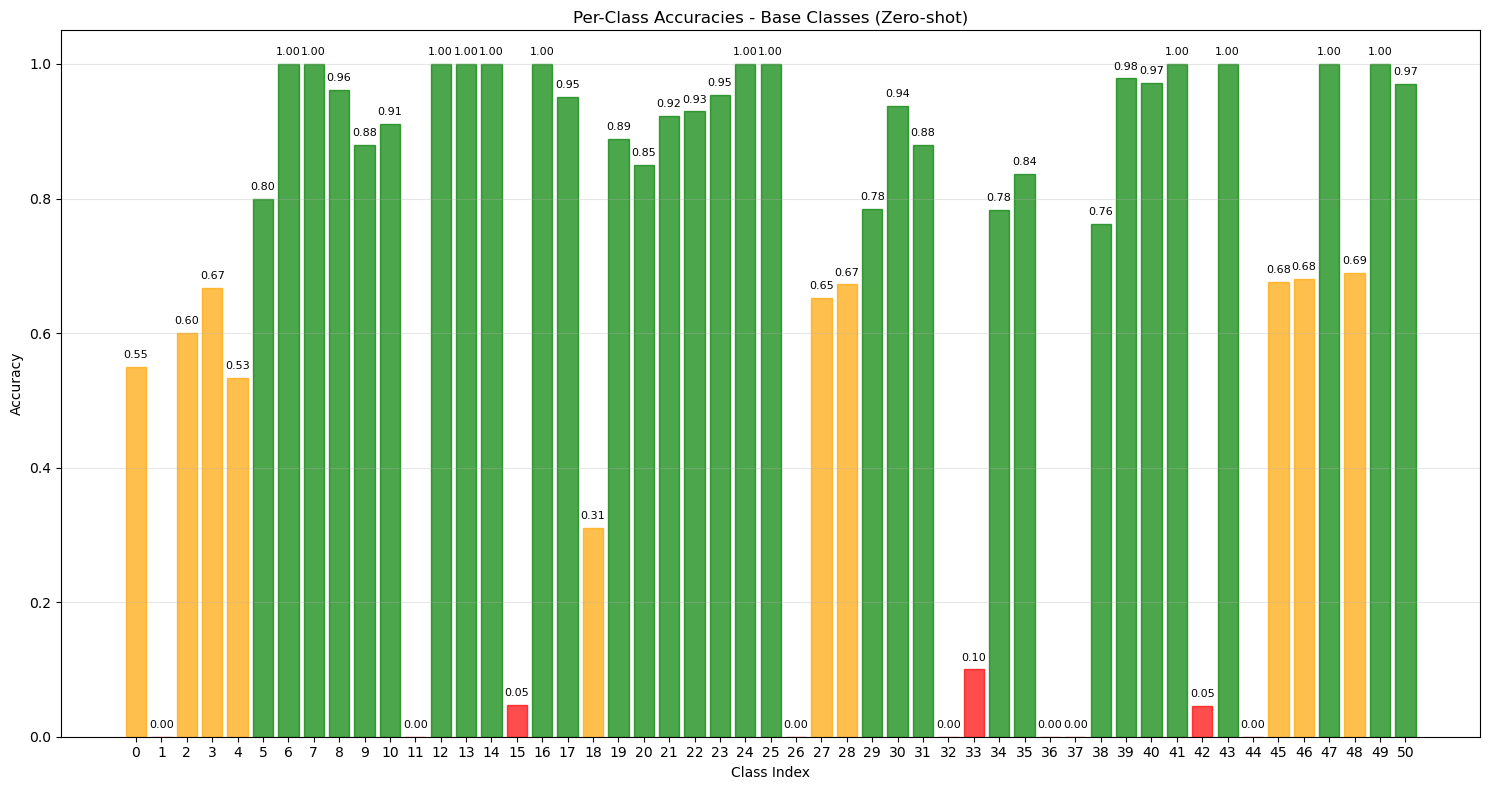


📊 Per-class accuracy statistics:
   Mean: 0.690
   Std:  0.363
   Min:  0.000
   Max:  1.000

🔍 All classes sorted by accuracy (lowest to highest):


,name,accuracy
1,hard-leaved pocket orchid,0.00
11,colt's foot,0.00
26,prince of wales feathers,0.00
32,love in the mist,0.00
36,cape flower,0.00
37,great masterwort,0.00
44,bolero deep blue,0.00
42,sword lily,0.05
15,globe-flower,0.05
33,mexican aster,0.10


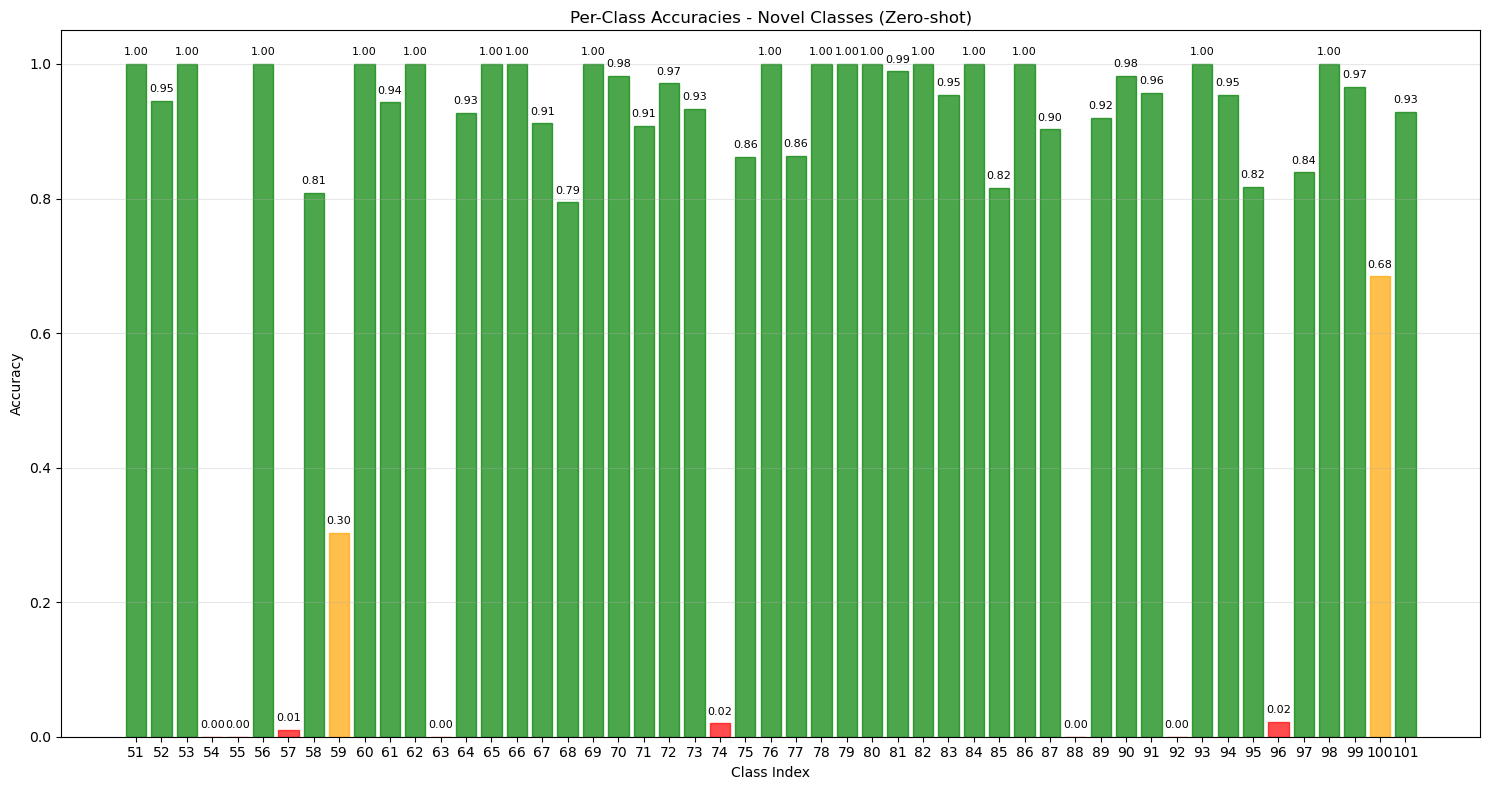


📊 Per-class accuracy statistics:
   Mean: 0.783
   Std:  0.353
   Min:  0.000
   Max:  1.000

🔍 All classes sorted by accuracy (lowest to highest):


,name,accuracy
54,pelargonium,0.00
55,bishop of llandaff,0.00
63,silverbush,0.00
88,watercress,0.00
92,ball moss,0.00
57,geranium,0.01
74,thorn apple,0.02
96,mallow,0.02
59,pink-yellow dahlia,0.30
100,trumpet creeper,0.68


In [6]:
def plot_per_class_accuracies(per_class_accuracies, class_names, categories, title="Per-Class Accuracies", show_table=True):
    """
    Plot per-class accuracies as a bar chart.
    
    Args:
        per_class_accuracies (list): List of accuracy values for each class
        class_names (list): List of all class names in the dataset
        categories (list): List of class indices being evaluated
        title (str): Title for the plot
    """
    # Get class names for the evaluated categories
    evaluated_class_names = [class_names[i] for i in categories]
    
    # Create figure and axis
    plt.figure(figsize=(15, 8))
    
    # Create bar chart
    bars = plt.bar(range(len(per_class_accuracies)), per_class_accuracies, alpha=0.7)
    
    # Customize the plot
    plt.xlabel('Class Index')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.xticks(range(len(per_class_accuracies)), [str(categories[i]) for i in range(len(per_class_accuracies))])
    plt.grid(axis='y', alpha=0.3)
    
    # Color bars based on accuracy (red for low, green for high)
    for i, (bar, acc) in enumerate(zip(bars, per_class_accuracies)):
        if acc < 0.25:
            bar.set_color('red')
        elif acc < 0.75:
            bar.set_color('orange')
        else:
            bar.set_color('green')
    
    # Add accuracy values on top of bars
    for i, acc in enumerate(per_class_accuracies):
        plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    mean_acc = np.mean(per_class_accuracies)
    std_acc = np.std(per_class_accuracies)
    min_acc = np.min(per_class_accuracies)
    max_acc = np.max(per_class_accuracies)
    
    print(f"\n📊 Per-class accuracy statistics:")
    print(f"   Mean: {mean_acc:.3f}")
    print(f"   Std:  {std_acc:.3f}")
    print(f"   Min:  {min_acc:.3f}")
    print(f"   Max:  {max_acc:.3f}")

    if show_table:
        # Sort all classes by accuracy (lowest to highest)
        class_acc_pairs = [(idx, acc) for idx, acc in enumerate(per_class_accuracies)]
        sorted_classes = sorted(class_acc_pairs, key=lambda x: x[1])
        all_classes_metrics = {}
        print(f"\n🔍 All classes sorted by accuracy (lowest to highest):")
        for idx, acc in sorted_classes:
            class_idx = categories[idx]
            all_classes_metrics[class_idx] = {
                'name': evaluated_class_names[idx],
                'accuracy': round(acc, 2)
            }
        all_classes_metrics_df = pd.DataFrame.from_dict(all_classes_metrics, orient='index')
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            display(all_classes_metrics_df)

# Plot the per-class accuracies for base and novel classes
plot_per_class_accuracies(base_per_class_acc, CLASS_NAMES, base_classes, 
                         "Per-Class Accuracies - Base Classes (Zero-shot)")

plot_per_class_accuracies(novel_per_class_acc, CLASS_NAMES, novel_classes, 
                         "Per-Class Accuracies - Novel Classes (Zero-shot)")

As we can see, instead of a homogeneous performance across all flower species, certain classes exhibit significantly lower accuracies, dragging down the overall performance. This observation motivated us to investigate the root causes of these discrepancies, leading to our exploration of **label alignment strategies**.

## Investigating Class Name Alignment

Our next step was to systematically explore how modifying labels for poorly performing classes could impact accuracy. Our main intuition was that CLIP’s training data likely contains more common or colloquial names for certain flower species, while the Oxford Flowers dataset uses more technical or less frequent terms. By aligning class names to better match CLIP’s learned vocabulary, we hypothesized that zero-shot performance could be improved.

After many trial and error experiments, we identified 3 specific strategies for label alignment that yielded significant accuracy improvements:

1. **Synonym Replacement**: replacing the original class name with a more common synonym or alternative name.
2. **Formatting Tweaks**: small change such as adding or removing dashes or slightly adjusting the wording to better match common usage.
3. **Corrections**: in a few cases, we found that the original class name was in fact not matching the flower species depicted in the images, so we corrected it to the appropriate name.

Let's now see a few examples for each strategy.

### 1. Synonym Replacement

Let's consider for instance base class 33, originally named *"mexican aster"*, with a zero-shot accuracy of 10%.

With a quick google search, we can find that this flower is also commonly referred to as *"garden cosmos"*.

By replacing the original label with this synonym, we observed a significant increase in accuracy.

🧠 Zero-shot evaluation on Base Classes: 100%|██████████| 20/20 [00:10<00:00,  1.83it/s]



🔍 Base classes accuracy: 72.10%


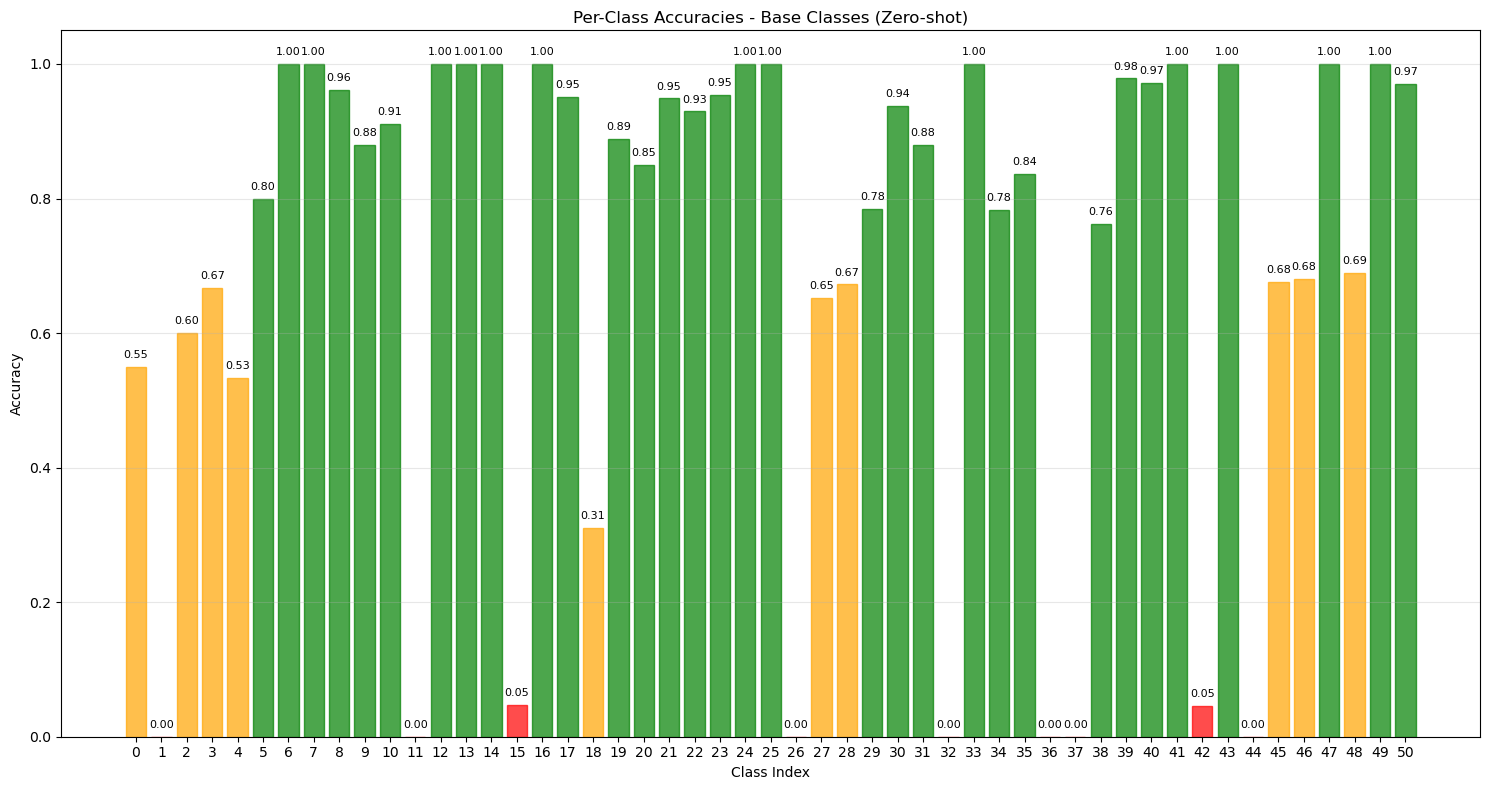


📊 Per-class accuracy statistics:
   Mean: 0.708
   Std:  0.356
   Min:  0.000
   Max:  1.000

🔍 All classes sorted by accuracy (lowest to highest):


,name,accuracy
1,hard-leaved pocket orchid,0.00
11,colt's foot,0.00
26,prince of wales feathers,0.00
32,love in the mist,0.00
36,cape flower,0.00
37,great masterwort,0.00
44,bolero deep blue,0.00
42,sword lily,0.05
15,globe-flower,0.05
18,balloon flower,0.31


In [7]:
# replace the class name with its synonym
CLASS_NAMES[33] = "garden cosmos"

# re-evaluate CLIP after the change
base_accuracy, base_per_class_acc = eval(model=clip_model, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes" )


# print and plot the results
print()
print(f"🔍 Base classes accuracy: {base_accuracy*100:.2f}%")
plot_per_class_accuracies(base_per_class_acc, CLASS_NAMES, base_classes, "Per-Class Accuracies - Base Classes (Zero-shot)")

# revert the class name change
CLASS_NAMES[33] = "mexican aster"

As we can see, class 33's accuracy improved from 10% to 100% simply by changing the label to a more common synonym. This confirms our hypothesis that better alignment of class names with CLIP's training vocabulary can lead to substantial performance gains.

### 2. Formatting Tweaks

Another effective strategy we found was to make small formatting adjustments to class names.

Let's consider base class 32, originally named *"love in the mist"*, with a zero-shot accuracy of 0%.

Again, with a quick search we can find that this flower is commonly referred to as *"love-in-a-mist"* (with dashes).

By applying this formatting tweak, we observed a remarkable improvement in accuracy.

🧠 Zero-shot evaluation on Base Classes: 100%|██████████| 20/20 [00:11<00:00,  1.81it/s]



🔍 Base classes accuracy: 72.38%


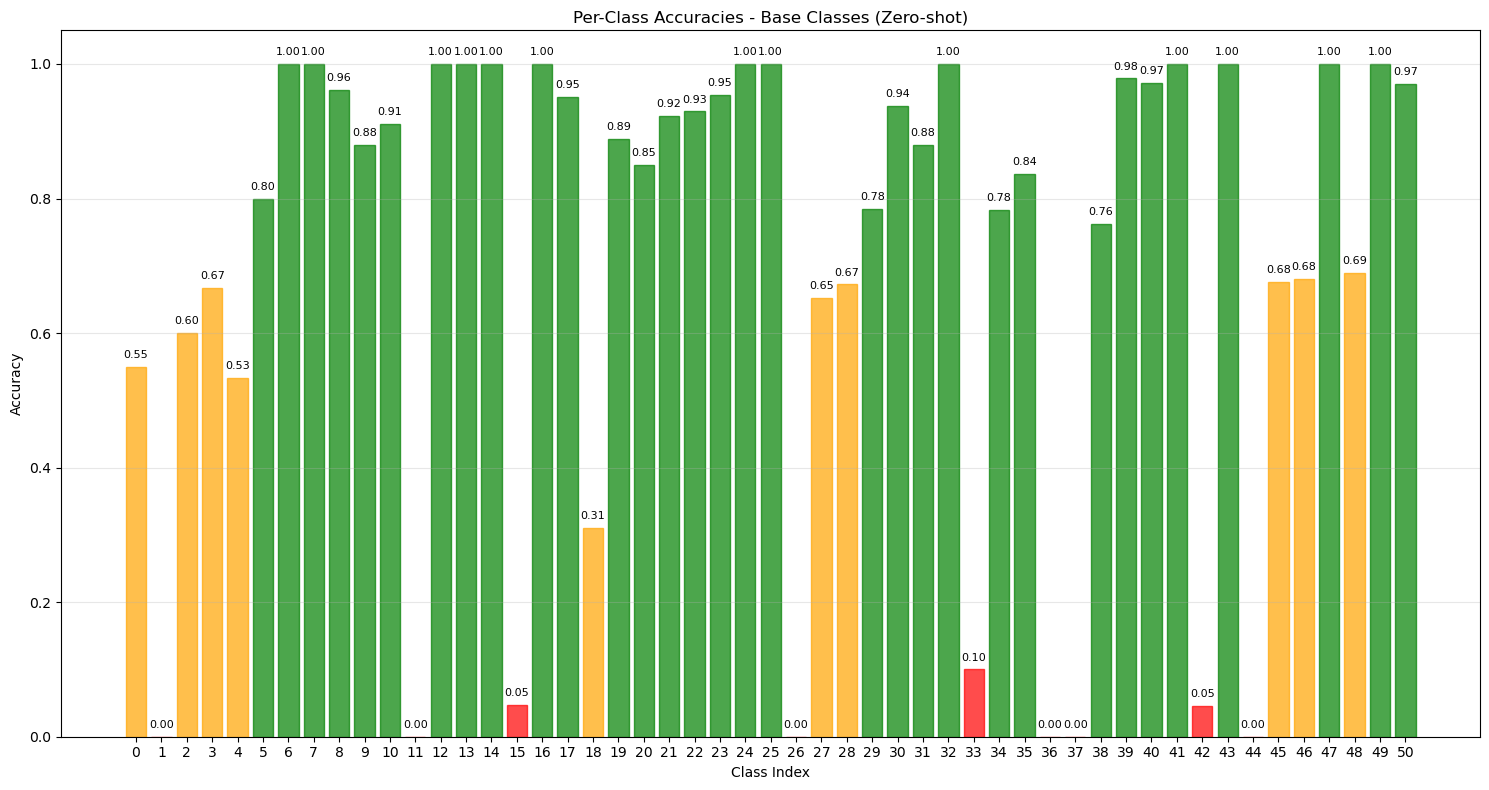


📊 Per-class accuracy statistics:
   Mean: 0.709
   Std:  0.352
   Min:  0.000
   Max:  1.000

🔍 All classes sorted by accuracy (lowest to highest):


,name,accuracy
1,hard-leaved pocket orchid,0.00
11,colt's foot,0.00
26,prince of wales feathers,0.00
36,cape flower,0.00
37,great masterwort,0.00
44,bolero deep blue,0.00
42,sword lily,0.05
15,globe-flower,0.05
33,mexican aster,0.10
18,balloon flower,0.31


In [8]:
# replace the class name with its new name
CLASS_NAMES[32] = "love-in-a-mist"

# re-evaluate CLIP after the change
base_accuracy, base_per_class_acc = eval(model=clip_model, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes" )


# print and plot the results
print()
print(f"🔍 Base classes accuracy: {base_accuracy*100:.2f}%")
plot_per_class_accuracies(base_per_class_acc, CLASS_NAMES, base_classes, "Per-Class Accuracies - Base Classes (Zero-shot)")

# revert the class name change
CLASS_NAMES[32] = "love in the mist"

We can see how a very simple formatting change led to a dramatic increase in accuracy from 0% to 100%. This further illustrates the sensitivity of CLIP's zero-shot performance to the exact wording and formatting of class names.

### 3. Corrections

To our surprise, by searching some classes' samples via Google Lens, we realized that for some classes the original label and the sample images led to different flower species. By correcting these mislabelings, we were able to significantly boost accuracy for these classes.

The most striking example is novel class 88, originally named *"watercress"*, with a zero-shot accuracy of 0%.

At first we tried to find synonyms or formatting tweaks, but accuracy remained at 0%.

Then, by inspecting the images, we realized that research by image associated them with another flower species: *"nasturtium"*. By changing the label to this name, we observed a dramatic increase in accuracy, suggesting that the original label was not aligned with the learned knowledge of the network, which tends to reflect the most popular associations made online.

🧠 Zero-shot evaluation on Novel Classes: 100%|██████████| 29/29 [00:15<00:00,  1.83it/s]



🔍 Novel classes accuracy: 82.18%


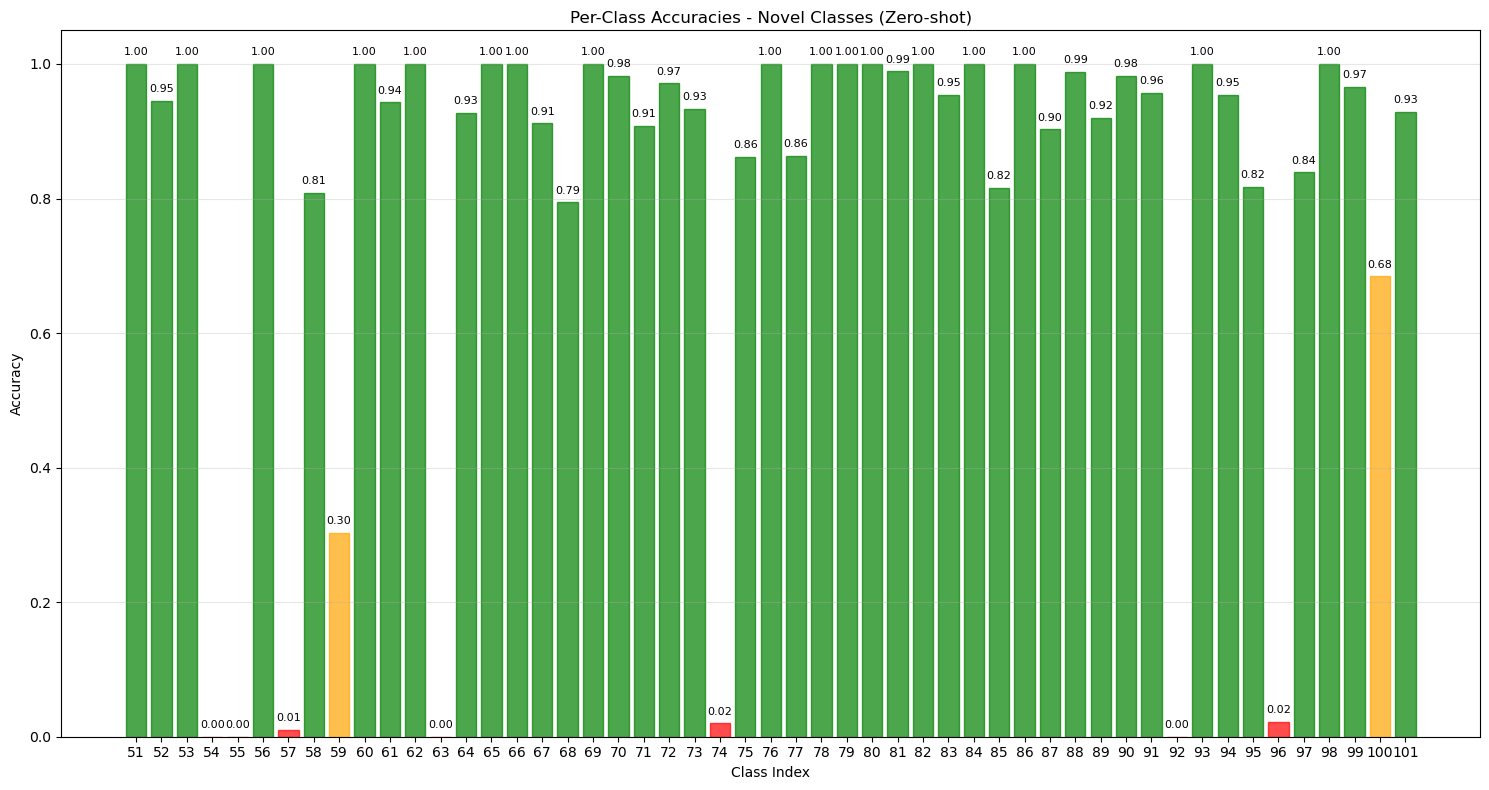


📊 Per-class accuracy statistics:
   Mean: 0.802
   Std:  0.336
   Min:  0.000
   Max:  1.000

🔍 All classes sorted by accuracy (lowest to highest):


,name,accuracy
54,pelargonium,0.00
55,bishop of llandaff,0.00
63,silverbush,0.00
92,ball moss,0.00
57,geranium,0.01
74,thorn apple,0.02
96,mallow,0.02
59,pink-yellow dahlia,0.30
100,trumpet creeper,0.68
68,windflower,0.79


In [9]:
# replace the class name with its new name
CLASS_NAMES[88] = "nasturtium"

# re-evaluate CLIP after the change
novel_accuracy, novel_per_class_acc = eval(model=clip_model, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes" )


# print and plot the results
print()
print(f"🔍 Novel classes accuracy: {novel_accuracy*100:.2f}%")
plot_per_class_accuracies(novel_per_class_acc, CLASS_NAMES, novel_classes, "Per-Class Accuracies - Novel Classes (Zero-shot)")

# revert the class name change
CLASS_NAMES[88] = "watercress"

As we can see, the accuracy for class 88 jumped from 0% to almost 100% after correcting the label. This highlights the importance of accurate labeling and how mislabelings can severely impact model performance. Moreover, since this class is a novel one, there would be no way to improve its accuracy in a base-to-novel generalization setting without correcting the label.

## AKA CLIP

Given the surprising effectiveness of simple label changes, we decided to modify CLIP zero shot to enable the model to use multiple names/aliases for each class, while still selecting the most similar one for each sample, and trace it back to the original class. By allowing to use multiple names alltogether, we can observe and select the best performing aliases, or alternatively, by automating the collection/generation of synonims, automate the classification task, by removing human intervention.

In [10]:
AKA_CLASS_NAMES = [['pink primrose', 'pink evening primrose'], ['hard-leaved pocket orchid', 'silver slipper orchid'],
               ['canterbury bells', 'campanula medium'], ['sweet pea', 'lathyrus odoratus'], ['english marigold', 'calendula'],
               ['tiger lily'], ['moon orchid'], ['bird of paradise'], ['monkshood'], ['globe thistle'], ['snapdragon'],
               ["colt's foot", 'coltsfoot'], ['king protea'], ['spear thistle'], ['yellow iris'], ['globe-flower', 'trollius'],
               ['purple coneflower'], ['peruvian lily'], ['balloon flower', 'chinese bellflower'], ['giant white arum lily'],
               ['fire lily'], ['pincushion flower'], ['fritillary'], ['red ginger'], ['grape hyacinth'], ['corn poppy'],
               ['prince of wales feathers', 'amaranthus hypochondriacus'], ['stemless gentian'], ['artichoke', 'globe artichoke'],
               ['sweet william'], ['carnation'], ['garden phlox'], ['love in the mist', 'love-in-a-mist'],
               ['mexican aster', 'garden cosmos'], ['alpine sea holly'], ['ruby-lipped cattleya'],
               ['cape flower', 'japanese spider lily'], ['great masterwort', 'astrantia major'],
               ['siam tulip', 'curcuma alismatifolia'], ['lenten rose'], ['barbeton daisy', 'gerbera jamesonii'], ['daffodil'],
               ['sword lily', 'marsh gladiolus'], ['poinsettia'], ['bolero deep blue', 'eustoma exaltatum'],
               ['wallflower', 'erysimum'], ['marigold'], ['buttercup'], ['oxeye daisy'], ['common dandelion'], ['petunia'],
               ['wild pansy'], ['primula'], ['sunflower'], ['lilac hibiscus'], ['bishop of llandaff', 'dahlia bishop of llandaff'],
               ['gaura'], ['geranium'], ['orange dahlia'], ['pink-yellow dahlia', 'pink and yellow dahlia'], ['cautleya spicata'],
               ['japanese anemone'], ['black-eyed susan'], ['silverbush', 'shrubby bindweed'], ['californian poppy'],
               ['osteospermum'], ['spring crocus'], ['bearded iris'], ['windflower', 'wood anemone'], ['tree poppy'], ['gazania'],
               ['azalea'], ['water lily'], ['rose'], ['thorn apple', 'jimsonweed'], ['morning glory', 'morning-glory'],
               ['passion flower'], ['lotus'], ['toad lily'], ['anthurium'], ['frangipani'], ['clematis'], ['hibiscus'],
               ['columbine'], ['desert-rose'], ['tree mallow'], ['magnolia'], ['cyclamen'], ['watercress', 'nasturtium'],
               ['canna lily'], ['hippeastrum'], ['bee balm'], ['ball moss', 'tillandsia cyanea'], ['foxglove'], ['bougainvillea'],
               ['camellia'], ['mallow', 'abutilon'], ['mexican petunia', 'ruellia'], ['bromelia'], ['blanket flower'],
               ['trumpet creeper', 'campsis radicans'], ['blackberry lily']]

In [11]:
@torch.no_grad() # we don't want gradients
def aka_eval(model: nn.Module,
         dataset: torch.utils.data.Dataset,
         categories: list[int],
         batch_size: int,
         device: str,
         class_names=AKA_CLASS_NAMES,
         label=""):
    model.eval()

    # Remap labels into a contiguous set starting from zero
    true_label_to_index = {cat: idx for idx, cat in enumerate(categories)}
    log = pd.DataFrame(columns=["true_label", "predicted_label", "correct"])
    prompts = [] # List of all possible text prompts (one for each class alias)
    map_alias_index_to_index_label = [] # Maps each prompt index to the corresponding label index
    map_alias_index_to_alias_label = [] # Maps each prompt index to the corresponding alias
    for c in categories: # fills up previous 3 lists
        for alias in class_names[c]:
            prompts.append(f"a photo of a {alias}, a type of flower.")
            map_alias_index_to_index_label.append(true_label_to_index[c])
            map_alias_index_to_alias_label.append(alias)
    text_inputs = clip.tokenize(prompts).to(device)
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    correct_predictions = 0
    for image, target in tqdm(dataloader, desc=label):
        true_labels = [t.item() for t in target]
        target = torch.Tensor([true_label_to_index[t.item()] for t in target]).long() # convets original label indexes to current labels used for predictions

        image = image.to(device)
        target = target.to(device)

        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        predicted_class = (image_features @ text_features.T).argmax(dim=-1)
        predicted_labels = [map_alias_index_to_alias_label[p.item()] for p in predicted_class] # converts predicted index into textual predicted label for logging purposes
        predicted_class = torch.Tensor([map_alias_index_to_index_label[p.item()] for p in predicted_class]).long().to(device) # converts predicted label to classes predictions
        prediction_correctness = (predicted_class == target).tolist() # count correct predictions
        # logging
        batch_data = []
        for i, correct in enumerate(prediction_correctness):
            batch_data.append({"true_label": true_labels[i],
                              "predicted_label": predicted_labels[i],
                              "correct": correct})
        
        batch_df = pd.DataFrame(batch_data)
        log = pd.concat([log, batch_df], ignore_index=True)
        correct_predictions += sum(prediction_correctness)
    accuracy = correct_predictions / len(dataset)
    return accuracy, log

base_accuracy, base_log = aka_eval(model=clip_model, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracy, novel_log = aka_eval(model=clip_model, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
print()
print(f"🔍 Base classes accuracy: {base_accuracy*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracy*100:.2f}%")
hm = harmonic_mean(base_accuracy, novel_accuracy)
aka_clip_accuracy_values = (base_accuracy, novel_accuracy, hm)
print(f"🔍 Harmonic Mean: {hm*100:.2f}%")

🧠 Zero-shot evaluation on Novel Classes: 100%|██████████| 29/29 [00:16<00:00,  1.80it/s]


🔍 Base classes accuracy: 85.69%
🔍 Novel classes accuracy: 91.62%
🔍 Harmonic Mean: 88.55%


In [12]:
# Display the results 
aka_clip_results = pd.DataFrame({
    'Method': ['AKA CLIP'],
    'Base Accuracy': [aka_clip_accuracy_values[0]*100],
    'Novel Accuracy': [aka_clip_accuracy_values[1]*100],
    'Harmonic Mean': [aka_clip_accuracy_values[2]*100]
})

print("\n📊 Detailed Results:")
print("=" * 90)

# Create a styled version
def highlight_best(s):
    is_max = s == s.max()
    return ['font-weight: bold' if v else '' for v in is_max]

styled_results = aka_clip_results.style.format({
    'Base Accuracy': '{:.2f}%',
    'Novel Accuracy': '{:.2f}%', 
    'Harmonic Mean': '{:.2f}%'
}).apply(highlight_best, subset=['Base Accuracy', 'Novel Accuracy', 'Harmonic Mean']).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
    {'selector': '', 'props': [('border-collapse', 'collapse'), ('font-family', 'Arial, sans-serif')]}
]).set_caption("AKA CLIP Zero-Shot Performance").set_table_attributes('style="margin: auto; border: 2px solid #2E86AB;"')

display(styled_results)


📊 Detailed Results:


,Method,Base Accuracy,Novel Accuracy,Harmonic Mean
0,AKA CLIP,85.69%,91.62%,88.55%


In [13]:
def compute_alias_metrics(base_log, novel_log, class_names=AKA_CLASS_NAMES):
    map_alias_to_label_index = {}
    for index in range(len(class_names)):
        for alias in class_names[index]:
            map_alias_to_label_index[alias] = index
    base_classes_sample_counts = base_log['true_label'].value_counts().sort_index()
    novel_classes_sample_counts = novel_log['true_label'].value_counts().sort_index()

    # Concatenate base and novel counts
    all_classes_sample_counts = pd.concat([base_classes_sample_counts, novel_classes_sample_counts]).sort_index()

    # Merge base and novel logs
    combined_log = pd.concat([base_log, novel_log], ignore_index=True)

    # Compute correct predictions for each alias
    alias_correct_predictions = combined_log[combined_log['correct'] == True]['predicted_label'].value_counts()

    # Create metrics dictionary for each alias
    alias_metrics = {}
    for alias in map_alias_to_label_index.keys():
        class_index = map_alias_to_label_index[alias]
        
        # Get correct predictions for this alias
        correct_preds = alias_correct_predictions.get(alias, 0)
        
        # Get total samples for this class
        total_samples = all_classes_sample_counts.get(class_index, 0)
        
        # Get total predictions for this alias (correct + incorrect)
        total_predictions = combined_log[combined_log['predicted_label'] == alias].shape[0]
        
        # Calculate precision (correct predictions / total predictions for this alias)
        precision = correct_preds / total_predictions if total_predictions > 0 else 0.0
        recall = correct_preds / total_samples if total_samples > 0 else 0.0
        
        alias_metrics[alias] = {
            'id': class_index,
            'correct_predictions': correct_preds,
            'total_class_samples': total_samples,
            'total_predictions': total_predictions,
            'precision': round(precision, 2),
            'recall': round(recall, 2)
        }
    alias_metrics_df = pd.DataFrame.from_dict(alias_metrics, orient='index')
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(alias_metrics_df)

compute_alias_metrics(base_log, novel_log, class_names=AKA_CLASS_NAMES)

,id,correct_predictions,total_class_samples,total_predictions,precision,recall
pink primrose,0,3,20,7,0.43,0.15
pink evening primrose,0,16,20,21,0.76,0.80
hard-leaved pocket orchid,1,0,40,3,0.00,0.00
silver slipper orchid,1,28,40,37,0.76,0.70
canterbury bells,2,0,20,11,0.00,0.00
campanula medium,2,10,20,21,0.48,0.50
sweet pea,3,5,36,5,1.00,0.14
lathyrus odoratus,3,25,36,31,0.81,0.69
english marigold,4,3,45,18,0.17,0.07
calendula,4,39,45,46,0.85,0.87


As we can see from the table, some aliases are performing way better compared to others; some are getting predicted almost only when their class should be(bird of paradise, love-in-a-mist), some are never getting predicted(love in the mist), while other are moslty responsible for wrong predictions(english marigold)

,class_name,all_aliases,correct_predictions,total_samples,recall
0,pink primrose,"[pink primrose, pink evening primrose]",19,20,0.95
1,hard-leaved pocket orchid,"[hard-leaved pocket orchid, silver slipper orc...",28,40,0.70
2,canterbury bells,"[canterbury bells, campanula medium]",10,20,0.50
3,sweet pea,"[sweet pea, lathyrus odoratus]",30,36,0.83
4,english marigold,"[english marigold, calendula]",42,45,0.93
5,tiger lily,[tiger lily],17,25,0.68
6,moon orchid,[moon orchid],16,20,0.80
7,bird of paradise,[bird of paradise],65,65,1.00
8,monkshood,[monkshood],25,26,0.96
9,globe thistle,[globe thistle],22,25,0.88


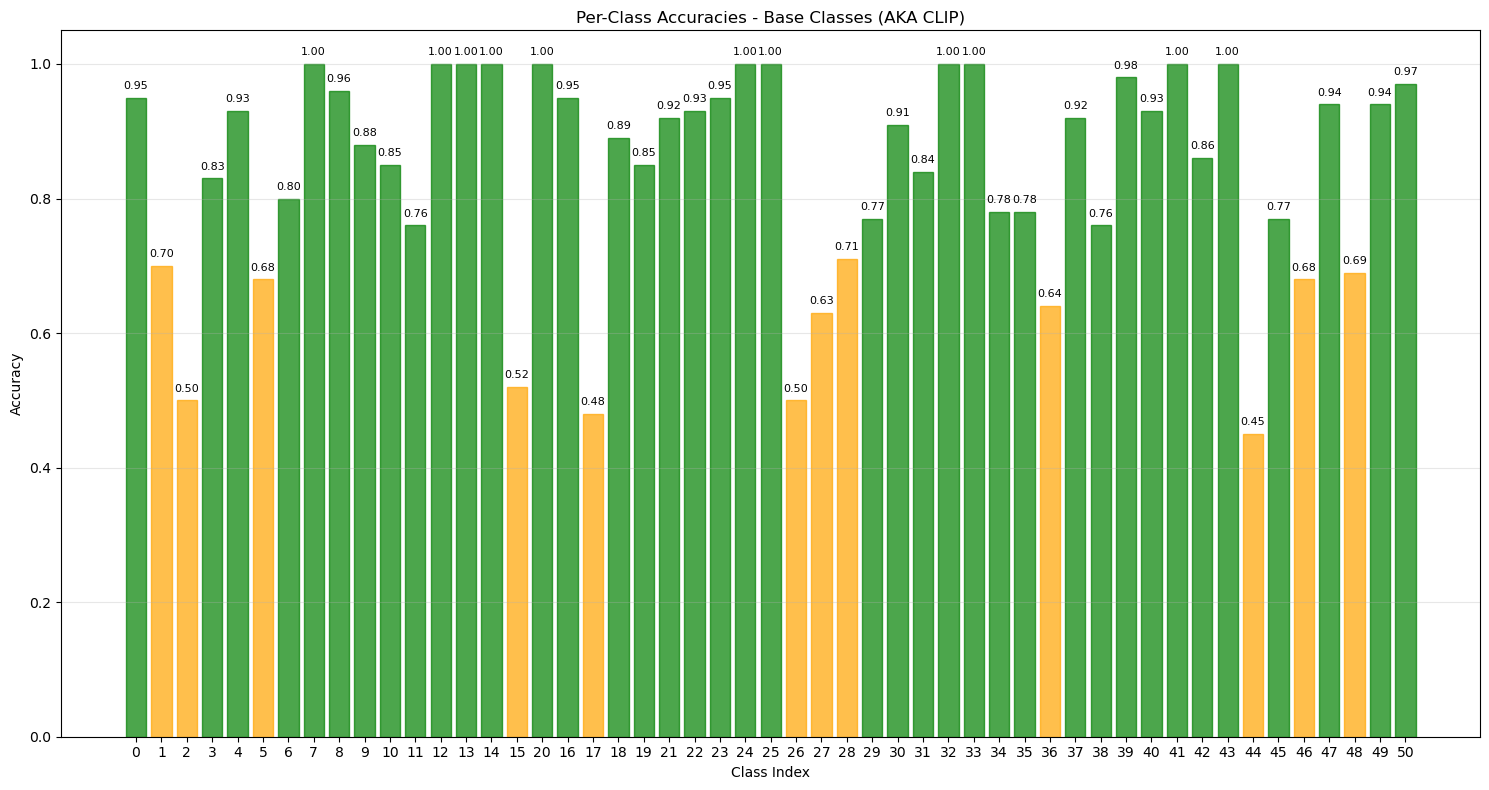


📊 Per-class accuracy statistics:
   Mean: 0.839
   Std:  0.158
   Min:  0.450
   Max:  1.000


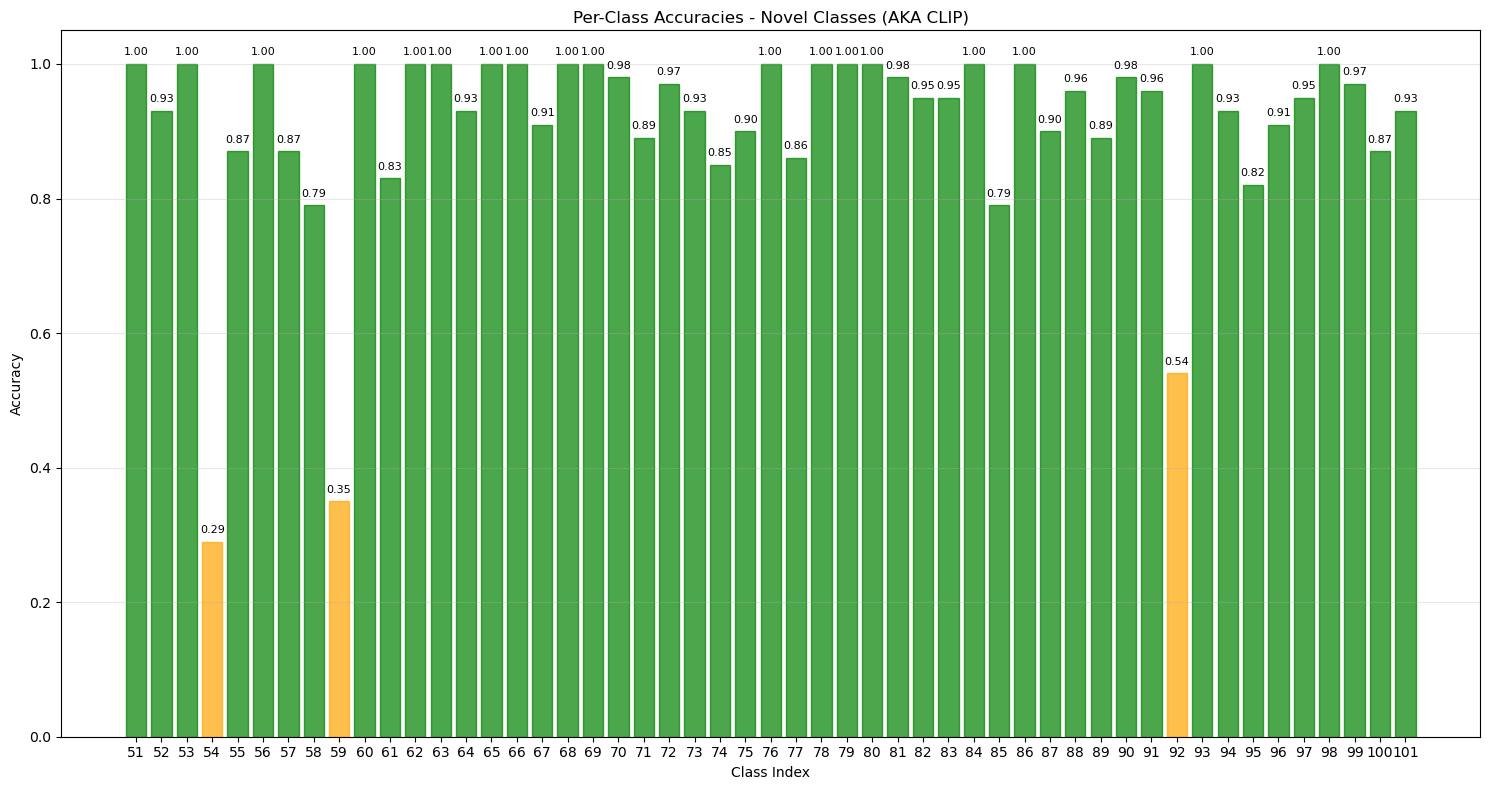


📊 Per-class accuracy statistics:
   Mean: 0.910
   Std:  0.145
   Min:  0.290
   Max:  1.000


In [14]:
def compute_class_accuracies(base_log, novel_log, class_names=AKA_CLASS_NAMES):
    # Count correct predictions for each class
    base_correct_predictions_counts = base_log[base_log['correct'] == True]['true_label'].value_counts().sort_index()
    novel_correct_predictions_counts = novel_log[novel_log['correct'] == True]['true_label'].value_counts().sort_index()
    base_classes_sample_counts = base_log['true_label'].value_counts().sort_index()
    novel_classes_sample_counts = novel_log['true_label'].value_counts().sort_index()
    all_classes_sample_counts = pd.concat([base_classes_sample_counts, novel_classes_sample_counts]).sort_index()

    # Concatenate base and novel correct predictions
    all_classes_correct_predictions_counts = pd.concat([base_correct_predictions_counts, novel_correct_predictions_counts]).sort_index()

    # Calculate accuracy for each class
    class_accuracies = {}
    for class_id in range(len(class_names)):
        correct_preds = all_classes_correct_predictions_counts.get(class_id, 0)
        total_samples = all_classes_sample_counts.get(class_id, 0)
        recall = correct_preds / total_samples if total_samples > 0 else 0.0
        
        class_accuracies[class_id] = {
            'class_name': class_names[class_id][0],  # Primary name for the class
            'all_aliases': class_names[class_id],    # All aliases for this class
            'correct_predictions': correct_preds,
            'total_samples': total_samples,
            'recall': round(recall, 2),
        }

    # Convert to DataFrame
    class_accuracies_df = pd.DataFrame.from_dict(class_accuracies, orient='index')
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(class_accuracies_df)
    
    base_classes = base_log['true_label'].unique()
    novel_classes = novel_log['true_label'].unique()
    
    # Extract accuracies for base classes
    base_per_class_acc = [class_accuracies[class_id]['recall'] for class_id in sorted(base_classes)]
    
    # Extract accuracies for novel classes  
    novel_per_class_acc = [class_accuracies[class_id]['recall'] for class_id in sorted(novel_classes)]

    # Plot the per-class accuracies
    plot_per_class_accuracies(base_per_class_acc, CLASS_NAMES, base_classes, 
                             "Per-Class Accuracies - Base Classes (AKA CLIP)", show_table=False)
    
    plot_per_class_accuracies(novel_per_class_acc, CLASS_NAMES, novel_classes, 
                             "Per-Class Accuracies - Novel Classes (AKA CLIP)", show_table=False)

compute_class_accuracies(base_log, novel_log, class_names=AKA_CLASS_NAMES)

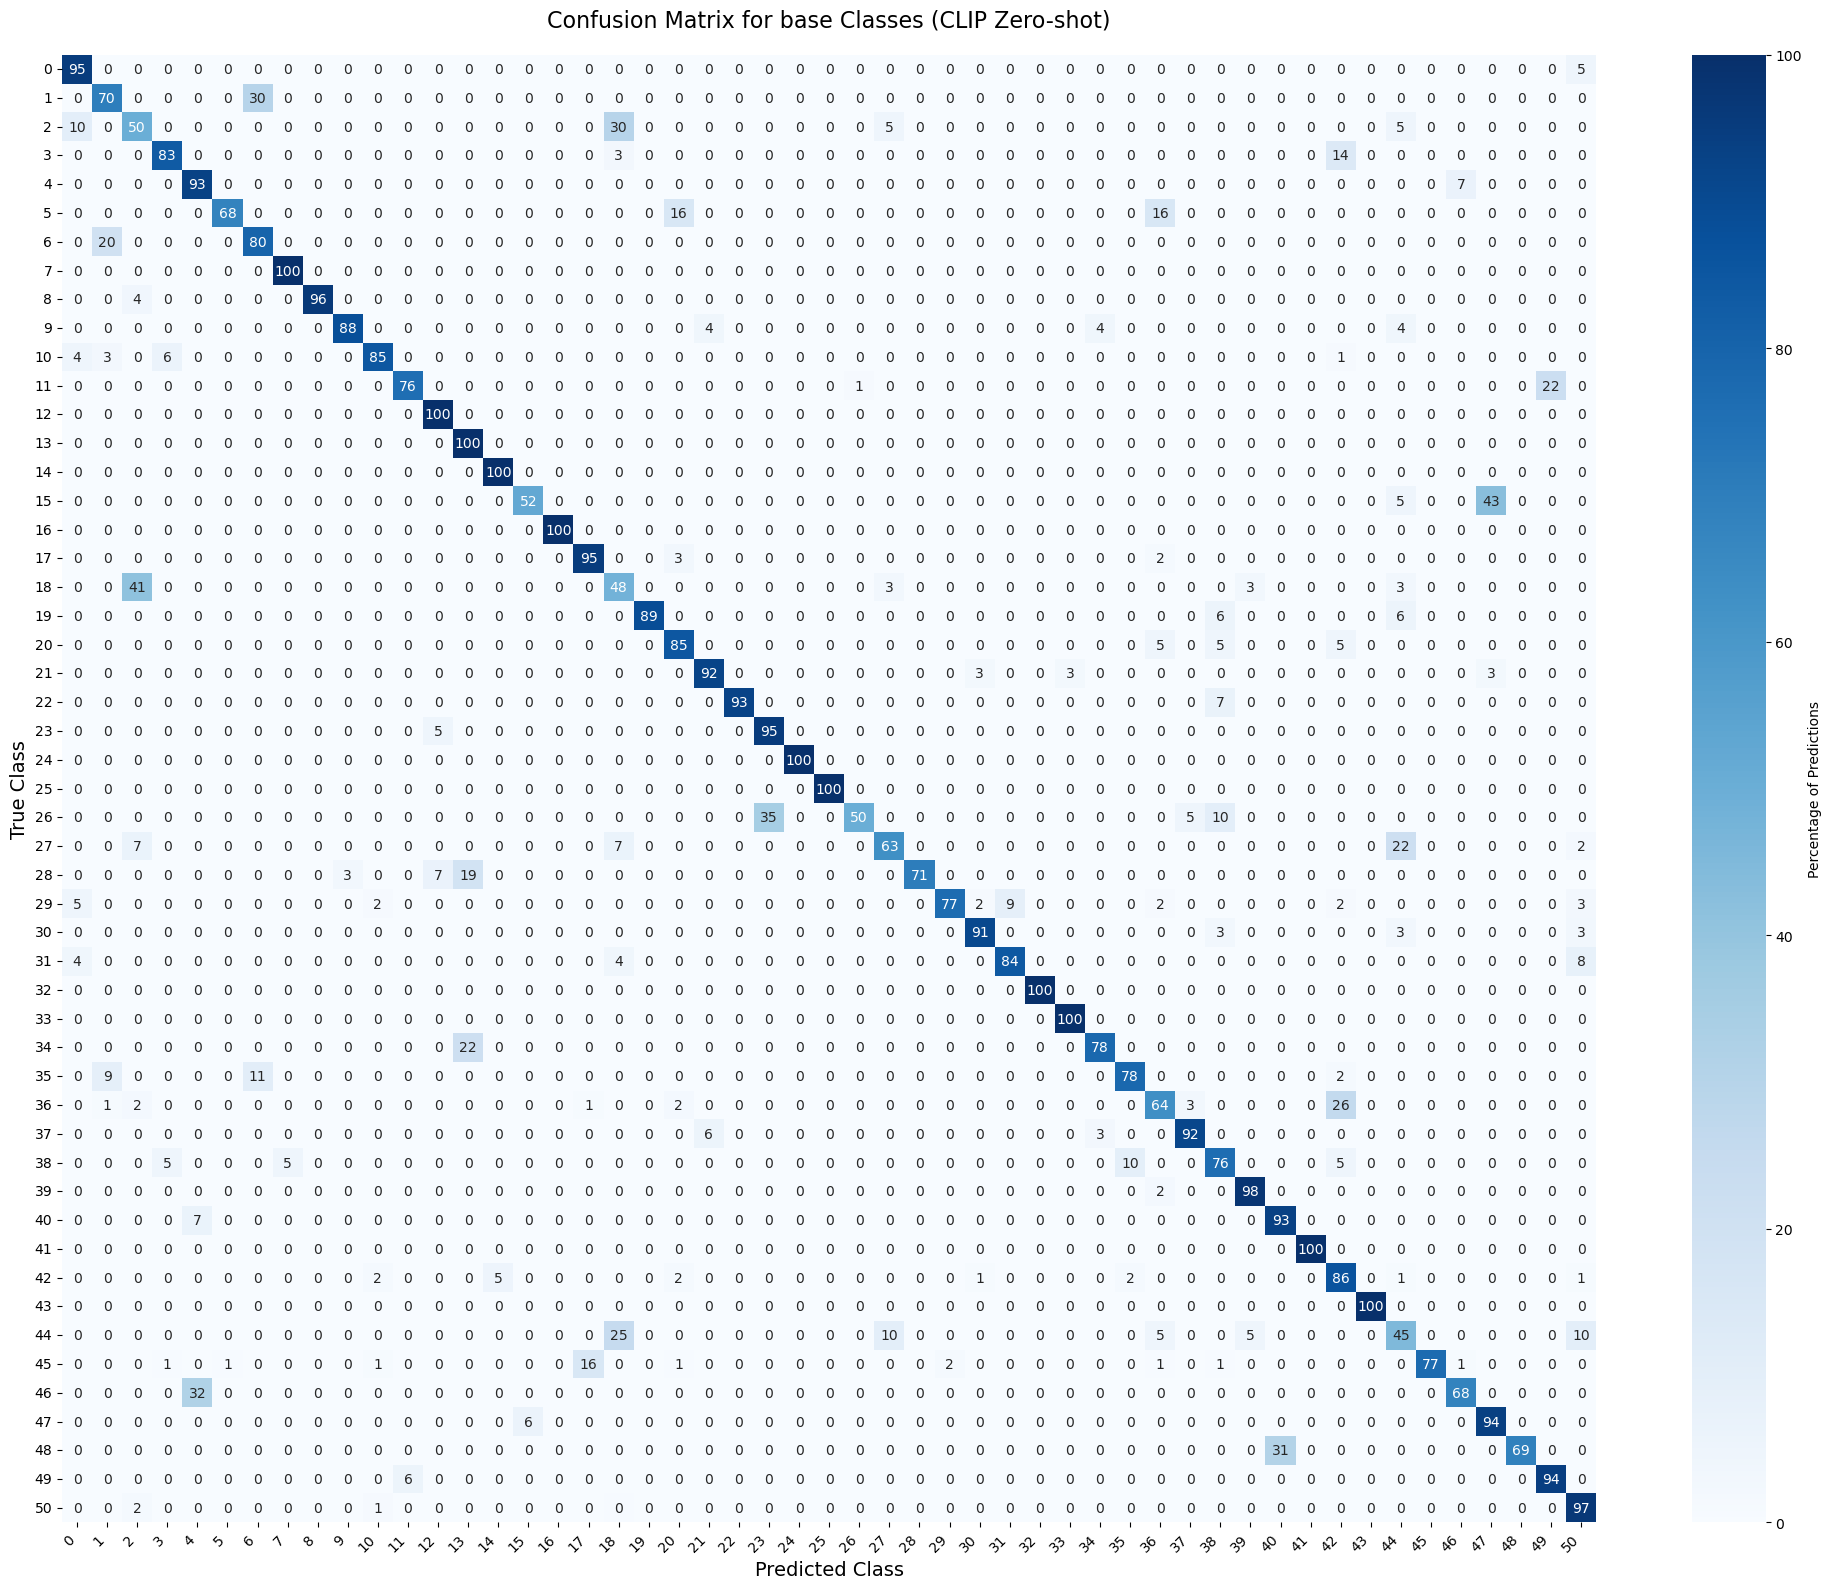

📊 Confusion Matrix Statistics:
Matrix shape: (51, 51)
Total predictions: 2473
Correct predictions (diagonal): 2119
Accuracy: 0.8569

🔀 Most confused pair:
True class: 15 (class 15)
Predicted as: 47 (class 47)
Confusion count: 42.857142857142854
Confusion percentage: 42.9%


In [15]:
def class_confusion_matrix(log, selected_classes, label="base", class_names=AKA_CLASS_NAMES):
    map_alias_to_label_index = {}
    for index in range(len(class_names)):
        for alias in class_names[index]:
            map_alias_to_label_index[alias] = index
    # Convert predicted aliases to class indices for log
    log_with_pred_indices = log.copy()
    log_with_pred_indices['predicted_label'] = log_with_pred_indices['predicted_label'].map(map_alias_to_label_index)
    log_with_pred_indices['true_label'] = log_with_pred_indices['true_label'].astype(int)
    log_with_pred_indices['predicted_label'] = log_with_pred_indices['predicted_label'].astype(int)

    # Get true and predicted class indices
    y_true = log_with_pred_indices['true_label'].values
    y_pred = log_with_pred_indices['predicted_label'].values

    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=selected_classes)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    cm_percent = np.nan_to_num(cm_percent)


    # Plot confusion matrix
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm_percent, 
                xticklabels=selected_classes, 
                yticklabels=selected_classes,
                annot=True, 
                fmt='.0f', 
                cmap='Blues',
                cbar_kws={'label': 'Percentage of Predictions'})

    plt.title(f'Confusion Matrix for {label} Classes (CLIP Zero-shot)', fontsize=16, pad=20)
    plt.xlabel('Predicted Class', fontsize=14)
    plt.ylabel('True Class', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Print some statistics about the confusion matrix
    print(f"📊 Confusion Matrix Statistics:")
    print(f"Matrix shape: {cm.shape}")
    print(f"Total predictions: {cm.sum()}")
    print(f"Correct predictions (diagonal): {np.trace(cm)}")
    print(f"Accuracy: {np.trace(cm) / cm.sum():.4f}")

    # Find most confused classes (highest off-diagonal values)
    cm_percent_off_diagonal = cm_percent.copy()
    np.fill_diagonal(cm_percent_off_diagonal, 0)
    max_confusion_idx = np.unravel_index(np.argmax(cm_percent_off_diagonal), cm_percent_off_diagonal.shape)
    max_confusion_count = cm_percent_off_diagonal[max_confusion_idx]
    max_confusion_percent = cm_percent_off_diagonal[max_confusion_idx]

    true_class_idx = selected_classes[max_confusion_idx[0]]
    pred_class_idx = selected_classes[max_confusion_idx[1]]

    print(f"\n🔀 Most confused pair:")
    print(f"True class: {true_class_idx} (class {true_class_idx})")
    print(f"Predicted as: {pred_class_idx} (class {pred_class_idx})")
    print(f"Confusion count: {max_confusion_count}")
    print(f"Confusion percentage: {max_confusion_percent:.1f}%")

class_confusion_matrix(base_log, base_classes, class_names=AKA_CLASS_NAMES)

As we can see from the results, the accuracy across classes is now more uniform. Accuracy percentage is computed across rows, and rounded to the nearest integer. As we can see from the matrix, some classes, more speicifically some aliases, are still getting predicted on the wrong classes, as noted in the alias table.

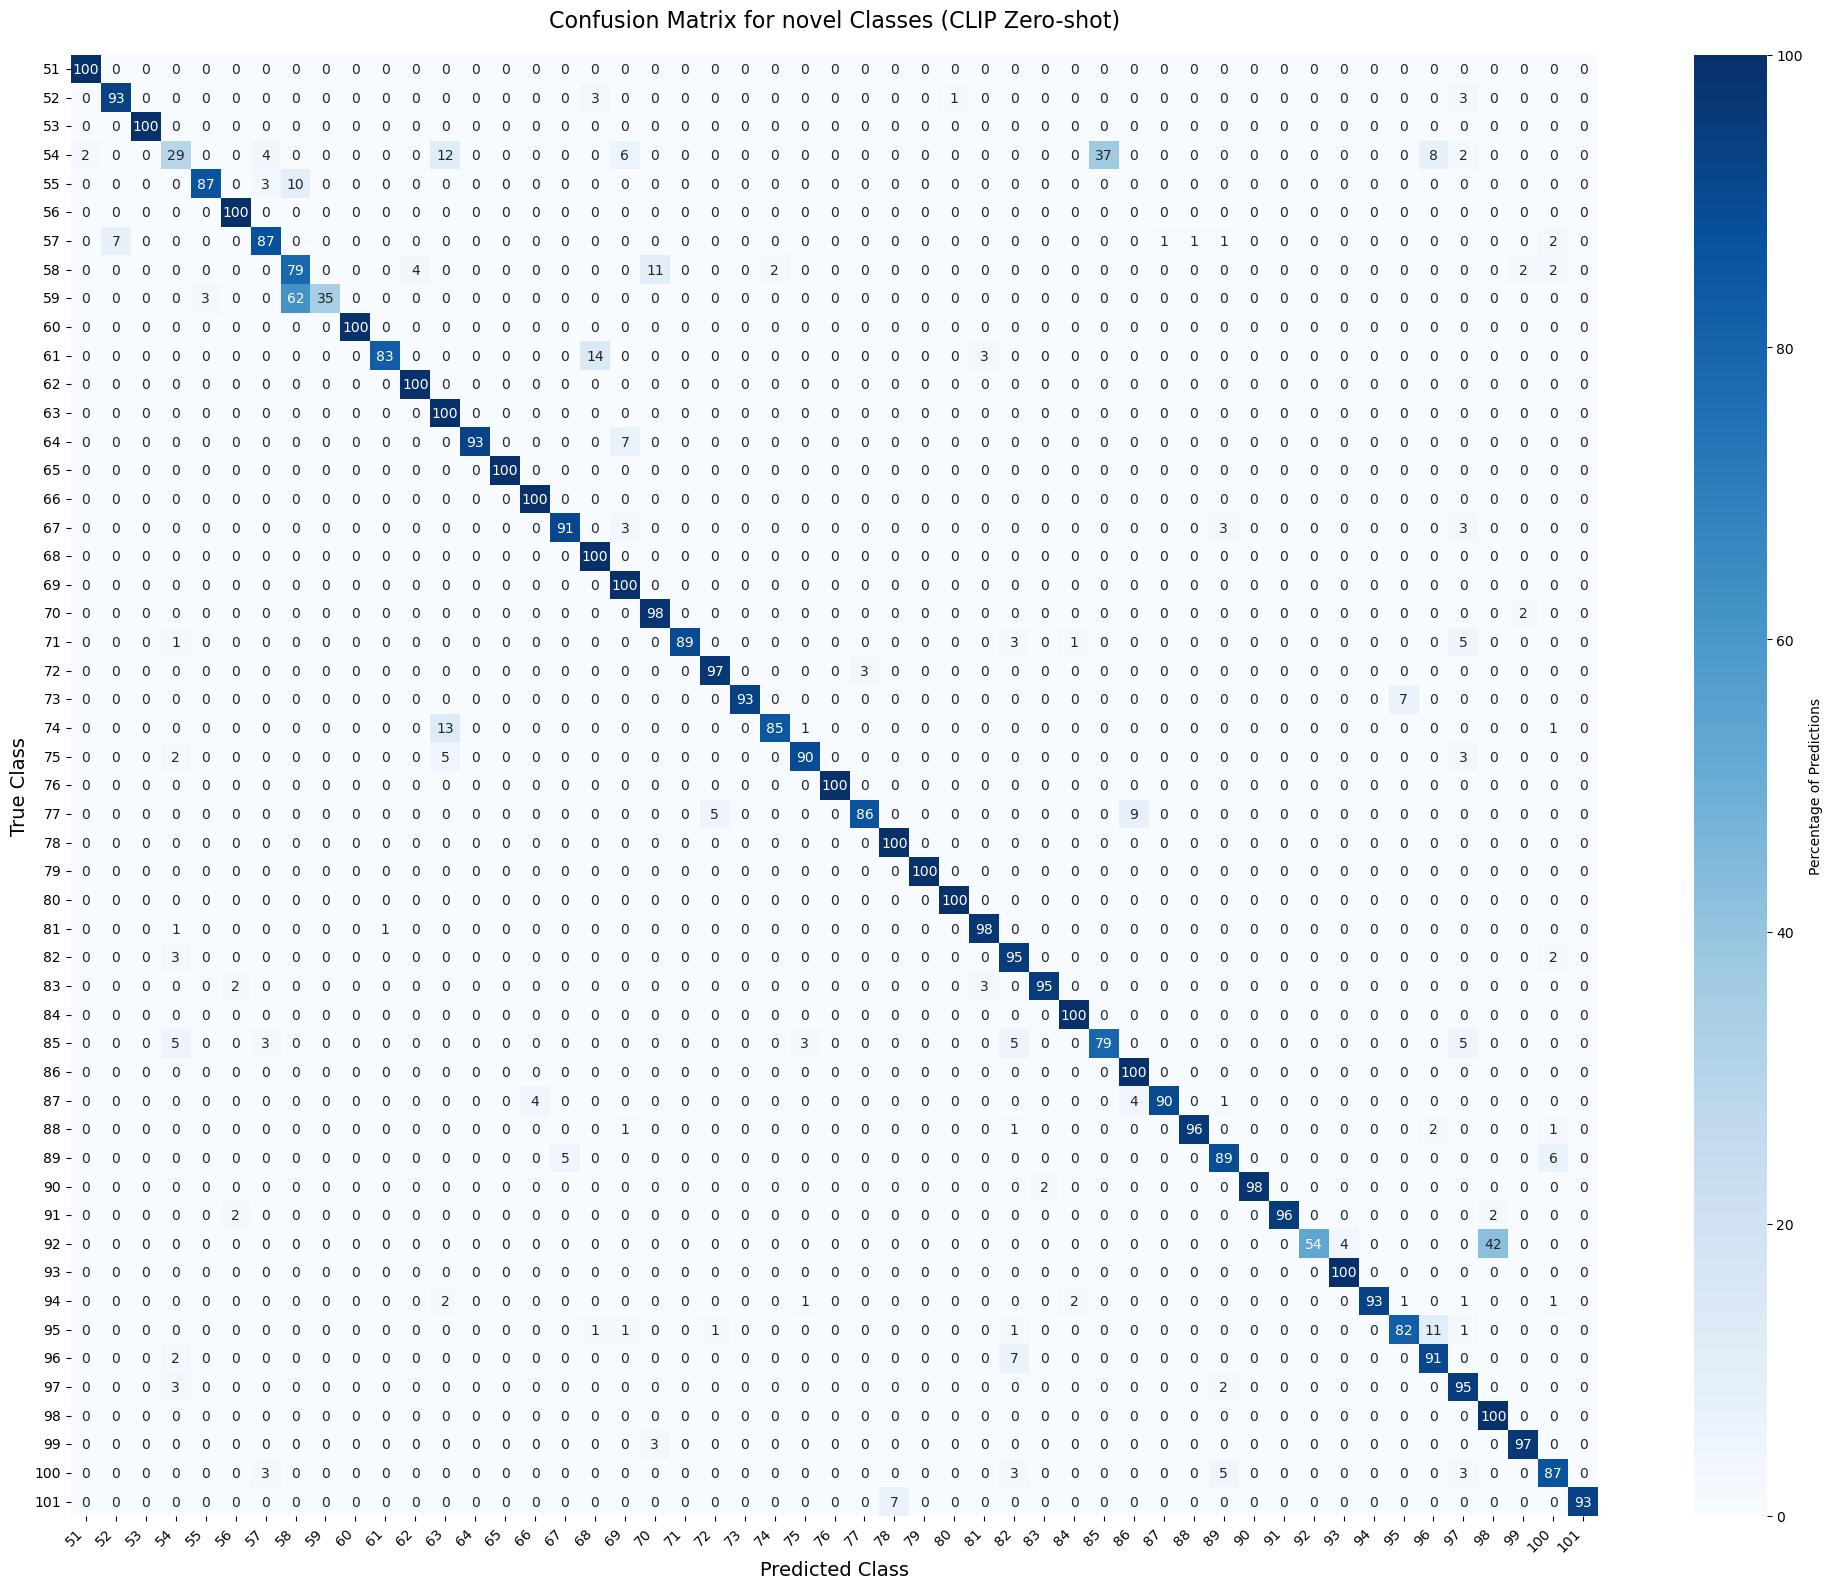

📊 Confusion Matrix Statistics:
Matrix shape: (51, 51)
Total predictions: 3676
Correct predictions (diagonal): 3368
Accuracy: 0.9162

🔀 Most confused pair:
True class: 59 (class 59)
Predicted as: 58 (class 58)
Confusion count: 61.79775280898876
Confusion percentage: 61.8%


In [16]:
class_confusion_matrix(novel_log, novel_classes, label="novel", class_names=AKA_CLASS_NAMES)

As we can see from the results, there's a significant improvement in performance compared to the zero-shot model with original names; some classes are still underperforming, due to the presence of some classnames that disrupt the correct classification, mostly due to being associated with the wrong classes, and belonging to the third case of label change.

## Zero-Shot CLIP with Best Performing Aliases

After trying out multiple aliases for each class, we selected the best performing one for each class, and evaluated the zero-shot performance of CLIP using these optimized labels.

Here's the detailed table showing all the changes that we made to the original class names, along with the corresponding change strategy (1: synonym replacement, 2: formatting tweak, 3: correction):

| class_id | old name                   | new name                     | change category |
|----------|----------------------------|------------------------------|-----------------|
| 0        | pink primrose              | pink evening primrose        | 1               |
| 1        | hard-leaved pocket orchid  | silver slipper orchid        | 1               |
| 2        | canterbury bells           | campanula medium             | 1               |
| 3        | sweet pea                  | lathyrus odoratus            | 1               |
| 4        | english marigold           | calendula                    | 1               |
| 11       | colt's foot                | coltsfoot                    | 2               |
| 15       | globe-flower               | trollius                     | 1               |
| 18       | balloon flower             | chinese bellflower           | 1               |
| 26       | prince of wales feathers   | amaranthus hypochondriacus   | 1               |
| 28       | artichoke                  | globe artichoke              | 1               |
| 32       | love in the mist           | love-in-a-mist               | 2               |
| 33       | mexican aster              | garden cosmos                | 1               |
| 36       | cape flower                | japanese spider lily         | 1               |
| 37       | great masterwort           | astrantia major              | 1               |
| 38       | siam tulip                 | curcuma alismatifolia        | 1               |
| 40       | barbeton daisy             | gerbera jamesonii            | 1               |
| 42       | sword lily                 | marsh gladiolus              | 1               |
| 44       | bolero deep blue           | eustoma exaltatum            | 1               |
| 45       | wallflower                 | erysimum                     | 1               |
| 54       | pelargonium                | lilac hibiscus               | 3               |
| 55       | bishop of llandaff         | dahlia bishop of llandaff    | 1               |
| 58       | orange dahlia              | tithonia rotundifolia        | 3               |
| 59       | pink-yellow dahlia         | orange dahlia                | 3               |
| 63       | silverbush                 | shrubby bindweed             | 1               |
| 74       | thorn apple                | jimsonweed                   | 1               |
| 75       | morning glory              | morning-glory                | 2               |
| 88       | watercress                 | nasturtium                   | 3               |
| 87       | cyclamen                   | cyclamen coum                | 1               |
| 92       | ball moss                  | tillandsia guatemalensis     | 3               |
| 96       | mallow                     | abutilon                     | 3               |
| 97       | mexican petunia            | ruellia                      | 1               |
| 100      | trumpet creeper            | campsis radicans             | 1               |


Let's now look at the performance of CLIP zero-shot using these best-performing aliases.

🧠 Zero-shot evaluation on Base Classes: 100%|██████████| 20/20 [00:11<00:00,  1.76it/s]



🔍 Base classes accuracy: 87.71%


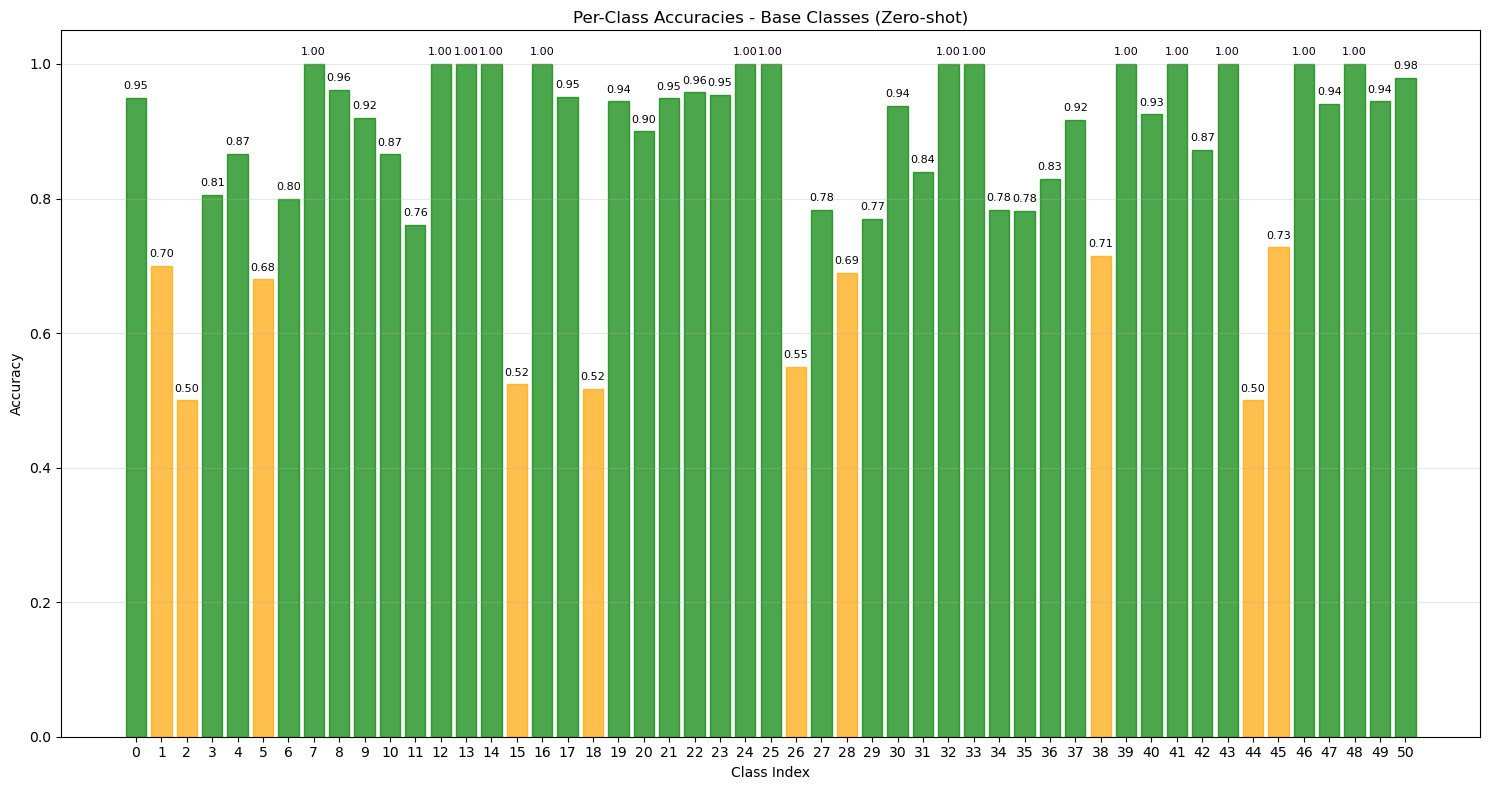


📊 Per-class accuracy statistics:
   Mean: 0.863
   Std:  0.149
   Min:  0.500
   Max:  1.000

🔍 All classes sorted by accuracy (lowest to highest):


,name,accuracy
2,campanula medium,0.50
44,eustoma exaltatum,0.50
18,chinese bellflower,0.52
15,trollius,0.52
26,amaranthus hypochondriacus,0.55
5,tiger lily,0.68
28,globe artichoke,0.69
1,silver slipper orchid,0.70
38,curcuma alismatifolia,0.71
45,erysimum,0.73


In [17]:
# define the new list of best performing class names
BEST_CLASS_NAMES = ["pink evening primrose", "silver slipper orchid", "campanula medium", "lathyrus odoratus",
                "calendula", "tiger lily", "moon orchid", "bird of paradise", "monkshood",
                "globe thistle", "snapdragon", "coltsfoot", "king protea", "spear thistle",
                "yellow iris", "trollius", "purple coneflower", "peruvian lily", "chinese bellflower",
                "giant white arum lily", "fire lily", "pincushion flower", "fritillary", "red ginger",
                "grape hyacinth", "corn poppy", "amaranthus hypochondriacus", "stemless gentian", "globe artichoke",
                "sweet william", "carnation", "garden phlox", "love-in-a-mist", "garden cosmos",
                "alpine sea holly", "ruby-lipped cattleya", "japanese spider lily", "astrantia major", "curcuma alismatifolia",
                "lenten rose", "gerbera jamesonii", "daffodil", "marsh gladiolus", "poinsettia", "eustoma exaltatum",
                "erysimum", "marigold", "buttercup", "oxeye daisy", "common dandelion", "petunia", "wild pansy",
                "primula", "sunflower", "lilac hibiscus", "dahlia bishop of llandaff", "gaura", "geranium", "tithonia rotundifolia",
                "orange dahlia", "cautleya spicata", "japanese anemone", "black-eyed susan", "shrubby bindweed",
                "californian poppy", "osteospermum", "spring crocus", "bearded iris", "wood anemone", "tree poppy",
                "gazania", "azalea", "water lily", "rose", "jimsonweed", "morning-glory", "passion flower", "lotus",
                "toad lily", "anthurium", "frangipani", "clematis", "hibiscus", "columbine", "desert-rose",
                "tree mallow", "magnolia", "cyclamen coum", "nasturtium", "canna lily", "hippeastrum", "bee balm",
                "tillandsia guatemalensis", "foxglove", "bougainvillea", "camellia", "abutilon", "ruellia", "bromelia",
                "blanket flower", "campsis radicans", "blackberry lily"]

# eval the model with new class names on base classes
base_accuracy, base_per_class_acc = eval(model=clip_model, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes", class_names=BEST_CLASS_NAMES)
print()
print(f"🔍 Base classes accuracy: {base_accuracy*100:.2f}%")
plot_per_class_accuracies(base_per_class_acc, BEST_CLASS_NAMES, base_classes, "Per-Class Accuracies - Base Classes (Zero-shot)")

🧠 Zero-shot evaluation on Novel Classes: 100%|██████████| 29/29 [00:16<00:00,  1.76it/s]



🔍 Novel classes accuracy: 93.50%


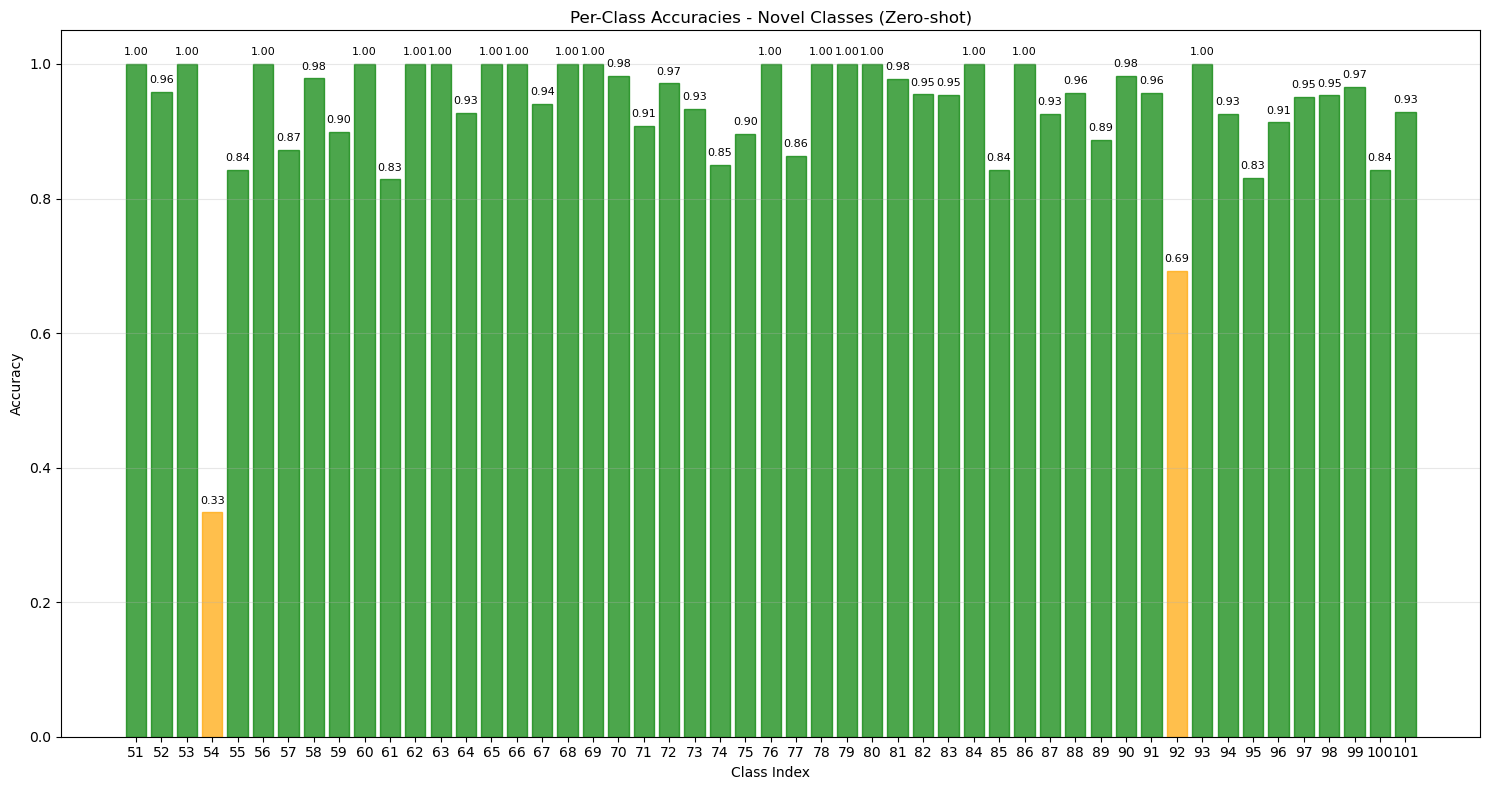


📊 Per-class accuracy statistics:
   Mean: 0.930
   Std:  0.106
   Min:  0.333
   Max:  1.000

🔍 All classes sorted by accuracy (lowest to highest):


,name,accuracy
54,lilac hibiscus,0.33
92,tillandsia guatemalensis,0.69
61,japanese anemone,0.83
95,camellia,0.83
85,tree mallow,0.84
100,campsis radicans,0.84
55,dahlia bishop of llandaff,0.84
74,jimsonweed,0.85
77,lotus,0.86
57,geranium,0.87


In [18]:
# and novel classes
novel_accuracy, novel_per_class_acc = eval(model=clip_model, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes", class_names=BEST_CLASS_NAMES)
print()
print(f"🔍 Novel classes accuracy: {novel_accuracy*100:.2f}%")
plot_per_class_accuracies(novel_per_class_acc, BEST_CLASS_NAMES, novel_classes, "Per-Class Accuracies - Novel Classes (Zero-shot)")

In [19]:
# and compute the new harmonic mean
hm = harmonic_mean(base_accuracy, novel_accuracy)
new_clip_accuracy_values = (base_accuracy, novel_accuracy, hm)
print(f"🔍 Harmonic Mean: {hm*100:.2f}%")

🔍 Harmonic Mean: 90.51%


In [20]:
# Display the results 
clip_results = pd.DataFrame({
    'Method': ['CLIP Zero-Shot (Original Names)', 'CLIP Zero-Shot (New Names)'],
    'Base Accuracy': [og_clip_accuracy_values[0]*100, new_clip_accuracy_values[0]*100],
    'Novel Accuracy': [og_clip_accuracy_values[1]*100, new_clip_accuracy_values[1]*100],
    'Harmonic Mean': [og_clip_accuracy_values[2]*100, new_clip_accuracy_values[2]*100]
})

print("\n📊 Detailed Results:")
print("=" * 90)

styled_results = clip_results.style.format({
    'Base Accuracy': '{:.2f}%',
    'Novel Accuracy': '{:.2f}%', 
    'Harmonic Mean': '{:.2f}%'
}).apply(highlight_best, subset=['Base Accuracy', 'Novel Accuracy', 'Harmonic Mean']).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
    {'selector': '', 'props': [('border-collapse', 'collapse'), ('font-family', 'Arial, sans-serif')]}
]).set_caption("CLIP Zero-Shot Performance Comparison").set_table_attributes('style="margin: auto; border: 2px solid #2E86AB;"')

display(styled_results)


📊 Detailed Results:


,Method,Base Accuracy,Novel Accuracy,Harmonic Mean
0,CLIP Zero-Shot (Original Names),71.33%,77.77%,74.41%
1,CLIP Zero-Shot (New Names),87.71%,93.50%,90.51%


The results are impressive: we achieve a base accuracy of 87.71% and a novel accuracy of 93.50%, leading to a harmonic mean of 90.51%.

This represents a substantial improvement over the original zero-shot performance of CLIP, with a gain of more than 15% in harmonic mean.

It is worth noting that this performance is likely not even close to the upper bound, as we did not perform an exhaustive search for the best aliases, and there may be further room for improvement by exploring additional synonyms or formatting variations.

However, the key takeaway is that by carefully selecting and optimizing class names, we can significantly enhance CLIP's zero-shot classification capabilities on fine-grained tasks like flower species recognition.

## LLM-generated Aliases
Lastly, we tried to generate a list of synonyms for each class through the use of a large language model, to get a glimpse of how well the model would perform without any human intervention.
To do so, we used Gemini 2.5 Flash through Google AI Studio free plan.


In [21]:
'''To generate the names, an API key from Google AI studio is required. It needs to then be present as environment variable named GOOGLE_API_KEY, either by 
setting it in the shell or by creating a .env file in the same directory as this notebook.The generatrion will take around 15 minutes to complete with 
a free plan, and consunme around half of the free quota requests of a day.'''
generate_names = True
try:
    load_dotenv()
    api_key = os.environ["GOOGLE_API_KEY"]
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel("gemini-2.5-flash")
except Exception as e:
    print("⚠️ Could not configure Google Gemini API. Stored names from previous generation will be used.")
    generate_names = False
    print(e)

⚠️ Could not configure Google Gemini API. Stored names from previous generation will be used.
'GOOGLE_API_KEY'


In [22]:
aliases_dict = {}

# Ask a question
prompt = """You are a concise, factual assistant that returns only lists of aliases (no explanations).

Instructions:
1) Given the canonical Flower/Plant name after the colon, return ONLY its common aliases or other names typically used to identify that specific flower.
2) Output must be a valid Python list literal (i.e. start with '[' and end with ']'). Example format exactly:
   Flower/Plant name: Chrysanthemums
   List of alternative names: ['Mums', 'Chrysanths']
3) Do NOT include any text besides the Python list for the requested flower (no labels, no punctuation outside the list, no trailing whitespace, no comments).
4) If there are no known aliases, return an empty list: []
5) Preserve capitalization as commonly used for each alias; include multi-word aliases as single strings.
6) If an alias is identical to the input name, do NOT repeat it.
7) If you are unsure about a name, prefer returning fewer aliases rather than guessing. Do not hallucinate.

Few-shot examples (must be followed exactly):
Flower/Plant name: Chrysanthemums
List of alternative names: ['Mums', 'Chrysanths']

Flower/Plant name: Bellis perennis
List of alternative names: ['English Daisy', 'Lawn Daisy', 'Common Daisy']

Now complete for the requested flower:
Flower/Plant name: {} 
List of alternative names:"""


In [23]:
if generate_names:
    for flower in CLASS_NAMES:
        formatted_prompt = prompt.format(flower)
        max_retries = 3
        retry_count = 0
        
        while retry_count < max_retries:
            try:
                response = model.generate_content(formatted_prompt)
                print(response.text)
                aliases = response.text.strip()
                
                # Use regex to extract only the list content between brackets
                list_pattern = r'\[.*?\]'
                match = re.search(list_pattern, aliases)
                
                if match:
                    list_string = match.group(0)
                    aliases_list = ast.literal_eval(list_string)
                    aliases_dict[flower] = aliases_list
                    break  # Success, exit retry loop
                else:
                    raise ValueError("No list pattern found in response")
            except ValueError as ve:
                continue  # Retry on parsing errors
            except Exception as e:
                print(e)
                retry_count += 1
                print(f"Error processing {flower} (attempt {retry_count}/{max_retries}): {e}")
                if retry_count < max_retries:
                    print("Waiting 60 seconds before retry...")
                    sleep(60)
                else:
                    print(f"Failed to process {flower} after {max_retries} attempts")
    GENERATED_AKA_CLASS_NAMES = []
    for key, value in aliases_dict.items():
        GENERATED_AKA_CLASS_NAMES.append([key] + value)
else:
    GENERATED_AKA_CLASS_NAMES = [["pink primrose","Evening primrose","Mexican primrose","Showy primrose","Oenothera speciosa","Pinkladies","Pink lady"],
                                 ["hard-leaved pocket orchid","Grass-leaved orchid","Japanese pocket orchid"],["canterbury bells"],
                                 ["sweet pea","lathyrus odoratus"],["english marigold","Pot Marigold","Calendula","Garden Marigold","Common Marigold"],
                                 ["tiger lily","Lilium lancifolium","Lilium tigrinum","Devil Lily","Leopard Lily","Outhouse Lily"],
                                 ["moon orchid","Phalaenopsis orchid","Phal orchid","Moth orchid"],
                                 ["bird of paradise","Crane Flower","Strelitzia","Orange Bird of Paradise"],
                                 ["monkshood","Aconitum","Wolfsbane","Devil's Helmet","Queen of Poisons","Blue Rocket","Helmet Flower"],
                                 ["globe thistle","Echinops","echinops thistle"],["snapdragon","Dragon flower","Dog flower"],
                                 ["colt's foot","Coughwort","Foalswort","Horsehoof","Clayweed","Ass's foot","Donnhove","Tussilago"],
                                 ["king protea","Giant Protea","Honeypot","King Sugar Bush"],["spear thistle","Bull Thistle","Common Thistle","Lance Thistle"],
                                 ["yellow iris","Yellow Flag","Yellow Flag Iris","Water Flag"],["globe-flower","Trollius","Globeflower"],
                                 ["purple coneflower","Echinacea","Eastern purple coneflower"],
                                 ["peruvian lily","Alstroemeria","Lily of the Incas","Princess Lily"],
                                 ["balloon flower","Platycodon","Chinese Bellflower","Japanese Bellflower","Korean Bellflower"],
                                 ["giant white arum lily","Calla Lily","White Arum Lily","Pig Lily","Trumpet Lily","Lily of the Nile","Ethiopian Lily"],
                                 ["fire lily","Orange Lily","St. John's Lily"],["pincushion flower","Scabious"],
                                 ["fritillary","Fritillaria","Snake's Head Fritillary","Chequered Lily","Crown Imperial","Guinea-hen flower"],
                                 ["red ginger","Ostrich Plume","Jungle Queen","Jungle King","Tahitian Ginger"],["grape hyacinth","Muscari"],
                                 ["corn poppy","common poppy","field poppy","Flanders poppy","Shirley poppy"],
                                 ["prince of wales feathers","Feather Celosia","Plumed Celosia"],
                                 ["stemless gentian","Trumpet Gentian","Alpine Gentian","Acaulis Gentian"],
                                 ["artichoke","Globe Artichoke","French Artichoke","Cynara scolymus","Thistle Artichoke"],
                                 ["sweet william","Dianthus barbatus","Bearded Pinks"],["carnation","Clove Pink","Dianthus caryophyllus","Grenadine"],
                                 ["garden phlox","Summer Phlox","Tall Garden Phlox","Perennial Phlox","Border Phlox","Phlox paniculata"],
                                 ["love in the mist","Nigella","Nigella damascena","Devil in the Bush","Lady-in-the-Bower"],
                                 ["mexican aster","Cosmos","Cosmea","Garden Cosmos"],["alpine sea holly","Alpine Thistle","Alpine Eryngo"],
                                 ["ruby-lipped cattleya","Cattleya","Cattleya orchid","Standard Cattleya","Autumn Cattleya"],
                                 ["cape flower","Cape primrose","Streptocarpus"],["great masterwort","masterwort","Astrantia major"],
                                 ["siam tulip","Curcuma alismatifolia","Summer Tulip","Tulip Ginger","Ginger Lily","Thai Tulip"],
                                 ["lenten rose","Christmas Rose","Hellebore","Winter Rose"],
                                 ["barbeton daisy","Gerbera Daisy","Transvaal Daisy","Veldt Daisy","Gerbera"],["daffodil","Narcissus","Jonquil","Lent Lily"],
                                 ["sword lily","Gladiolus","Gladioli"],["poinsettia","Christmas flower","Christmas star","Nochebuena","Mexican flameleaf"],
                                 ["bolero deep blue","Petunia 'Bolero Deep Blue'","Bolero Deep Blue Petunia","Bolero Petunia"],
                                 ["wallflower","Gillyflower","Erysimum"],["marigold","calendula","pot marigold","African marigold","French marigold","Tagetes"],
                                 ["buttercup","Crowfoot","Goldcup","Butter Rose","Kingcup"],
                                 ["oxeye daisy","Dog daisy","Moon daisy","Moonpenny","Field daisy","Marguerite"],
                                 ["common dandelion","Dandelion","Lion's Tooth","Blowball","Puffball","Piss-a-bed"],
                                 ["petunia","Wave Petunia","Supertunia","Calibrachoa"],
                                 ["wild pansy","Heartsease","Johnny Jump Up","Viola tricolor","Love-in-idleness","Tickle-my-fancy","Kiss-me-at-the-garden-gate","Three Faces in a Hood"],
                                 ["primula","Primrose"],["sunflower","Common Sunflower","Helianthus annuus"],["pelargonium","Geranium","Storksbill"],
                                 ["bishop of llandaff","Dahlia 'Bishop of Llandaff'","Bishop of Llandaff Dahlia"],
                                 ["gaura","Whirling Butterflies","Lindheimer's Beeblossom","Beeblossom"],["geranium","cranesbill","pelargonium"],
                                 ["orange dahlia",""],["pink-yellow dahlia?"],["cautleya spicata","Himalayan Ginger","Spiked Cautleya","Orange Ginger"],
                                 ["japanese anemone","Windflower","Anemone hupehensis","Thimbleweed"],
                                 ["black-eyed susan","Rudbeckia hirta","gloriosa daisy","yellow ox-eye daisy","brown-eyed susan","brown betty","coneflower","golden Jerusalem"],
                                 ["silverbush","Shrubby Bindweed","Mediterranean Silverbush"],
                                 ["californian poppy","Golden Poppy","California Poppy","Copa de Oro","Eschscholzia","State Flower of California"],
                                 ["osteospermum","African daisy","Cape daisy","Spoon daisy","Dimorphotheca"],["spring crocus","Dutch Crocus","Crocus vernus"],
                                 ["bearded iris","German Iris","Flag Iris"],["windflower","Anemone"],
                                 ["tree poppy","Dendromecon","Matilija poppy","California tree poppy","bush poppy"],["gazania","Treasure Flower","African Daisy"],
                                 ["azalea","Rhododendron","Shrub Azalea"],["water lily","Water Nymph","Lotus","Nymphaea"],["rose","Queen of Flowers"],
                                 ["thorn apple","Datura","Jimsonweed","Devil's Snare","Devil's Trumpet","Hell's Bells","Stinkweed","Loco Weed","Pricklyburr","Moonflower"],
                                 ["morning glory","bindweed","Heavenly Blue","Grandpa Ott","Ipomoea purpurea"],
                                 ["passion flower","Passiflora","Maypop","Purple Passionflower","Christ's Crown"],["lotus","Sacred Lotus","Indian Lotus"],
                                 ["toad lily","Tricyrtis","Japanese toad lily"],["anthurium","Flamingo Flower","Painter's Palette","Tailflower","Laceleaf"],
                                 ["frangipani","Plumeria","Lei flower","Temple flower","Pagoda flower"],
                                 ["clematis","Leather Flower","Vining Clematis","Virgin's Bower"],["hibiscus","Rose Mallow","China Rose","Shoeblackplant"],
                                 ["columbine","Granny’s Bonnet","Aquilegia","European Crowfoot"],
                                 ["desert-rose","Adenium","Sabi Star","Kudu Lily","Mock Azalea","Impala Lily","Star of Lundi"],
                                 ["tree mallow","Malva arborea","Lavatera arborea","sea mallow"],["magnolia","Mag","Magnolias"],
                                 ["cyclamen","Persian violet","Sowbread","Alpine violet"],["watercress","Water rocket"],
                                 ["canna lily","Canna","Indian Shot","Queensland Arrowroot"],["hippeastrum","Amaryllis","Christmas Amaryllis","Dutch Amaryllis"],
                                 ["bee balm","Monarda","Wild bergamot","Oswego tea","Bergamot"],["ball moss","Small ball moss","Bunch moss"],
                                 ["foxglove","Digitalis","Lady’s Glove","Fairy Thimbles","Dead Man’s Bells","Bloody Bells","Witches’ Gloves","Lion’s Mouth"],
                                 ["bougainvillea","Paperflower","Trinitaria"],["camellia","Winter Rose","Japanese Camellia","Common Camellia"],
                                 ["mallow","Malva","Cheeses","High Mallow","Common Mallow"],
                                 ["mexican petunia","Ruellia","Mexican bluebell","Britton's wild petunia","Lavender bells","Florida petunia"],
                                 ["bromelia","Bromeliad","Air Plant"],["blanket flower","Gaillardia","Indian Blanket","Firewheel"],
                                 ["trumpet creeper","Trumpet Vine","Cow-itch Vine","Devil's Shoestring","Hellflower"],
                                 ["blackberry lily","Leopard flower","Leopard lily","Belamcanda","Iris domestica","Apostle plant"]]

In [24]:
base_llm_generated_accuracy, base_llm_generated_log = aka_eval(model=clip_model, dataset=test_base, class_names=GENERATED_AKA_CLASS_NAMES, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_llm_generated_accuracy, novel_llm_generated_log = aka_eval(model=clip_model, dataset=test_novel, class_names=GENERATED_AKA_CLASS_NAMES, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
print()
print(f"🔍 Base classes accuracy: {base_llm_generated_accuracy*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_llm_generated_accuracy*100:.2f}%")
hm = harmonic_mean(base_llm_generated_accuracy, novel_llm_generated_accuracy)
print(f"🔍 Harmonic Mean: {hm*100:.2f}%")
llm_clip_accuracy_values = (base_llm_generated_accuracy, novel_llm_generated_accuracy, hm)

🧠 Zero-shot evaluation on Novel Classes: 100%|██████████| 29/29 [00:16<00:00,  1.77it/s]


🔍 Base classes accuracy: 74.32%
🔍 Novel classes accuracy: 73.34%
🔍 Harmonic Mean: 73.83%


In [25]:
# Display the results 
llm_clip_results = pd.DataFrame({
    'Method': ['LLM CLIP'],
    'Base Accuracy': [llm_clip_accuracy_values[0]*100],
    'Novel Accuracy': [llm_clip_accuracy_values[1]*100],
    'Harmonic Mean': [llm_clip_accuracy_values[2]*100]
})

print("\n📊 Detailed Results:")
print("=" * 90)

styled_results = llm_clip_results.style.format({
    'Base Accuracy': '{:.2f}%',
    'Novel Accuracy': '{:.2f}%', 
    'Harmonic Mean': '{:.2f}%'
}).apply(highlight_best, subset=['Base Accuracy', 'Novel Accuracy', 'Harmonic Mean']).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
    {'selector': '', 'props': [('border-collapse', 'collapse'), ('font-family', 'Arial, sans-serif')]}
]).set_caption("LLM-Generated CLIP Performance").set_table_attributes('style="margin: auto; border: 2px solid #2E86AB;"')

display(styled_results)


📊 Detailed Results:


,Method,Base Accuracy,Novel Accuracy,Harmonic Mean
0,AKA CLIP,74.32%,73.34%,73.83%


In [26]:
compute_alias_metrics(base_llm_generated_log, novel_llm_generated_log, class_names=GENERATED_AKA_CLASS_NAMES)

,id,correct_predictions,total_class_samples,total_predictions,precision,recall
pink primrose,0,4,20,5,0.80,0.20
Evening primrose,0,0,20,0,0.00,0.00
Mexican primrose,0,0,20,6,0.00,0.00
Showy primrose,0,0,20,2,0.00,0.00
Oenothera speciosa,0,12,20,14,0.86,0.60
Pinkladies,0,0,20,2,0.00,0.00
Pink lady,0,0,20,0,0.00,0.00
hard-leaved pocket orchid,1,0,40,1,0.00,0.00
Grass-leaved orchid,1,0,40,1,0.00,0.00
Japanese pocket orchid,1,4,40,4,1.00,0.10


,class_name,all_aliases,correct_predictions,total_samples,recall
0,pink primrose,"[pink primrose, Evening primrose, Mexican prim...",16,20,0.80
1,hard-leaved pocket orchid,"[hard-leaved pocket orchid, Grass-leaved orchi...",4,40,0.10
2,canterbury bells,[canterbury bells],1,20,0.05
3,sweet pea,"[sweet pea, lathyrus odoratus]",29,36,0.81
4,english marigold,"[english marigold, Pot Marigold, Calendula, Ga...",41,45,0.91
5,tiger lily,"[tiger lily, Lilium lancifolium, Lilium tigrin...",24,25,0.96
6,moon orchid,"[moon orchid, Phalaenopsis orchid, Phal orchid...",20,20,1.00
7,bird of paradise,"[bird of paradise, Crane Flower, Strelitzia, O...",65,65,1.00
8,monkshood,"[monkshood, Aconitum, Wolfsbane, Devil's Helme...",25,26,0.96
9,globe thistle,"[globe thistle, Echinops, echinops thistle]",20,25,0.80


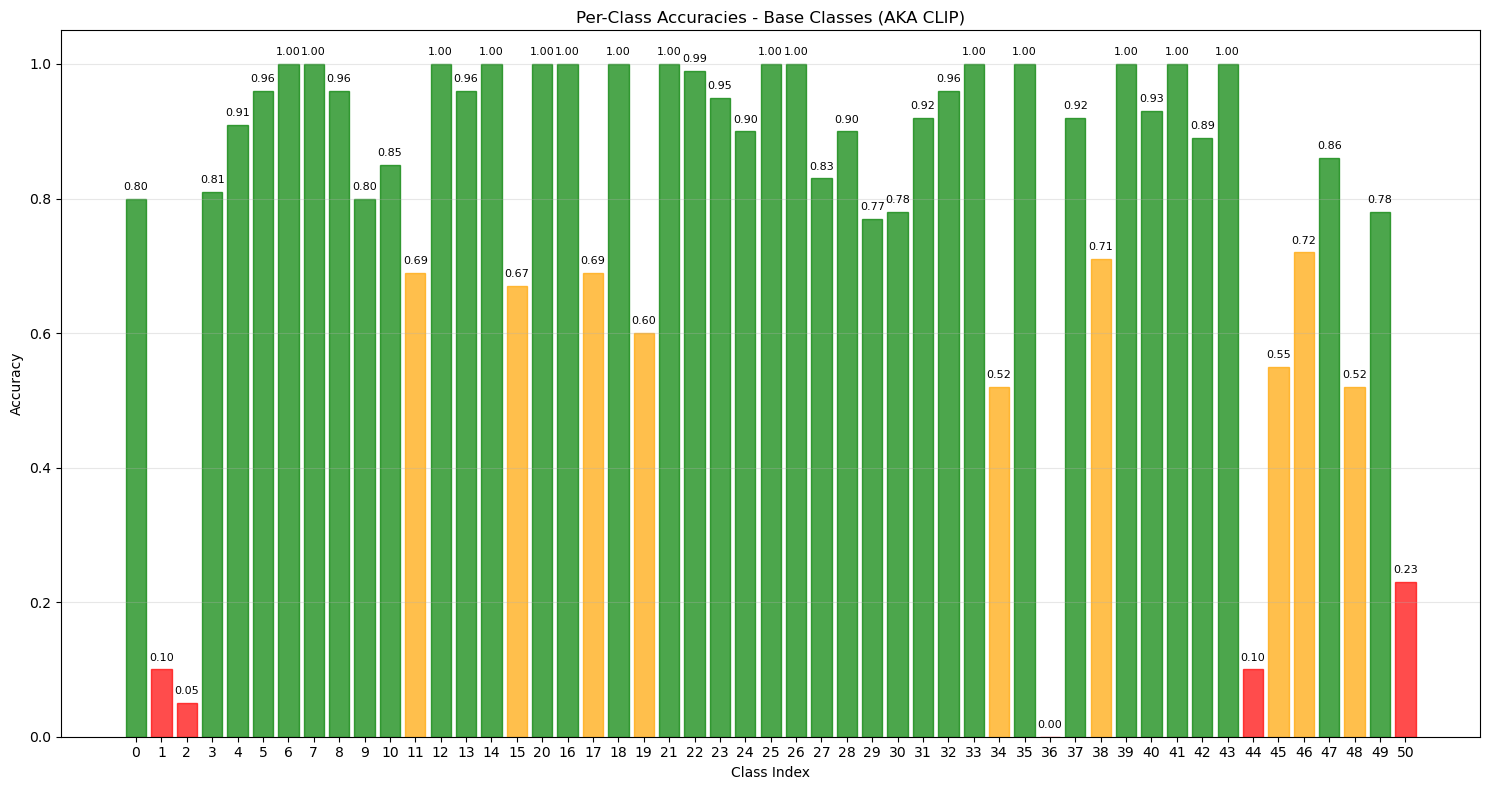


📊 Per-class accuracy statistics:
   Mean: 0.796
   Std:  0.269
   Min:  0.000
   Max:  1.000


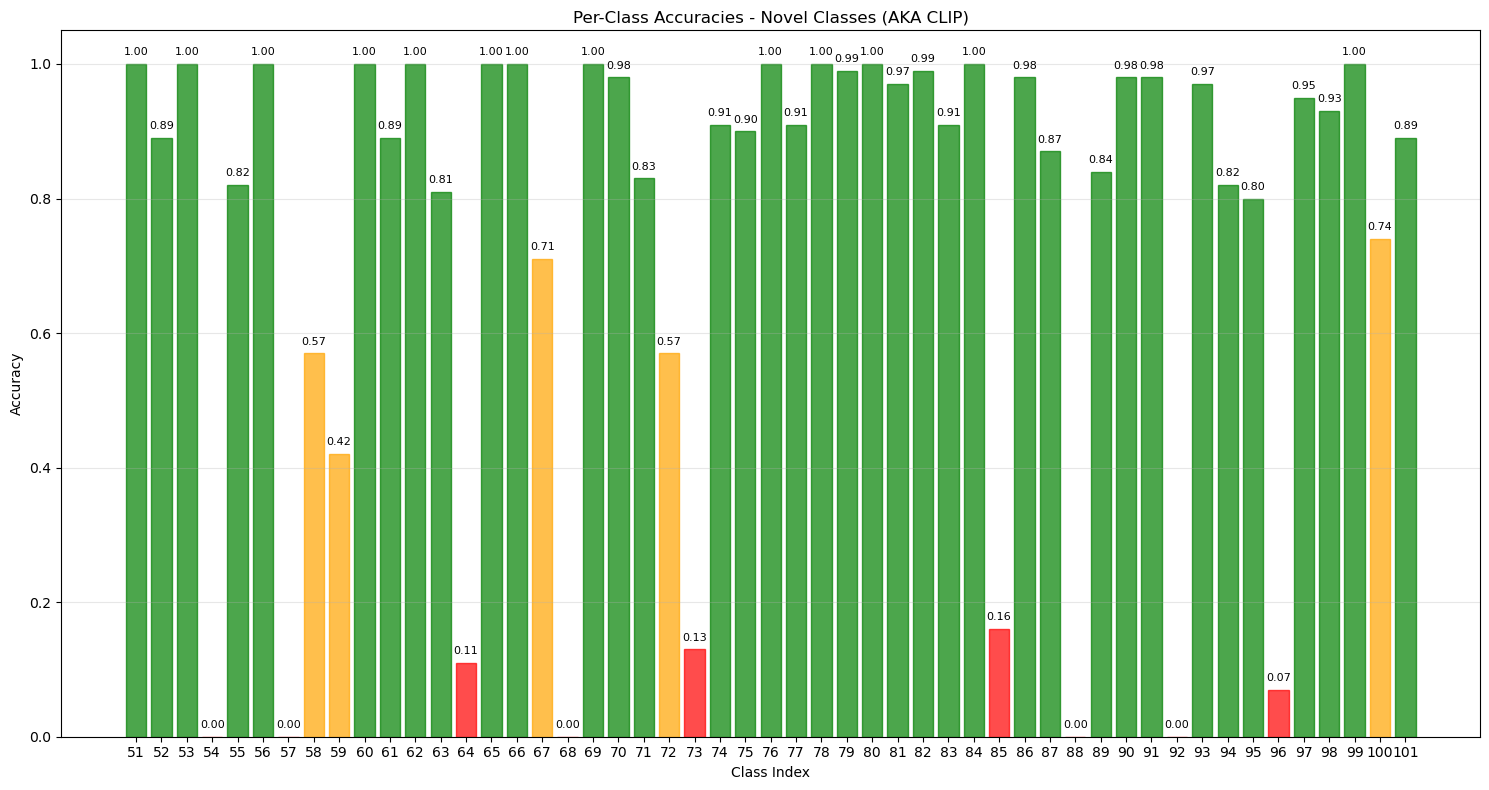


📊 Per-class accuracy statistics:
   Mean: 0.751
   Std:  0.346
   Min:  0.000
   Max:  1.000


In [27]:
compute_class_accuracies(base_llm_generated_log, novel_llm_generated_log, class_names=GENERATED_AKA_CLASS_NAMES)

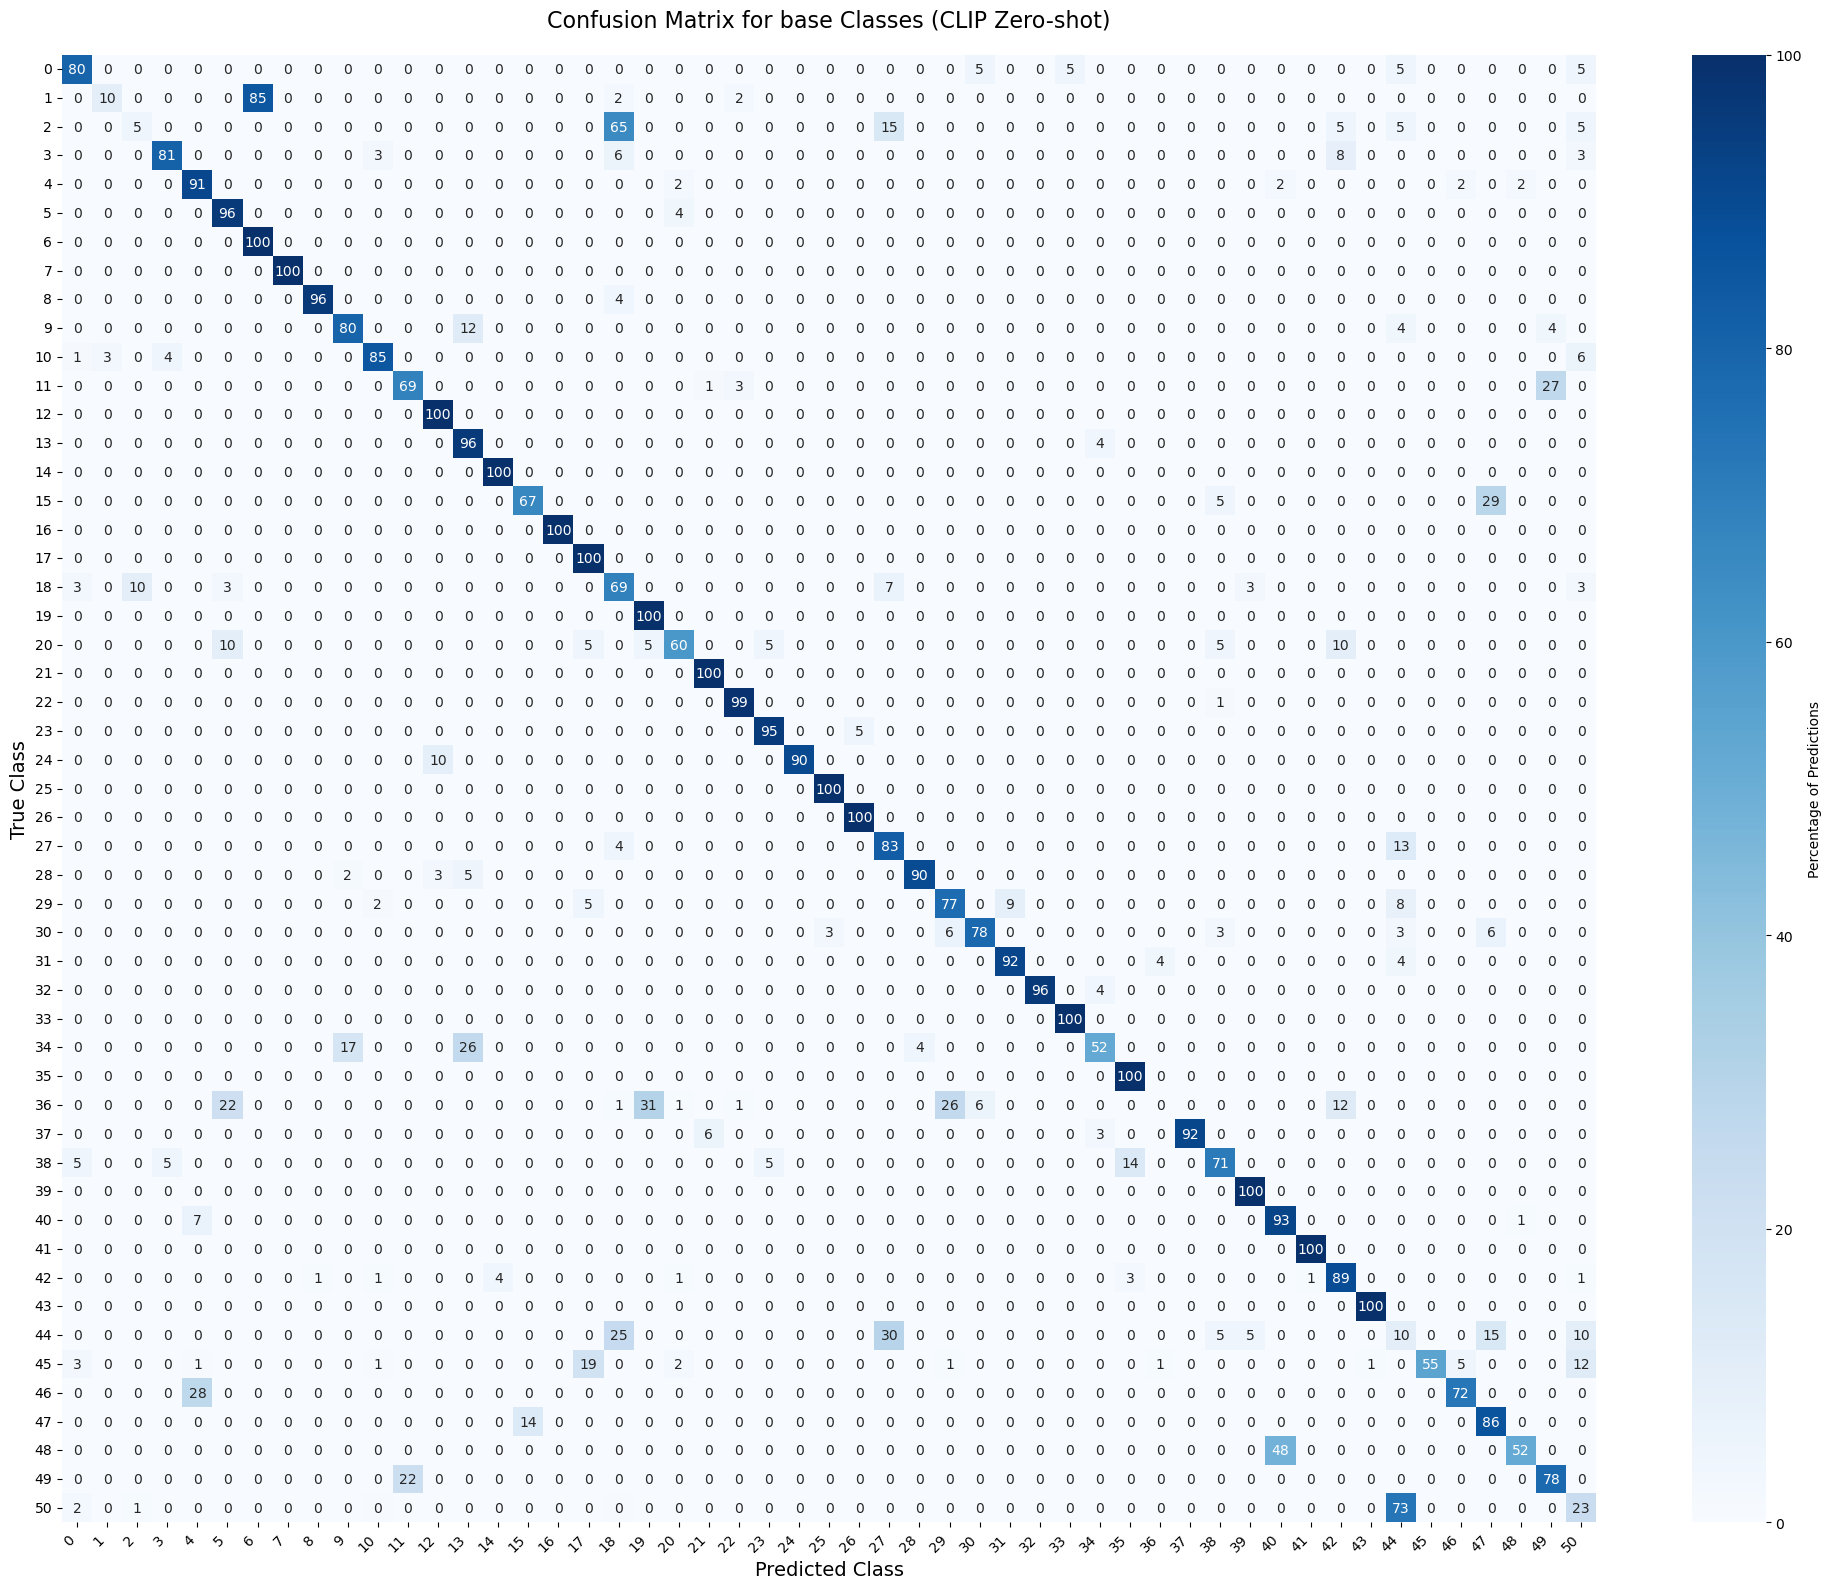

📊 Confusion Matrix Statistics:
Matrix shape: (51, 51)
Total predictions: 2473
Correct predictions (diagonal): 1838
Accuracy: 0.7432

🔀 Most confused pair:
True class: 1 (class 1)
Predicted as: 6 (class 6)
Confusion count: 85.0
Confusion percentage: 85.0%


In [28]:
class_confusion_matrix(base_llm_generated_log, base_classes, label="base", class_names=GENERATED_AKA_CLASS_NAMES)

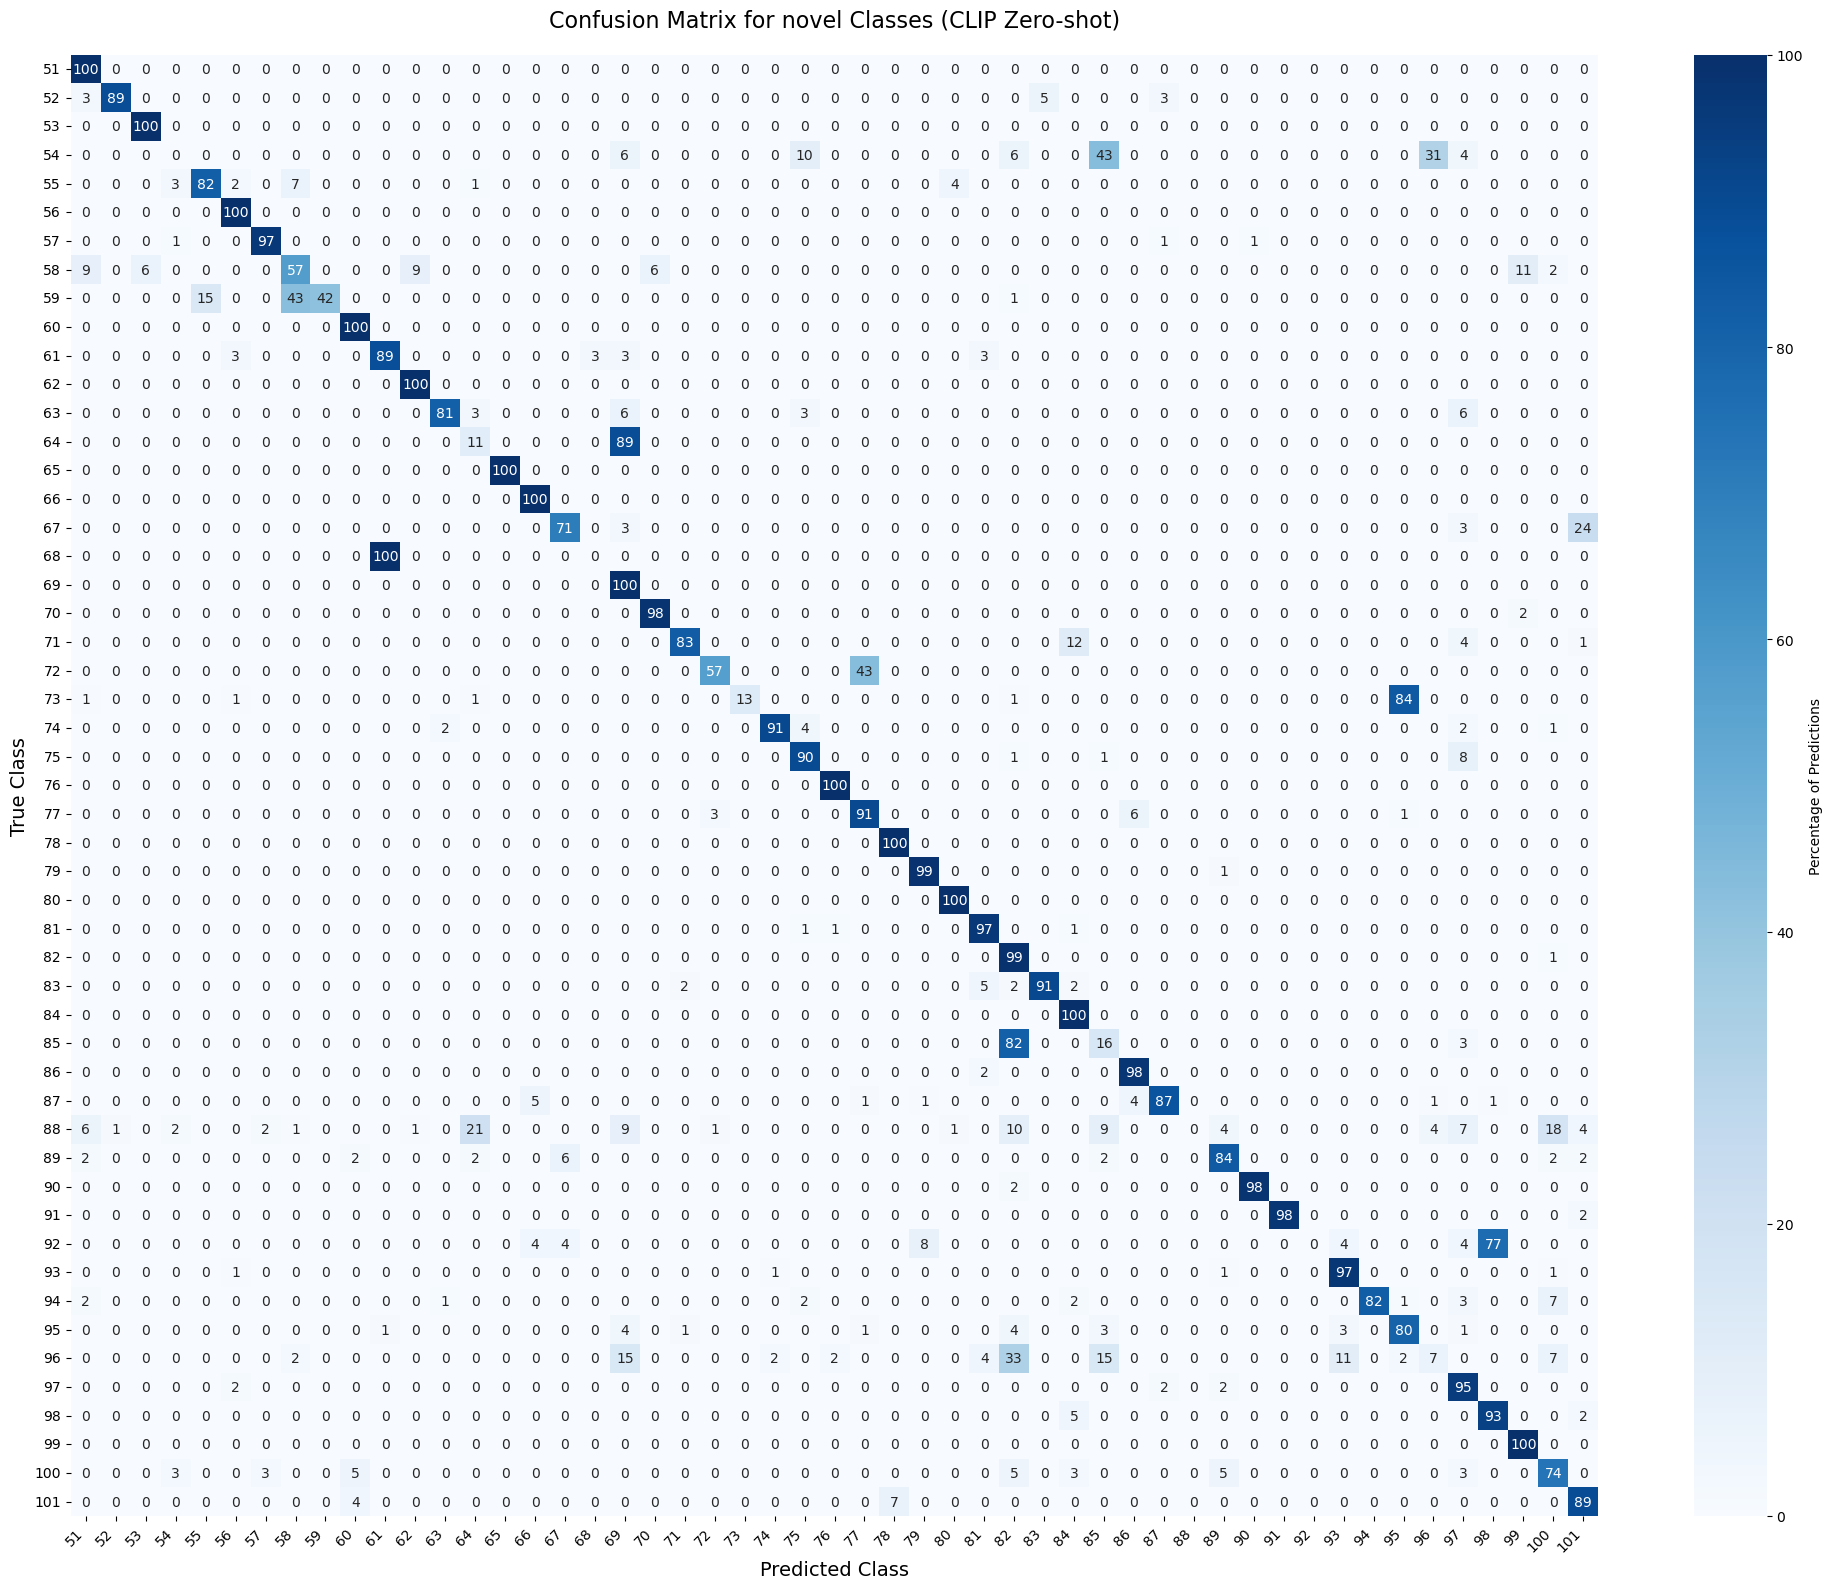

📊 Confusion Matrix Statistics:
Matrix shape: (51, 51)
Total predictions: 3676
Correct predictions (diagonal): 2787
Accuracy: 0.7582

🔀 Most confused pair:
True class: 68 (class 68)
Predicted as: 61 (class 61)
Confusion count: 100.0
Confusion percentage: 100.0%


In [29]:
class_confusion_matrix(novel_llm_generated_log, novel_classes, label="novel", class_names=GENERATED_AKA_CLASS_NAMES)

As we can see from the achieved results, simply using an LLM to generate a list of possible aliases for each class and using them concurrently doesn't help achieving satisfactory results. Some names that were initially wrong, create even more confusion in the classification task, that when added with some errors of the LLM and misalignment of knowledge between the two model leads to poor results.

## Three salient approaches from the literature: comparisons and conjunction

For the sake of further comparison and analysis, we decided to implement three notable methods from the literature: 
- Context Optimization (**CoOp** [3])
- Knowledge-Guided Context Optimization (**KgCoOp** [5])
- Conditional Context Optimization (**CoCoOp** [4])


All of them are PEFT methods based on *prompt learning*, that is, learning a set of context vectors to be fed to the text encoder along with the class names, instead of using a handcrafted prompt. Let's see them in detail in the following sections.

In [30]:
# Since the following methods are stochastic, we set a seed for reproducibility

def set_seed(seed=42):
    """Set random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set the seed for reproducibility
seed = 1328 # first number that came to my friend's mind
set_seed(seed)
print("Random seed set for reproducibility")

# Create a data generator for dataloaders
data_generator = torch.Generator()
data_generator.manual_seed(seed)

Random seed set for reproducibility


## Context Optimization (CoOp)
Context Optimization (CoOp) is a parameter-efficient fine-tuning method designed to adapt pre-trained VLMs like CLIP to downstream tasks with limited labeled data. Instead of manually designing prompts, CoOp learns a set of context vectors that are prepended to the class names, forming a learnable prompt for the text encoder. These vectors are optimized using cross-entropy loss on the few-shot training data while keeping the original CLIP parameters fixed. By backpropagating gradients through the text encoder, CoOp effectively distills task-relevant knowledge from the pre-trained model into the context vectors. This approach allows the model to adapt to specific classes in a dataset without modifying the pre trained image and text encoders. Although CoOp significantly improves accuracy, it may overfit the base classes, motivating later extensions like KgCoOp and CoCoOp for better generalization to novel classes.

Our implementation of CoOp follows the original paper closely and is inspired by the official codebase provided by the authors (https://github.com/KaiyangZhou/CoOp).

In [31]:
# freeze CLIP
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

In [32]:
class PromptLearner(nn.Module):
    def __init__(self, class_names, clip_model, n_ctx=16, ctx_init=None):
      super().__init__()
      self.class_names = class_names
      self.n_cls = len(class_names)
      self.n_ctx = n_ctx # number of context tokens to be learned. it is set to 16 by default but can modified
      self.clip_model = clip_model
      self.tokenizer = clip.tokenize

      # CLIP parameters
      self.dtype = clip_model.dtype
      ctx_dim = clip_model.ln_final.weight.shape[0]
      self.ctx_dim = ctx_dim
      self.device = next(clip_model.parameters()).device


      if ctx_init:
          # use given words to initialize context vectors
          ctx_init = ctx_init.replace("_", " ")
          n_ctx = len(ctx_init.split(" "))
          prompt = clip.tokenize(ctx_init).to(clip_model.token_embedding.weight.device)
          with torch.no_grad():
              embedding = clip_model.token_embedding(prompt).type(self.dtype)
          ctx_vectors = embedding[0, 1 : 1 + n_ctx, :]
          prompt_prefix = ctx_init
      else:
          # random initialization
          ctx_vectors = torch.empty(n_ctx, self.ctx_dim, dtype=self.dtype)
          nn.init.normal_(ctx_vectors, std=0.02)
          prompt_prefix = " ".join(["X"] * n_ctx)

      self.ctx = nn.Parameter(ctx_vectors)  # shared learnable context, to be optimized

      # we need to register the embeddings of the prefix and suffix for each class, to then create the prompts
      # to do this, we create a dummy prompt for each class
      name_lens = [len(self.tokenizer(name)[0]) for name in class_names]
      prompts = [prompt_prefix + " " + name + "." for name in class_names]

      tokenized_prompts = torch.cat([self.tokenizer(prompt) for prompt in prompts]).to(self.device)
      # no need for gradients here
      with torch.no_grad():
        embedding = clip_model.token_embedding(tokenized_prompts).type(self.dtype)

      self.register_buffer("token_prefix", embedding[:, :1, :]) # [n_cls, 1, 512] where 512 is the embedding dimension for CLIP's text encoder. This tensor basically keeps the start-of-sequence token embedding for each class
      self.register_buffer("token_suffix", embedding[:, 1 + n_ctx :, :]) # [n_cls, suffix_len, 512]. keeps the embedding of class name tokens, end-of-sequence token and padding tokens for each class

      # store for later use
      self.tokenized_prompts = tokenized_prompts
      self.name_lens = name_lens


    def forward(self):

      prefix = self.token_prefix
      ctx = self.ctx
      if ctx.dim() == 2:
            ctx = ctx.unsqueeze(0).expand(self.n_cls, -1, -1) # [n_ctx, 512] -> [n_cls, n_ctx, 512]
      suffix = self.token_suffix

      prompts = torch.cat(
        [
          prefix,
          ctx,
          suffix,
        ],
        dim = 1,
      )
      # prompts is a [n_cls, 77, 512] tensor where 77 is CLIP's max token sequence length

      return prompts

In [33]:
# we have to modify CLIP's text encoder because we will feed the already embedded tokens instead of the tokenized texts
class TextEncoder(nn.Module):
  def __init__(self, clip_model):
    super().__init__()
    # get CLIP's text encoder modules and parameters
    self.transformer = clip_model.transformer
    self.positional_embedding = clip_model.positional_embedding
    self.ln_final = clip_model.ln_final
    self.text_projection = clip_model.text_projection
    self.dtype = clip_model.dtype

  def forward(self, prompts, tokenized_prompts):
    # add positional embedding
    x = prompts + self.positional_embedding.type(self.dtype)

    # permute to match expected tranformer input
    x = x.permute(1,0,2)  # [seq_len, n_cls, embed_dim]

    # feed the prompts the into transformer
    x = self.transformer(x)

    # permute back to original shape
    x = x.permute(1,0,2)  # [n_cls, seq_len, embed_dim]
    
    # layer norm
    x = self.ln_final(x).type(self.dtype)

    # Extract the final token embedding (typically EOS token) for each class and project to output space
    x = x[torch.arange(x.shape[0]), tokenized_prompts.argmax(dim=-1)] @ self.text_projection

    return x
  


In [34]:
# CLIP wrapper class
class CoOp(nn.Module):
  def __init__(self, clip_model, class_names, n_ctx=16):
    super().__init__()
    self.prompt_learner = PromptLearner(clip_model=clip_model, class_names=class_names, n_ctx=n_ctx)
    self.tokenized_prompts = self.prompt_learner.tokenized_prompts
    self.text_encoder = TextEncoder(clip_model=clip_model)
    self.image_encoder = clip_model.visual
    self.logit_scale = clip_model.logit_scale
    self.dtype = clip_model.dtype


  def forward(self, images):

    # Encode images
    with torch.no_grad():
      image_features = self.image_encoder(images.type(self.dtype))

    # Encode text
    prompts = self.prompt_learner()
    tokenized_prompts = self.tokenized_prompts
    text_features = self.text_encoder(prompts, tokenized_prompts)

    # Normalize
    image_features = image_features / image_features.norm(dim=1, keepdim=True)
    text_features = text_features / text_features.norm(dim=1, keepdim=True)

    # Compute similarity logits
    logit_scale = self.logit_scale.exp()
    logits = logit_scale * image_features @ text_features.t()

    return logits

In [35]:
# training and eval functions
def coop_train_one_epoch(model, dataloader, optimizer, scheduler, loss_function, device):
  model.train()
  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  for images, labels in tqdm(dataloader, desc="Training", leave=False):
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    logits = model(images)
    loss = loss_function(logits, labels)
    loss.backward()
    optimizer.step()
  

    total_loss += loss.item() * images.size(0)
    total_correct += (logits.argmax(dim=1) == labels).sum().item()
    total_samples += images.size(0)

  avg_loss = total_loss / total_samples
  accuracy = total_correct / total_samples
  scheduler.step()
  return avg_loss, accuracy


def coop_evaluate(model, dataloader, device):
  model.eval()
  total_correct = 0
  total_samples = 0

  # no gradient needed for eval
  with torch.no_grad():
    for images, labels in tqdm(dataloader, desc="Evaluating", leave=False):
      images = images.to(device)
      labels = labels.to(device)

      logits = model(images)
      total_correct += (logits.argmax(dim=1) == labels).sum().item()
      total_samples += images.size(0)

  accuracy = total_correct / total_samples
  return accuracy

  

In [36]:
# Create properly remapped datasets for base classes
train_base_remapped = create_remapped_dataset(train_set, base_classes)
val_base_remapped = create_remapped_dataset(val_set, base_classes)
test_base_remapped = create_remapped_dataset(test_set, base_classes)

# Wrap with RemappedDataset to get correct labels
train_base_dataset = RemappedDataset(train_base_remapped)
val_base_dataset = RemappedDataset(val_base_remapped)
test_base_dataset = RemappedDataset(test_base_remapped)
base_class_names = [CLASS_NAMES[i] for i in base_classes]
base_best_class_names = [BEST_CLASS_NAMES[i] for i in base_classes]


In [37]:
# define batch size and data loaders
coop_batch_size = 32
coop_train_loader = torch.utils.data.DataLoader(
    train_base_dataset,
    batch_size=coop_batch_size,
    shuffle=True,
    num_workers=2,
    generator=data_generator
)
coop_val_loader = torch.utils.data.DataLoader(
    val_base_dataset,
    batch_size=coop_batch_size,
    shuffle=False,
    num_workers=2,
)
coop_test_loader = torch.utils.data.DataLoader(
    test_base_dataset,
    batch_size=coop_batch_size,
    shuffle=False,
    num_workers=2,
)

We will now train CoOp on the Oxford Flowers dataset using the same few-shot splits as before, and evaluate its performance on both base and novel classes.

We will also analyze its performance with the modified class names that we identified earlier, to see if combining label alignment with prompt learning can yield further improvements. 

In [38]:
# Training parameters
coop_num_epochs = 25
coop_n_ctx = 16 # same as specified in the paper

def train_and_eval_coop(names, num_epochs=coop_num_epochs, n_ctx=coop_n_ctx):
    if names == "og":
        base_class_names = [CLASS_NAMES[i] for i in base_classes]
        novel_class_names = [CLASS_NAMES[i] for i in novel_classes]
        model_name = "coop_best_model_og.pth"
    else:
        base_class_names = [BEST_CLASS_NAMES[i] for i in base_classes]
        novel_class_names = [BEST_CLASS_NAMES[i] for i in novel_classes]
        model_name = "coop_best_model_new.pth"
    # Initialize the CoOp model
    coop_model = CoOp(clip_model=clip_model, class_names=base_class_names, n_ctx=n_ctx).to(device)
    # Set up optimizer and scheduler - only optimize the context vectors
    # the type of optimizer and scheduler and their hyperparameters follow the paper 
    optimizer = torch.optim.SGD([coop_model.prompt_learner.ctx], lr=0.002, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200, eta_min=0.0001)
    # Loss function
    loss_function = nn.CrossEntropyLoss()
    best_val_acc = 0.0

    print(f"CoOp model initialized.")
    print(f"Context dimension: {coop_model.prompt_learner.ctx_dim}")
    print(f"Number of context tokens: {coop_model.prompt_learner.n_ctx}")
    print(f"Trainable parameters: {sum(p.numel() for p in coop_model.parameters() if p.requires_grad)}")

    # Verify that only context vectors are trainable
    print("\nTrainable parameters:")
    for name, param in coop_model.named_parameters():
        if param.requires_grad:
            print(f"  {name}: {param.shape}")

    # Training loop 
    print("Starting training")
    training_history = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        train_loss, train_acc = coop_train_one_epoch(coop_model, coop_train_loader, optimizer, scheduler, loss_function, device)

        # Validation phase
        val_acc = coop_evaluate(coop_model, coop_val_loader, device)

        # Save training history
        training_history['train_loss'].append(train_loss)
        training_history['train_acc'].append(train_acc)
        training_history['val_acc'].append(val_acc)

        # Print metrics
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_acc:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print(f"New best validation accuracy: {best_val_acc:.4f}")
            # Save model checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': coop_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, model_name)

    print(f"\nTraining completed!")
    print(f"Best validation accuracy: {best_val_acc:.4f}")

    # Eval

    # Load best model and evaluate on base test set
    checkpoint = torch.load(model_name)
    coop_model.load_state_dict(checkpoint['model_state_dict'])

    print()
    print("Starting evaluation on base test set...")
    print()

    base_test_acc = coop_evaluate(coop_model, coop_test_loader, device)
    print(f"Test Accuracy on Base Classes: {base_test_acc:.4f}")

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(training_history['train_loss'], label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(training_history['train_acc'], label='Training Accuracy')
    plt.plot(training_history['val_acc'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"\nFinal Results:")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"Base Test Accuracy: {base_test_acc:.4f}")

    # eval on novel classes

    # Create novel class datasets with remapped labels
    test_novel_remapped = create_remapped_dataset(test_set, novel_classes)
    test_novel_dataset = RemappedDataset(test_novel_remapped)
    
    # Create a new model for novel classes (same learned context, different class names)
    novel_coop_model = CoOp(clip_model=clip_model, class_names=novel_class_names, n_ctx=n_ctx).to(device)
    # Load the learned context from the trained model
    novel_coop_model.prompt_learner.ctx.data = coop_model.prompt_learner.ctx.data.clone()

    # Create data loader for novel classes
    test_novel_loader = torch.utils.data.DataLoader(
        test_novel_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2
    )
    
    print()
    print("Starting evaluation on novel test set...")
    print()
    print(f"Novel classes: {len(novel_classes)}")
    print(f"Novel test samples: {len(test_novel_dataset)}")

    # Evaluate on novel classes
    novel_test_acc = coop_evaluate(novel_coop_model, test_novel_loader, device)
    print(f"\nTest Accuracy on Novel Classes: {novel_test_acc:.4f}")

    # Compare base vs novel performance
    print(f"\n" + "="*60)
    print("FINAL COMPARISON")
    print("="*60)
    print(f"Base Classes Test Accuracy: {base_test_acc:.4f}")
    print(f"Novel Classes Test Accuracy: {novel_test_acc:.4f}")
    hm = harmonic_mean(base_test_acc, novel_test_acc)
    print(f"Harmonic mean: {hm:.4f}")

    return base_test_acc, novel_test_acc, hm


Training and evaluating CoOp with original class names
CoOp model initialized.
Context dimension: 512
Number of context tokens: 16
Trainable parameters: 8192

Trainable parameters:
  prompt_learner.ctx: torch.Size([16, 512])
Starting training

Epoch 1/25
--------------------------------------------------


Train Loss: 1.3123
Train Accuracy: 0.6216
Validation Accuracy: 0.7490
New best validation accuracy: 0.7490

Epoch 2/25
--------------------------------------------------


Train Loss: 0.8204
Train Accuracy: 0.7373
Validation Accuracy: 0.8098
New best validation accuracy: 0.8098

Epoch 3/25
--------------------------------------------------


Train Loss: 0.6468
Train Accuracy: 0.7902
Validation Accuracy: 0.8412
New best validation accuracy: 0.8412

Epoch 4/25
--------------------------------------------------


Train Loss: 0.5075
Train Accuracy: 0.8627
Validation Accuracy: 0.8686
New best validation accuracy: 0.8686

Epoch 5/25
--------------------------------------------------


...

Train Loss: 0.0269
Train Accuracy: 1.0000
Validation Accuracy: 0.9608
New best validation accuracy: 0.9608

Epoch 23/25
--------------------------------------------------


Train Loss: 0.0259
Train Accuracy: 1.0000
Validation Accuracy: 0.9588

Epoch 24/25
--------------------------------------------------


Train Loss: 0.0247
Train Accuracy: 1.0000
Validation Accuracy: 0.9588

Epoch 25/25
--------------------------------------------------


Train Loss: 0.0240
Train Accuracy: 1.0000
Validation Accuracy: 0.9569

Training completed!
Best validation accuracy: 0.9608

Starting evaluation on base test set...



Test Accuracy on Base Classes: 0.9567


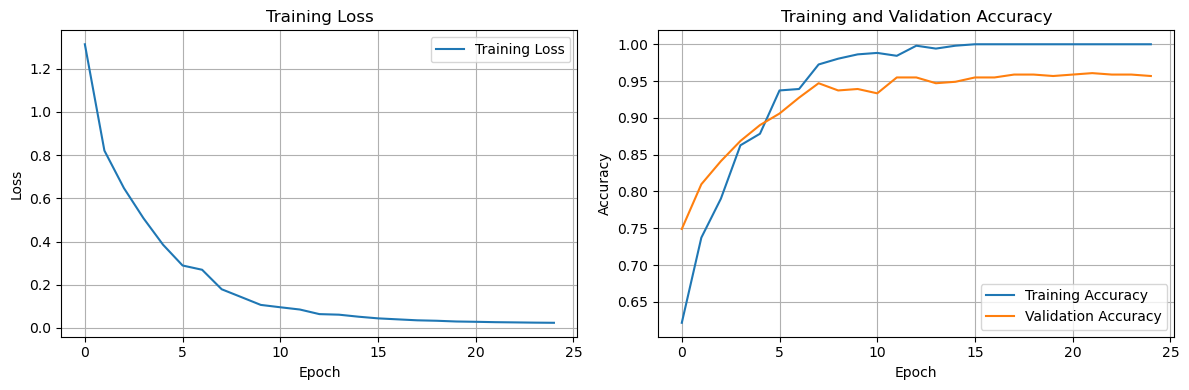


Final Results:
Best Validation Accuracy: 0.9608
Base Test Accuracy: 0.9567

Starting evaluation on novel test set...

Novel classes: 51
Novel test samples: 3676



Test Accuracy on Novel Classes: 0.6629

FINAL COMPARISON
Base Classes Test Accuracy: 0.9567
Novel Classes Test Accuracy: 0.6629
Harmonic mean: 0.7832

Training and evaluating CoOp with new class names
CoOp model initialized.
Context dimension: 512
Number of context tokens: 16
Trainable parameters: 8192

Trainable parameters:
  prompt_learner.ctx: torch.Size([16, 512])
Starting training

Epoch 1/25
--------------------------------------------------


Train Loss: 0.8590
Train Accuracy: 0.7412
Validation Accuracy: 0.8706
New best validation accuracy: 0.8706

Epoch 2/25
--------------------------------------------------


Train Loss: 0.3915
Train Accuracy: 0.8745
Validation Accuracy: 0.9078
New best validation accuracy: 0.9078

Epoch 3/25
--------------------------------------------------


Train Loss: 0.3254
Train Accuracy: 0.9020
Validation Accuracy: 0.9196
New best validation accuracy: 0.9196

Epoch 4/25
--------------------------------------------------


...

Train Loss: 0.0315
Train Accuracy: 1.0000
Validation Accuracy: 0.9569
New best validation accuracy: 0.9569

Epoch 23/25
--------------------------------------------------


Train Loss: 0.0287
Train Accuracy: 1.0000
Validation Accuracy: 0.9529

Epoch 24/25
--------------------------------------------------


Train Loss: 0.0264
Train Accuracy: 1.0000
Validation Accuracy: 0.9569

Epoch 25/25
--------------------------------------------------


Train Loss: 0.0256
Train Accuracy: 1.0000
Validation Accuracy: 0.9549

Training completed!
Best validation accuracy: 0.9569

Starting evaluation on base test set...



Test Accuracy on Base Classes: 0.9430


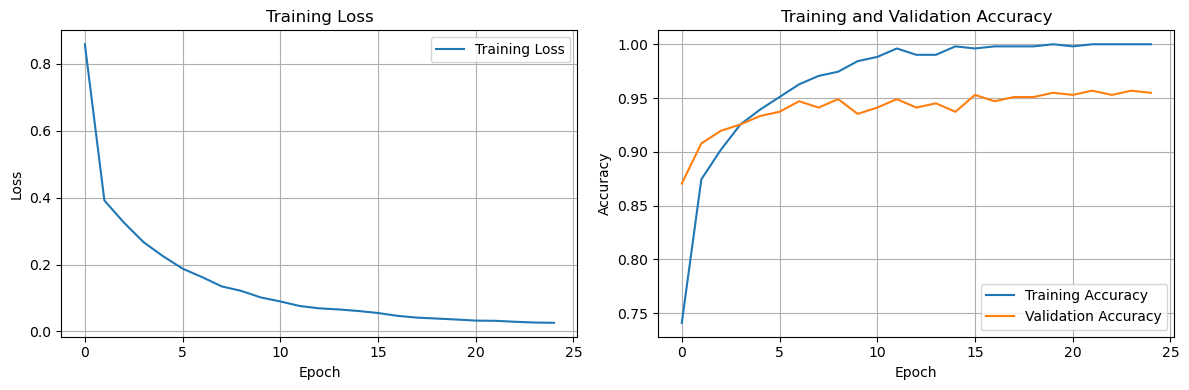


Final Results:
Best Validation Accuracy: 0.9569
Base Test Accuracy: 0.9430

Starting evaluation on novel test set...

Novel classes: 51
Novel test samples: 3676



Test Accuracy on Novel Classes: 0.8259

FINAL COMPARISON
Base Classes Test Accuracy: 0.9430
Novel Classes Test Accuracy: 0.8259
Harmonic mean: 0.8806


In [39]:
print("Training and evaluating CoOp with original class names")
og_coop_accuracy_values = train_and_eval_coop("og")

print()
print("Training and evaluating CoOp with new class names")
new_coop_accuracy_values = train_and_eval_coop("new")

In [40]:
# Display the results 
coop_results = pd.DataFrame({
    'Method': ['CoOp (Original Names)', 'CoOp (New Names)'],
    'Base Accuracy': [og_coop_accuracy_values[0]*100, new_coop_accuracy_values[0]*100],
    'Novel Accuracy': [og_coop_accuracy_values[1]*100, new_coop_accuracy_values[1]*100],
    'Harmonic Mean': [og_coop_accuracy_values[2]*100, new_coop_accuracy_values[2]*100]
})

print("\n📊 Detailed Results:")
print("=" * 90)


styled_results = coop_results.style.format({
    'Base Accuracy': '{:.2f}%',
    'Novel Accuracy': '{:.2f}%', 
    'Harmonic Mean': '{:.2f}%'
}).apply(highlight_best, subset=['Base Accuracy', 'Novel Accuracy', 'Harmonic Mean']).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
    {'selector': '', 'props': [('border-collapse', 'collapse'), ('font-family', 'Arial, sans-serif')]}
]).set_caption("CoOp Performance Comparison").set_table_attributes('style="margin: auto; border: 2px solid #2E86AB;"')

display(styled_results)


📊 Detailed Results:


,Method,Base Accuracy,Novel Accuracy,Harmonic Mean
0,CoOp (Original Names),95.67%,66.29%,78.32%
1,CoOp (New Names),94.30%,82.59%,88.06%


## Knowledge-Guided Context Optimization (KgCoOp)

KgCoOp is an extension of CoOp which addresses its main limitation: poor generalization to novel classes. While CoOp learns free context vectors that may overfit to the base categories, KgCoOp constrains the learning process with semantic knowledge derived from the class names themselves. Specifically, it regularizes the learned context prompts by encouraging their representations to stay close to those produced by hand-crafted templates (in our case, “a photo of {class_name}, a type of flower”). This knowledge-guided constraint prevents the prompts from drifting too far from the natural language space, improving transferability to unseen classes while retaining the adaptability of CoOp. As a result, KgCoOp balances the flexibility of learnable prompts with the robustness of manually designed ones, achieving stronger base-to-novel generalization in few-shot settings.

Our implementation of KgCoOp builds upon our CoOp codebase, adding the necessary regularization terms and modifications to the training loop. We will train KgCoOp on the same few-shot splits of the Oxford Flowers dataset, and evaluate its performance on both base and novel classes, and both with original and new class names.

In [41]:
# We build on top of the PromptLearner and TextEncoder classees of CoOp
# We only need a new CLIP wrapper

class KgCoOp(nn.Module):
    def __init__(self, class_names, clip_model, n_ctx=4, alpha=1.0):
        super().__init__()
        self.class_names = class_names
        self.clip_model = clip_model
        self.n_ctx = n_ctx # we fix it to 4 by default as said in the paper
        self.alpha = alpha # hyperparameter used in the loss

        self.prompt_learner = PromptLearner(class_names, clip_model, n_ctx)
        self.tokenized_prompts = self.prompt_learner.tokenized_prompts

        self.text_encoder = TextEncoder(clip_model)
        self.image_encoder = clip_model.visual

        self.logit_scale = clip_model.logit_scale
        self.dtype = clip_model.dtype
        self.device = next(clip_model.parameters()).device

        if self.training:
            self.targets = self._compute_targets()


    # the following function is used to compute the text features of the hand crafted prompts for each class
    # they will be used as a target in the custom loss function
    @torch.no_grad()
    def _compute_targets(self):
        # define hand crafted template. Standard for CLIP on Flowers102
        template = "A photo of a {}, a type of flower."

        # create the prompt for each class name
        prompts = [template.format(name) for name in self.class_names]
        
        # tokenize the prompts
        tokenized = clip.tokenize(prompts).to(self.device) # [n_cls, 77]

        # encode the tokenized prompts
        feats = self.clip_model.encode_text(tokenized).type(self.dtype) # [n_cls, 512]

        # and normalize
        feats /= feats.norm(dim=-1, keepdim=True)

        return feats
    
    # the following function is used to compute the the new loss function introduced by KgCoOp
    # here soft_feats is a [n_cls, 512] tensor composed by the embeddings of the learned prompts for each class
    def _compute_text_loss(self, soft_feats):
        # squared L2 norm per class
        per_class_dist = torch.norm(soft_feats - self.targets, dim=-1, p=2) ** 2
        # average across classes
        loss = self.alpha * per_class_dist.mean()
        return loss
    
    def forward(self, images):

        # Encode images
        with torch.no_grad():
            image_features = self.image_encoder(images.type(self.dtype))

        # Encode text
        prompts = self.prompt_learner()
        text_features = self.text_encoder(prompts, self.tokenized_prompts)

        # Normalize
        image_features = image_features / image_features.norm(dim=1, keepdim=True)
        text_features = text_features / text_features.norm(dim=1, keepdim=True)

        # Compute text loss if training
        if self.training:
            text_loss = self._compute_text_loss(text_features)
        else:
            text_loss = 0.0

        # Compute similarity logits
        logit_scale = self.logit_scale.exp()
        logits = logit_scale * image_features @ text_features.t()

        return logits, text_loss

In [42]:
# training and eval functions
def kgcoop_train_one_epoch(model, dataloader, optimizer, scheduler, loss_function, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        
        logits, text_loss = model(images)
        loss = loss_function(logits, labels) + text_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)

    scheduler.step()
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

def kgcoop_evaluate(model, dataloader, device):
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            logits, _ = model(images)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += images.size(0)
    
    accuracy = total_correct / total_samples
    return accuracy

In [ ]:
# training params
kgcoop_num_epochs = 25 
kgcoop_n_ctx = 4
kgcoop_alpha = 4.0 # in the paper it's 8.0 but we changed it for faster convergence

def train_and_eval_kgcoop(names, num_epochs=kgcoop_num_epochs, n_ctx=kgcoop_n_ctx, alpha=kgcoop_alpha):
    if names == "og":
        base_class_names = [CLASS_NAMES[i] for i in base_classes]
        novel_class_names = [CLASS_NAMES[i] for i in novel_classes]
        model_name = "kgcoop_best_model_og.pth"
    else:
        base_class_names = [BEST_CLASS_NAMES[i] for i in base_classes]
        novel_class_names = [BEST_CLASS_NAMES[i] for i in novel_classes]
        model_name = "kgcoop_best_model_new.pth"
    # Initialize the KgCoOp model
    kgcoop_model = KgCoOp(base_class_names, clip_model, n_ctx, alpha).to(device)
    # Set up optimizer and scheduler - only optimize the context vectors
    # the type of optimizer and scheduler and their hyperparameters follow the paper 
    optimizer = torch.optim.SGD([kgcoop_model.prompt_learner.ctx], lr=0.002, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200, eta_min=0.0001)
    # Loss function
    loss_function = nn.CrossEntropyLoss()
    best_val_acc = 0.0

    print(f"KgCoOp Model initialized")
    print(f"Context dimension: {kgcoop_model.prompt_learner.ctx_dim}")
    print(f"Number of context tokens: {kgcoop_model.prompt_learner.n_ctx}")
    print(f"Trainable parameters: {sum(p.numel() for p in kgcoop_model.parameters() if p.requires_grad)}")

    # Verify that only context vectors are trainable
    print("\nTrainable parameters:")
    for name, param in kgcoop_model.named_parameters():
        if param.requires_grad:
            print(f"  {name}: {param.shape}")

    # Training loop 
    print("Starting training")
    training_history = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        train_loss, train_acc = kgcoop_train_one_epoch(kgcoop_model, coop_train_loader, optimizer, scheduler, loss_function, device)

        # Validation phase
        val_acc = kgcoop_evaluate(kgcoop_model, coop_val_loader, device)

        # Save training history
        training_history['train_loss'].append(train_loss)
        training_history['train_acc'].append(train_acc)
        training_history['val_acc'].append(val_acc)

        # Print metrics
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_acc:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print(f"New best validation accuracy: {best_val_acc:.4f}")
            # Save model checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': kgcoop_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, model_name)

    print(f"\nTraining completed!")
    print(f"Best validation accuracy: {best_val_acc:.4f}")

    # Eval

    # Load best model and evaluate on base test set
    checkpoint = torch.load(model_name)
    kgcoop_model.load_state_dict(checkpoint['model_state_dict'])

    print()
    print("Starting evaluation on base test set...")
    print()

    base_test_acc = kgcoop_evaluate(kgcoop_model, coop_test_loader, device)
    print(f"Test Accuracy on Base Classes: {base_test_acc:.4f}")

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(training_history['train_loss'], label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(training_history['train_acc'], label='Training Accuracy')
    plt.plot(training_history['val_acc'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"\nFinal Results:")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"Base Test Accuracy: {base_test_acc:.4f}")

    # eval on novel classes

    # Create novel class datasets with remapped labels
    test_novel_remapped = create_remapped_dataset(test_set, novel_classes)
    test_novel_dataset = RemappedDataset(test_novel_remapped)
    
    # Create a new model for novel classes (same learned context, different class names)
    novel_kgcoop_model = KgCoOp(novel_class_names, clip_model, n_ctx=n_ctx).to(device)
    # Load the learned context from the trained model
    novel_kgcoop_model.prompt_learner.ctx.data = kgcoop_model.prompt_learner.ctx.data.clone()

    # Create data loader for novel classes
    test_novel_loader = torch.utils.data.DataLoader(
        test_novel_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2
    )
    
    print()
    print("Starting evaluation on novel test set...")
    print()
    print(f"Novel classes: {len(novel_classes)}")
    print(f"Novel test samples: {len(test_novel_dataset)}")

    # Evaluate on novel classes
    novel_test_acc = kgcoop_evaluate(novel_kgcoop_model, test_novel_loader, device)
    print(f"\nTest Accuracy on Novel Classes: {novel_test_acc:.4f}")

    # Compare base vs novel performance
    print(f"\n" + "="*60)
    print("FINAL COMPARISON")
    print("="*60)
    print(f"Base Classes Test Accuracy: {base_test_acc:.4f}")
    print(f"Novel Classes Test Accuracy: {novel_test_acc:.4f}")
    hm = harmonic_mean(base_test_acc, novel_test_acc)
    print(f"Harmonic mean: {hm:.4f}")

    return base_test_acc, novel_test_acc, hm


Training and evaluating KgCoOp with original class names
KgCoOp Model initialized
Context dimension: 512
Number of context tokens: 4
Trainable parameters: 2048

Trainable parameters:
  prompt_learner.ctx: torch.Size([4, 512])
Starting training

Epoch 1/25
--------------------------------------------------


Train Loss: 2.1837
Train Accuracy: 0.6667
Validation Accuracy: 0.7118
New best validation accuracy: 0.7118

Epoch 2/25
--------------------------------------------------


Train Loss: 1.3921
Train Accuracy: 0.6980
Validation Accuracy: 0.7588
New best validation accuracy: 0.7588

Epoch 3/25
--------------------------------------------------


Train Loss: 1.2202
Train Accuracy: 0.7569
Validation Accuracy: 0.7824
New best validation accuracy: 0.7824

Epoch 4/25
--------------------------------------------------


Train Loss: 1.1011
Train Accuracy: 0.7882
Validation Accuracy: 0.8137
New best validation accuracy: 0.8137

Epoch 5/25
--------------------------------------------------


...

Train Loss: 0.5671
Train Accuracy: 0.9529
Validation Accuracy: 0.9294

Epoch 23/25
--------------------------------------------------


Train Loss: 0.5530
Train Accuracy: 0.9451
Validation Accuracy: 0.9373

Epoch 24/25
--------------------------------------------------


Train Loss: 0.5340
Train Accuracy: 0.9490
Validation Accuracy: 0.9235

Epoch 25/25
--------------------------------------------------


Train Loss: 0.5216
Train Accuracy: 0.9608
Validation Accuracy: 0.9373

Training completed!
Best validation accuracy: 0.9431

Starting evaluation on base test set...



Test Accuracy on Base Classes: 0.9135


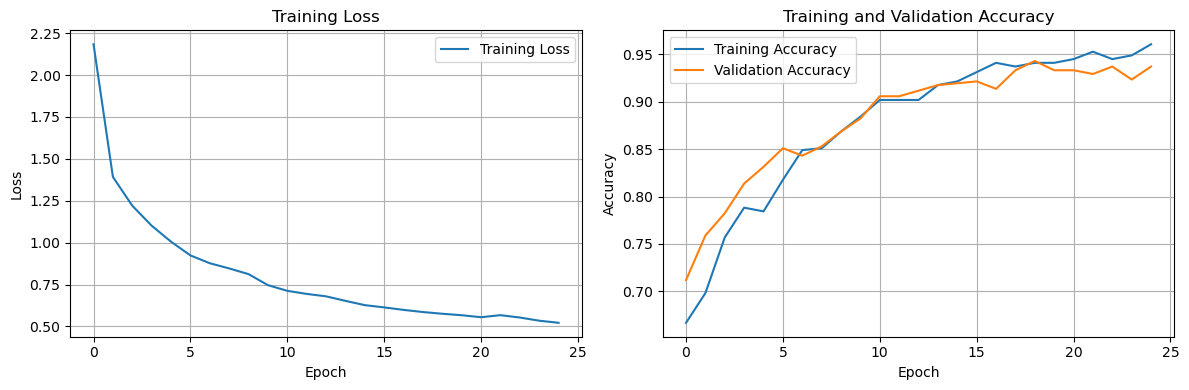


Final Results:
Best Validation Accuracy: 0.9431
Base Test Accuracy: 0.9135

Starting evaluation on novel test set...

Novel classes: 51
Novel test samples: 3676



Test Accuracy on Novel Classes: 0.7590

FINAL COMPARISON
Base Classes Test Accuracy: 0.9135
Novel Classes Test Accuracy: 0.7590
Harmonic mean: 0.8291

Training and evaluating KgCoOp with new class names
KgCoOp Model initialized
Context dimension: 512
Number of context tokens: 4
Trainable parameters: 2048

Trainable parameters:
  prompt_learner.ctx: torch.Size([4, 512])
Starting training

Epoch 1/25
--------------------------------------------------


Train Loss: 1.2394
Train Accuracy: 0.8235
Validation Accuracy: 0.8725
New best validation accuracy: 0.8725

Epoch 2/25
--------------------------------------------------


Train Loss: 0.6911
Train Accuracy: 0.8647
Validation Accuracy: 0.8804
New best validation accuracy: 0.8804

Epoch 3/25
--------------------------------------------------


Train Loss: 0.5790
Train Accuracy: 0.8863
Validation Accuracy: 0.9000
New best validation accuracy: 0.9000

Epoch 4/25
--------------------------------------------------


...

Train Loss: 0.3250
Train Accuracy: 0.9529
Validation Accuracy: 0.9353

Epoch 23/25
--------------------------------------------------


Train Loss: 0.3197
Train Accuracy: 0.9529
Validation Accuracy: 0.9451
New best validation accuracy: 0.9451

Epoch 24/25
--------------------------------------------------


Train Loss: 0.3166
Train Accuracy: 0.9510
Validation Accuracy: 0.9275

Epoch 25/25
--------------------------------------------------


Train Loss: 0.3122
Train Accuracy: 0.9549
Validation Accuracy: 0.9373

Training completed!
Best validation accuracy: 0.9451

Starting evaluation on base test set...



Test Accuracy on Base Classes: 0.9345


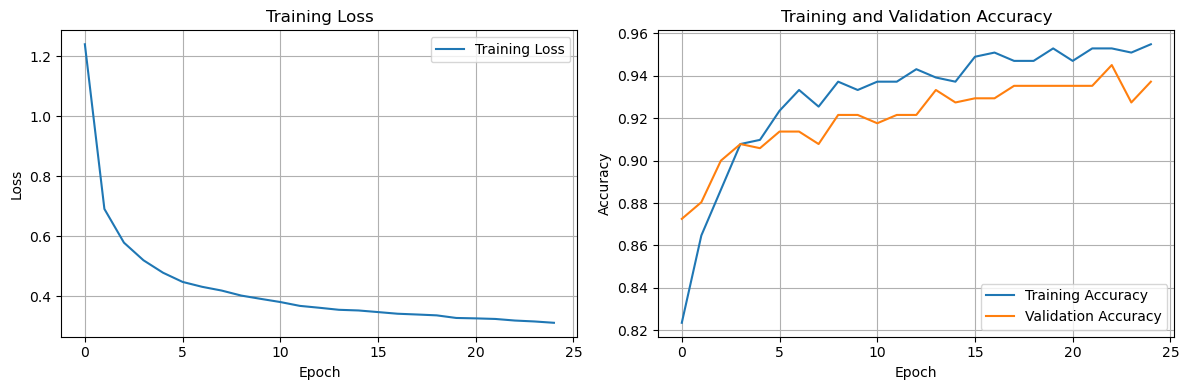


Final Results:
Best Validation Accuracy: 0.9451
Base Test Accuracy: 0.9345

Starting evaluation on novel test set...

Novel classes: 51
Novel test samples: 3676



Test Accuracy on Novel Classes: 0.9227

FINAL COMPARISON
Base Classes Test Accuracy: 0.9345
Novel Classes Test Accuracy: 0.9227
Harmonic mean: 0.9286


In [44]:
print("Training and evaluating KgCoOp with original class names")
og_kgcoop_accuracy_values = train_and_eval_kgcoop("og")

print()
print("Training and evaluating KgCoOp with new class names")
new_kgcoop_accuracy_values = train_and_eval_kgcoop("new")

In [45]:
# Display the results 
kgcoop_results = pd.DataFrame({
    'Method': ['KgCoOp (Original Names)', 'KgCoOp (New Names)'],
    'Base Accuracy': [og_kgcoop_accuracy_values[0]*100, new_kgcoop_accuracy_values[0]*100],
    'Novel Accuracy': [og_kgcoop_accuracy_values[1]*100, new_kgcoop_accuracy_values[1]*100],
    'Harmonic Mean': [og_kgcoop_accuracy_values[2]*100, new_kgcoop_accuracy_values[2]*100]
})

print("\n📊 Detailed Results:")
print("=" * 90)

styled_results = kgcoop_results.style.format({
    'Base Accuracy': '{:.2f}%',
    'Novel Accuracy': '{:.2f}%', 
    'Harmonic Mean': '{:.2f}%'
}).apply(highlight_best, subset=['Base Accuracy', 'Novel Accuracy', 'Harmonic Mean']).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
    {'selector': '', 'props': [('border-collapse', 'collapse'), ('font-family', 'Arial, sans-serif')]}
]).set_caption("KgCoOp Performance Comparison").set_table_attributes('style="margin: auto; border: 2px solid #2E86AB;"')

display(styled_results)


📊 Detailed Results:


,Method,Base Accuracy,Novel Accuracy,Harmonic Mean
0,KgCoOp (Original Names),91.35%,75.90%,82.91%
1,KgCoOp (New Names),93.45%,92.27%,92.86%


## CoCoOp

If CoOp allowed to learn the context by learning a single representation acrossed all training data, CoCoOp provides a dual approach, learning to generate a perturbation conditioned by the current image along the initial learnable context, that influences the resulting text features for each single instance.
CoCoOp is implemented by instantiating a lightweight neural network, called Meta-Net(consisting of two linear layers with a RELU activation in between), on top of the M context vectors, to generate for each input a conditional token (vector), which is then summed with the context vectors.
Using cross-entropy loss, the weights of the meta-net are learned along the original context vectors token. CoCoOp offers sifgnificantly better performance on novel classes compared to CoOp, while only slighly degrading performance on base classes, but it's still outperformed on both by KgCoOp.

Our implementation of CoCoOp follows the original paper closely and is inspired by the official codebase provided by the authors (https://github.com/KaiyangZhou/CoOp).

In [46]:
from typing import override

# we extend the PromptLearner class to add the MetaNet introduced by CoCoOp
class CoCoOpPromptLearner(PromptLearner):
    def __init__(self, class_names, clip_model, n_ctx=4, ctx_init=None):
        super().__init__(class_names, clip_model, n_ctx, ctx_init)
        vis_dim = clip_model.visual.output_dim
        self.meta_net = nn.Sequential(OrderedDict([
            ("linear1", nn.Linear(vis_dim, vis_dim // 16)),
            ("relu", nn.ReLU(inplace=True)),
            ("linear2", nn.Linear(vis_dim // 16, self.ctx_dim))
        ]))
        self.meta_net.to(self.dtype)

    # Construct complete prompts by concatenating prefix, context, and suffix
    def construct_prompts(self, ctx, prefix, suffix, label=None):
        # dim0 is either batch_size (during training) or n_cls (during testing)
        # ctx: context tokens, with shape of (dim0, n_ctx, ctx_dim)
        # prefix: the sos token, with shape of (n_cls, 1, ctx_dim)
        # suffix: remaining tokens, with shape of (n_cls, *, ctx_dim)

        # If specific labels are provided, select corresponding prefix/suffix
        if label is not None:
            prefix = prefix[label]
            suffix = suffix[label]

        # Concatenate all prompt components
        prompts = torch.cat(
            [
                prefix,  # (dim0, 1, dim)
                ctx,     # (dim0, n_ctx, dim)
                suffix,  # (dim0, *, dim)
            ],
            dim=1,
        )

        return prompts
    
    @override
    def forward(self, im_features):
        prefix = self.token_prefix
        suffix = self.token_suffix
        # Base context vectors (shared across all images)
        ctx = self.ctx                     # (n_ctx, ctx_dim)
        # Generate image-conditional bias based on image features
        im_features = im_features.to(self.ctx.dtype)
        bias = self.meta_net(im_features)  # (batch, ctx_dim)
        # Reshape bias to match context dimensions
        bias = bias.unsqueeze(1)           # (batch, 1, ctx_dim)
        # Expand base context to batch dimension
        ctx = ctx.unsqueeze(0)             # (1, n_ctx, ctx_dim)
        # Apply conditional shift: this is where CoCoOp differs from CoOp
        ctx_shifted = ctx + bias           # (batch, n_ctx, ctx_dim)

        # Use instance-conditioned context tokens for all classes
        # For each image in the batch, create prompts for all classes
        prompts = []
        for ctx_shifted_i in ctx_shifted:
            # Expand the shifted context for this image to all classes
            ctx_i = ctx_shifted_i.unsqueeze(0).expand(self.n_cls, -1, -1)
            # Construct complete prompts for all classes
            pts_i = self.construct_prompts(ctx_i, prefix, suffix)  # (n_cls, n_tkn, ctx_dim)
            prompts.append(pts_i)
        # Stack prompts for all images in batch
        prompts = torch.stack(prompts)

        return prompts

In [47]:
# Main model that combines image encoder, prompt learner, and text encoder
# Text encoder is the same as CoOp
class CoCoOpCustomCLIP(nn.Module):
    def __init__(self, classnames, clip_model, n_ctx, ctx_init=None):
        super().__init__()
        # Initialize the conditional prompt learner
        self.prompt_learner = CoCoOpPromptLearner(classnames, clip_model, n_ctx, ctx_init=ctx_init)
        self.tokenized_prompts = self.prompt_learner.tokenized_prompts
        # Use pre-trained CLIP components
        self.image_encoder = clip_model.visual
        self.text_encoder = TextEncoder(clip_model)
        self.logit_scale = clip_model.logit_scale
        self.dtype = clip_model.dtype

    def forward(self, image, label=None):
        tokenized_prompts = self.tokenized_prompts
        # Get learnable temperature parameter from CLIP
        logit_scale = self.logit_scale.exp()

        # Encode images using CLIP's visual encoder
        image_features = self.image_encoder(image.type(self.dtype))
        # Normalize image features
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Generate conditional prompts based on image features
        prompts = self.prompt_learner(image_features)

        # Compute logits for each image-prompt pair
        logits = []
        for pts_i, imf_i in zip(prompts, image_features):
            # Encode text prompts for current image
            text_features = self.text_encoder(pts_i, tokenized_prompts)
            # Normalize text features
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            # Compute similarity scores (logits) between image and all class prompts
            l_i = logit_scale * imf_i @ text_features.t()
            logits.append(l_i)
        # Stack logits for all images
        logits = torch.stack(logits)

        # During training, return cross-entropy loss
        if self.prompt_learner.training:
            return F.cross_entropy(logits, label)

        # During inference, return logits
        return logits

In [48]:
# Create data loaders
cocoop_batch_size = 1
cocoop_train_loader = torch.utils.data.DataLoader(
    train_base_dataset,
    batch_size=cocoop_batch_size,
    shuffle=True,
    num_workers=2,
    generator=data_generator
)
cocoop_val_loader = torch.utils.data.DataLoader(
    val_base_dataset,
    batch_size=cocoop_batch_size,
    shuffle=False,
    num_workers=2
)
cocoop_test_loader = torch.utils.data.DataLoader(
    test_base_dataset,
    batch_size=cocoop_batch_size,
    shuffle=False,
    num_workers=2
)

In [49]:
def cocoop_train_one_epoch(model, dataloader, optimizer, scheduler, loss_function, device):
  model.train()
  total_loss = 0.0
  total_correct = 0
  total_samples = 0

  for images, labels in tqdm(dataloader, desc="Training...", leave=False):
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    loss = model(images, labels)
    # logits = model(images)
    # loss = loss_function(logits, labels)
    loss.backward()
    optimizer.step()


    with torch.no_grad():
        model.eval()  # Temporarily switch to eval mode for logits
        logits = model(images)  # Get logits for accuracy calculation
        model.train()  # Switch back to training mode
    total_loss += loss.item() * images.size(0)
    total_correct += (logits.argmax(dim=1) == labels).sum().item()
    total_samples += images.size(0)

  scheduler.step()
  avg_loss = total_loss / total_samples
  accuracy = total_correct / total_samples
  return avg_loss, accuracy


def cocoop_evaluate(model, dataloader, device):
  model.eval()
  total_correct = 0
  total_samples = 0

  with torch.no_grad():
    for images, labels in tqdm(dataloader, desc="Evaluating...", leave=False):
      images = images.to(device)
      labels = labels.to(device)

      logits = model(images)
      total_correct += (logits.argmax(dim=1) == labels).sum().item()
      total_samples += images.size(0)

  accuracy = total_correct / total_samples
  return accuracy

In [50]:
# training params
cocoop_num_epochs = 10

def train_and_eval_cocoop(names, num_epochs=cocoop_num_epochs):
    if names == "og":
        base_class_names = [CLASS_NAMES[i] for i in base_classes]
        novel_class_names = [CLASS_NAMES[i] for i in novel_classes]
        model_name = "cocoop_best_model_og.pth"
    else:
        base_class_names = [BEST_CLASS_NAMES[i] for i in base_classes]
        novel_class_names = [BEST_CLASS_NAMES[i] for i in novel_classes]
        model_name = "cocoop_best_model_new.pth"
    # Initialize the CoCoOp model
    cocoop_model = CoCoOpCustomCLIP(classnames=base_class_names, clip_model=clip_model, n_ctx=4, ctx_init="A photo of a").to(device)
    name_to_update = "prompt_learner"
    for name, param in cocoop_model.named_parameters():
        if name_to_update not in name:
            param.requires_grad_(False)
    # Set up optimizer and scheduler - only optimize the context vectors
    # the type of optimizer and scheduler and their hyperparameters follow the paper 
    optimizer = torch.optim.SGD(
        filter(lambda p: p.requires_grad, cocoop_model.parameters()),
        lr=0.002,
        momentum=0.9,
        weight_decay=0.0,
        dampening=0.0,
        nesterov=False
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=10,           # MAX_EPOCH: 10 (not 200)
        eta_min=1e-5        # WARMUP_CONS_LR: 1e-5 (not 0.0001)
    )
    # Loss function
    loss_function = nn.CrossEntropyLoss()
    best_val_acc = 0.0

    print(f"CoCoOp Model initialized")
    print(f"Context dimension: {cocoop_model.prompt_learner.ctx_dim}")
    print(f"Number of context tokens: {cocoop_model.prompt_learner.n_ctx}")
    print(f"Trainable parameters: {sum(p.numel() for p in cocoop_model.parameters() if p.requires_grad)}")

    print("\nTrainable parameters:")
    for name, param in cocoop_model.named_parameters():
        if param.requires_grad:
            print(f"  {name}: {param.shape}")

    # Training loop 
    print("Starting training")
    training_history = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        train_loss, train_acc = cocoop_train_one_epoch(cocoop_model, cocoop_train_loader, optimizer, scheduler, loss_function, device)

        # Validation phase
        val_acc = cocoop_evaluate(cocoop_model, cocoop_val_loader, device)

        # Save training history
        training_history['train_loss'].append(train_loss)
        training_history['train_acc'].append(train_acc)
        training_history['val_acc'].append(val_acc)

        # Print metrics
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_acc:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print(f"New best validation accuracy: {best_val_acc:.4f}")
            # Save model checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': cocoop_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, model_name)

    print(f"\nTraining completed!")
    print(f"Best validation accuracy: {best_val_acc:.4f}")

    # Eval

    # Load best model and evaluate on base test set
    checkpoint = torch.load(model_name)
    cocoop_model.load_state_dict(checkpoint['model_state_dict'])

    print()
    print("Starting evaluation on base test set...")
    print()

    base_test_acc = cocoop_evaluate(cocoop_model, coop_test_loader, device)
    print(f"Test Accuracy on Base Classes: {base_test_acc:.4f}")

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(training_history['train_loss'], label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(training_history['train_acc'], label='Training Accuracy')
    plt.plot(training_history['val_acc'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"\nFinal Results:")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"Base Test Accuracy: {base_test_acc:.4f}")

    # eval on novel classes

    # Create novel class datasets with remapped labels
    test_novel_remapped = create_remapped_dataset(test_set, novel_classes)
    test_novel_dataset = RemappedDataset(test_novel_remapped)
    
    # Create a new model for novel classes (same learned context, different class names)
    novel_cocoop_model = CoCoOpCustomCLIP(novel_class_names, clip_model, n_ctx=4, ctx_init="A photo of a").to(device)
    # Load the learned context from the trained model
    novel_cocoop_model.prompt_learner.ctx.data = cocoop_model.prompt_learner.ctx.data.clone()
    # Also load the meta-net parameters
    novel_cocoop_model.prompt_learner.meta_net.load_state_dict(cocoop_model.prompt_learner.meta_net.state_dict())

    # Create data loader for novel classes
    test_novel_loader = torch.utils.data.DataLoader(
        test_novel_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2
    )
    
    print()
    print("Starting evaluation on novel test set...")
    print()
    print(f"Novel classes: {len(novel_classes)}")
    print(f"Novel test samples: {len(test_novel_dataset)}")

    # Evaluate on novel classes
    novel_test_acc = cocoop_evaluate(novel_cocoop_model, test_novel_loader, device)
    print(f"\nTest Accuracy on Novel Classes: {novel_test_acc:.4f}")

    # Compare base vs novel performance
    print(f"\n" + "="*60)
    print("FINAL COMPARISON")
    print("="*60)
    print(f"Base Classes Test Accuracy: {base_test_acc:.4f}")
    print(f"Novel Classes Test Accuracy: {novel_test_acc:.4f}")
    hm = harmonic_mean(base_test_acc, novel_test_acc)
    print(f"Harmonic mean: {hm:.4f}")

    return base_test_acc, novel_test_acc, hm


Training and evaluating CoCoOp with original class names
CoCoOp Model initialized
Context dimension: 512
Number of context tokens: 4
Trainable parameters: 35360

Trainable parameters:
  prompt_learner.ctx: torch.Size([4, 512])
  prompt_learner.meta_net.linear1.weight: torch.Size([32, 512])
  prompt_learner.meta_net.linear1.bias: torch.Size([32])
  prompt_learner.meta_net.linear2.weight: torch.Size([512, 32])
  prompt_learner.meta_net.linear2.bias: torch.Size([512])
Starting training

Epoch 1/10
--------------------------------------------------


Train Loss: 1.0097
Train Accuracy: 0.7255
Validation Accuracy: 0.7941
New best validation accuracy: 0.7941

Epoch 2/10
--------------------------------------------------


Train Loss: 0.6480
Train Accuracy: 0.8176
Validation Accuracy: 0.8588
New best validation accuracy: 0.8588

Epoch 3/10
--------------------------------------------------


Train Loss: 0.4763
Train Accuracy: 0.8863
Validation Accuracy: 0.8647
New best validation accuracy: 0.8647

Epoch 4/10
--------------------------------------------------


Train Loss: 0.3524
Train Accuracy: 0.9098
Validation Accuracy: 0.8941
New best validation accuracy: 0.8941

Epoch 5/10
--------------------------------------------------


...

Train Loss: 0.2366
Train Accuracy: 0.9471
Validation Accuracy: 0.9078

Epoch 8/10
--------------------------------------------------


Train Loss: 0.2190
Train Accuracy: 0.9549
Validation Accuracy: 0.9098

Epoch 9/10
--------------------------------------------------


Train Loss: 0.2073
Train Accuracy: 0.9588
Validation Accuracy: 0.9098

Epoch 10/10
--------------------------------------------------


Train Loss: 0.2017
Train Accuracy: 0.9667
Validation Accuracy: 0.9098

Training completed!
Best validation accuracy: 0.9098

Starting evaluation on base test set...



Test Accuracy on Base Classes: 0.9098


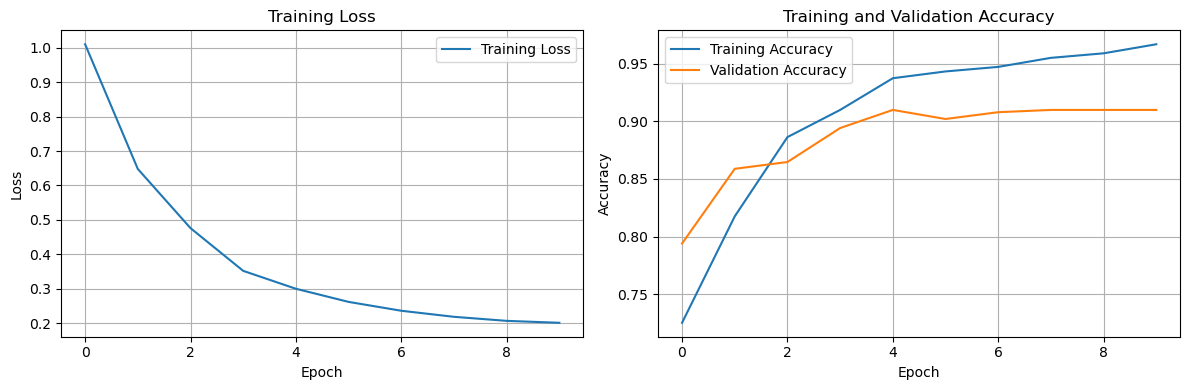


Final Results:
Best Validation Accuracy: 0.9098
Base Test Accuracy: 0.9098

Starting evaluation on novel test set...

Novel classes: 51
Novel test samples: 3676



Test Accuracy on Novel Classes: 0.7195

FINAL COMPARISON
Base Classes Test Accuracy: 0.9098
Novel Classes Test Accuracy: 0.7195
Harmonic mean: 0.8036

Training and evaluating CoCoOp with new class names
CoCoOp Model initialized
Context dimension: 512
Number of context tokens: 4
Trainable parameters: 35360

Trainable parameters:
  prompt_learner.ctx: torch.Size([4, 512])
  prompt_learner.meta_net.linear1.weight: torch.Size([32, 512])
  prompt_learner.meta_net.linear1.bias: torch.Size([32])
  prompt_learner.meta_net.linear2.weight: torch.Size([512, 32])
  prompt_learner.meta_net.linear2.bias: torch.Size([512])
Starting training

Epoch 1/10
--------------------------------------------------


Train Loss: 1.0620
Train Accuracy: 0.7451
Validation Accuracy: 0.9059
New best validation accuracy: 0.9059

Epoch 2/10
--------------------------------------------------


Train Loss: 0.2729
Train Accuracy: 0.9255
Validation Accuracy: 0.9137
New best validation accuracy: 0.9137

Epoch 3/10
--------------------------------------------------


Train Loss: 0.2204
Train Accuracy: 0.9392
Validation Accuracy: 0.9235
New best validation accuracy: 0.9235

Epoch 4/10
--------------------------------------------------


...

Train Loss: 0.1411
Train Accuracy: 0.9804
Validation Accuracy: 0.9275
New best validation accuracy: 0.9275

Epoch 8/10
--------------------------------------------------


Train Loss: 0.1339
Train Accuracy: 0.9804
Validation Accuracy: 0.9255

Epoch 9/10
--------------------------------------------------


Train Loss: 0.1284
Train Accuracy: 0.9804
Validation Accuracy: 0.9235

Epoch 10/10
--------------------------------------------------


Train Loss: 0.1268
Train Accuracy: 0.9824
Validation Accuracy: 0.9235

Training completed!
Best validation accuracy: 0.9275

Starting evaluation on base test set...



Test Accuracy on Base Classes: 0.9288


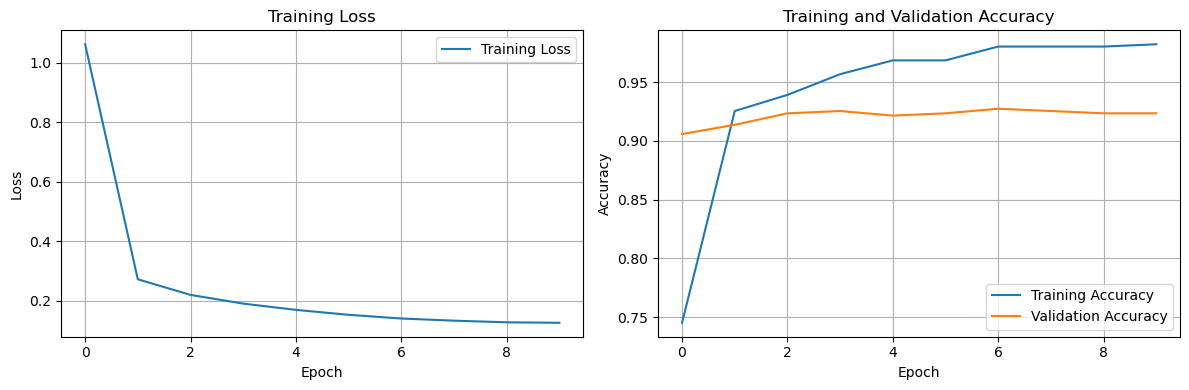


Final Results:
Best Validation Accuracy: 0.9275
Base Test Accuracy: 0.9288

Starting evaluation on novel test set...

Novel classes: 51
Novel test samples: 3676



Test Accuracy on Novel Classes: 0.8705

FINAL COMPARISON
Base Classes Test Accuracy: 0.9288
Novel Classes Test Accuracy: 0.8705
Harmonic mean: 0.8987


In [51]:
print("Training and evaluating CoCoOp with original class names")
og_cocoop_accuracy_values = train_and_eval_cocoop("og")

print()
print("Training and evaluating CoCoOp with new class names")
new_cocoop_accuracy_values = train_and_eval_cocoop("new")

In [52]:
# Display the results 
cocoop_results = pd.DataFrame({
    'Method': ['CoCoOp (Original Names)', 'CoCoOp (New Names)'],
    'Base Accuracy': [og_cocoop_accuracy_values[0]*100, new_cocoop_accuracy_values[0]*100],
    'Novel Accuracy': [og_cocoop_accuracy_values[1]*100, new_cocoop_accuracy_values[1]*100],
    'Harmonic Mean': [og_cocoop_accuracy_values[2]*100, new_cocoop_accuracy_values[2]*100]
})

print("\n📊 Detailed Results:")
print("=" * 90)

styled_results = cocoop_results.style.format({
    'Base Accuracy': '{:.2f}%',
    'Novel Accuracy': '{:.2f}%', 
    'Harmonic Mean': '{:.2f}%'
}).apply(highlight_best, subset=['Base Accuracy', 'Novel Accuracy', 'Harmonic Mean']).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
    {'selector': '', 'props': [('border-collapse', 'collapse'), ('font-family', 'Arial, sans-serif')]}
]).set_caption("CoCoOp Performance Comparison").set_table_attributes('style="margin: auto; border: 2px solid #2E86AB;"')

display(styled_results)


📊 Detailed Results:


,Method,Base Accuracy,Novel Accuracy,Harmonic Mean
0,CoCoOp (Original Names),90.98%,71.95%,80.36%
1,CoCoOp (New Names),92.88%,87.05%,89.87%


## Summary of results

Let's see

In [53]:
# Combine all results into a single dataframe
all_results = pd.DataFrame({
    'Method': [
        'CLIP Zero-Shot (Original Names)',
        'AKA CLIP', 
        'CLIP Zero-Shot (New Names)',
        'LLM CLIP',
        'CoOp (Original Names)', 
        'CoOp (New Names)',
        'CoCoOp (Original Names)', 
        'CoCoOp (New Names)',
        'KgCoOp (Original Names)', 
        'KgCoOp (New Names)'
    ],
    'Base Accuracy': [
        og_clip_accuracy_values[0]*100,
        aka_clip_accuracy_values[0]*100, 
        new_clip_accuracy_values[0]*100,
        llm_clip_accuracy_values[0]*100,
        og_coop_accuracy_values[0]*100, 
        new_coop_accuracy_values[0]*100,
        og_cocoop_accuracy_values[0]*100, 
        new_cocoop_accuracy_values[0]*100,
        og_kgcoop_accuracy_values[0]*100, 
        new_kgcoop_accuracy_values[0]*100
    ],
    'Novel Accuracy': [
        og_clip_accuracy_values[1]*100,
        aka_clip_accuracy_values[1]*100, 
        new_clip_accuracy_values[1]*100,
        llm_clip_accuracy_values[1]*100,
        og_coop_accuracy_values[1]*100, 
        new_coop_accuracy_values[1]*100,
        og_cocoop_accuracy_values[1]*100, 
        new_cocoop_accuracy_values[1]*100,
        og_kgcoop_accuracy_values[1]*100, 
        new_kgcoop_accuracy_values[1]*100
    ],
    'Harmonic Mean': [
        og_clip_accuracy_values[2]*100,
        aka_clip_accuracy_values[2]*100, 
        new_clip_accuracy_values[2]*100,
        llm_clip_accuracy_values[2]*100,
        og_coop_accuracy_values[2]*100, 
        new_coop_accuracy_values[2]*100,
        og_cocoop_accuracy_values[2]*100, 
        new_cocoop_accuracy_values[2]*100,
        og_kgcoop_accuracy_values[2]*100, 
        new_kgcoop_accuracy_values[2]*100
    ]
})

print("\n📊 Detailed Results:")
print("=" * 90)

styled_all_results = all_results.style.format({
    'Base Accuracy': '{:.2f}%',
    'Novel Accuracy': '{:.2f}%', 
    'Harmonic Mean': '{:.2f}%'
}).apply(highlight_best, subset=['Base Accuracy', 'Novel Accuracy', 'Harmonic Mean']).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
    {'selector': '', 'props': [('border-collapse', 'collapse'), ('font-family', 'Arial, sans-serif')]}
]).set_caption("Complete Zero-Shot Performance Comparison").set_table_attributes('style="margin: auto; border: 2px solid #2E86AB;"')

display(styled_all_results)


📊 Detailed Results:


,Method,Base Accuracy,Novel Accuracy,Harmonic Mean
0,CLIP Zero-Shot (Original Names),71.33%,77.77%,74.41%
1,AKA CLIP,85.69%,91.62%,88.55%
2,CLIP Zero-Shot (New Names),87.71%,93.50%,90.51%
3,LLM CLIP,74.32%,73.34%,73.83%
4,CoOp (Original Names),95.67%,66.29%,78.32%
5,CoOp (New Names),94.30%,82.59%,88.06%
6,CoCoOp (Original Names),90.98%,71.95%,80.36%
7,CoCoOp (New Names),92.88%,87.05%,89.87%
8,KgCoOp (Original Names),91.35%,75.90%,82.91%
9,KgCoOp (New Names),93.45%,92.27%,92.86%


# Conclusions and future work
With this work, we explore the the impact of the name of the classes in the context of image classification through VLMs. Results show that aligning the names of the classes with the pre-trained knowledge of the model outperforms most improvements achieved through PEFT with not completely aligned nomenclature. Moreover, when correct names are paired with said approaches, performance is still improved, leading to outstanding results.
Future work could be based on automating the generation and selection of classnames, that, given the poor results achieved through direct generation via LLMs, could be done by pairing a large language model with some image-search engine, like google lens, to be then able to correctly identify classes whose name is not aligned with internet knowledge.

## References

[1] Radford et Al. Learning transferable visual models from natural language supervision. In ICML, 2021. https://arxiv.org/abs/2103.00020

[2] Nilsback, M.-E. and Zisserman, A. Automated flower classification over a large number of classes. In Indian Conference on Computer Vision, Graphics and Image Processing, 2008. https://ieeexplore.ieee.org/document/4756141

[3] Zhou et Al. Learning to Prompt for Vision-Language Models. In ICCV, 2021. https://arxiv.org/abs/2109.01134

[4] Zhou et Al. Conditional Prompt Learning for Vision-Language Models. In NeurIPS, 2022. https://arxiv.org/abs/2203.05557

[5] Yao et Al. Visual-Language Prompt Tuning with Knowledge-guided Context Optimization In CVPR, 2023. https://arxiv.org/abs/2303.13283